# 1: Setup and Data Loading

In [1]:
# ============================================================
# TreeMap Validation Pipeline - Talladega Experimental Forest
# Section 1: Setup and Data Loading
# ============================================================

# Install required packages
!pip install rasterio -q

# Import libraries
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon, MultiPoint, shape
import math
import matplotlib.pyplot as plt
import rasterio
from rasterio.mask import mask
from rasterio.features import shapes
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Unzip GeoDatabase
!unzip /content/drive/MyDrive/TalladegaLidarData_Projected_Complete.gdb.zip -d /content/TalladegaLidarData_Projected_Complete/

print("✅ Setup complete")

Mounted at /content/drive
Archive:  /content/drive/MyDrive/TalladegaLidarData_Projected_Complete.gdb.zip
  inflating: /content/TalladegaLidarData_Projected_Complete/TalladegaLidarData_Projected_Complete.gdb/a00000001.freelist  
  inflating: /content/TalladegaLidarData_Projected_Complete/TalladegaLidarData_Projected_Complete.gdb/a00000001.gdbindexes  
  inflating: /content/TalladegaLidarData_Projected_Complete/TalladegaLidarData_Projected_Complete.gdb/a00000001.gdbtable  
  inflating: /content/TalladegaLidarData_Projected_Complete/TalladegaLidarData_Projected_Complete.gdb/a00000001.gdbtablx  
  inflating: /content/TalladegaLidarData_Projected_Complete/TalladegaLidarData_Projected_Complete.gdb/a00000001.TablesByName.atx  
  inflating: /content/TalladegaLidarData_Projected_Complete/TalladegaLidarData_Projected_Complete.gdb/a00000002.gdbtable  
  inflating: /content/TalladegaLidarData_Projected_Complete/TalladegaLidarData_Projected_Complete.gdb/a00000002.gdbtablx  
  inflating: /content/Ta

# 2: Generate CIRCULAR Plot

In [2]:
# ============================================================
# Section 2: Generate CIRCULAR Plot Boundaries (r=11.35m)
# ============================================================
gdb_path = "/content/TalladegaLidarData_Projected_Complete/TalladegaLidarData_Projected_Complete.gdb"
csv_path = "/content/drive/MyDrive/TreeDataExport_editTY.csv"
output_path = "/output_polygons.shp"
layer_name = "Talladega_LiDAR_Field_Collection_GPSpts"

# Read plot centers
points_gdf = gpd.read_file(gdb_path, layer=layer_name)
points_gdf.rename(columns=lambda x: x.strip(), inplace=True)

# Convert to NAD83/Conus Albers (EPSG:5070) — metric units, matches TreeMap
target_crs = "EPSG:5070"
points_gdf = points_gdf.to_crs(target_crs)
print(f"CRS: {points_gdf.crs}")

# FIA 1/10-acre subplot: radius = 37.2 ft = 11.3386 m ≈ 11.35 m
# Area = π × 11.35² = 404.7 m²
RADIUS_M = 11.35

result_data = []
for idx, row in points_gdf.iterrows():
    circle = row.geometry.buffer(RADIUS_M)
    result_data.append({
        "globalid": row["globalid"],
        "geometry": circle,
        "MeanDist_m": RADIUS_M   # constant for circular design
    })

result_gdf = gpd.GeoDataFrame(result_data, crs=target_crs)

# Quality check
areas = result_gdf.geometry.area
print(f"\n📊 Circular Plot Area Verification:")
print(f"   Expected: {np.pi * RADIUS_M**2:.2f} m²")
print(f"   Mean:     {areas.mean():.2f} m²")
print(f"   Std:      {areas.std():.4f} m²  (should be ~0)")
print(f"   All within 1% of expected: {(abs(areas - 404.7) / 404.7 < 0.01).all()}")
print(f"   Total plots: {len(result_gdf)} (0 excluded)")

result_gdf.to_file(output_path)
print(f"✅ Circular plots saved: {output_path}")

CRS: EPSG:5070

📊 Circular Plot Area Verification:
   Expected: 404.71 m²
   Mean:     404.06 m²
   Std:      0.0000 m²  (should be ~0)
   All within 1% of expected: True
   Total plots: 255 (0 excluded)
✅ Circular plots saved: /output_polygons.shp


# 3: TreeMap Processing and Spatial Overlay

In [3]:
# ============================================================
# Section 3: TreeMap Processing and Spatial Overlay
# ============================================================

year = 2016  # Change to 2022 for 2022 analysis

# 3.1 Load circular plots
plots = gpd.read_file("/output_polygons.shp")
plots_5070 = plots.to_crs("EPSG:5070")
print(f"Plots CRS: {plots_5070.crs}")

# Create boundary for clipping TreeMap
boundary = gpd.GeoDataFrame(
    {"geometry": [plots_5070.buffer(500).union_all()]},
    crs="EPSG:5070"
)
boundary_path = f"/content/Talladega_boundary_5070.shp"
boundary.to_file(boundary_path)

# 3.2 Clip TreeMap raster
treemap_path = f"/content/drive/MyDrive/TreeMap{year}.tif"
treemap_clip_path = f"/content/drive/MyDrive/TreeMap{year}_Talladega_clip.tif"

with rasterio.open(treemap_path) as src:
    boundary_proj = boundary.to_crs(src.crs)
    geoms = [boundary_proj.geometry.iloc[0]]
    out_img, out_transform = mask(src, geoms, crop=True)
    out_meta = src.meta.copy()

out_meta.update({
    "height": out_img.shape[1],
    "width": out_img.shape[2],
    "transform": out_transform
})

with rasterio.open(treemap_clip_path, "w", **out_meta) as dest:
    dest.write(out_img)

print(f"✅ Clipped TreeMap{year} saved")

# 3.3 Polygonize TreeMap raster
with rasterio.open(treemap_clip_path) as src:
    img = src.read(1)
    transform = src.transform
    treemap_crs = src.crs
    nodata = src.nodata

img_fixed = img.astype("int64")
img_fixed[img == nodata] = -1
img_fixed = img_fixed.astype("int32")

polygons = (
    {"properties": {"DN": int(v)}, "geometry": shape(s)}
    for s, v in shapes(img_fixed, transform=transform)
    if v != -1
)

treemap_polygons = gpd.GeoDataFrame.from_features(polygons, crs=treemap_crs)
treemap_polygons = treemap_polygons[treemap_polygons["DN"] > 0]
treemap_polygons = treemap_polygons.to_crs(target_crs)
treemap_polygons["area"] = treemap_polygons.geometry.area
treemap_polygons = treemap_polygons[treemap_polygons["area"] > 1].drop(columns="area")
treemap_polygons.to_file(f"/content/drive/MyDrive/TreeMap_{year}_polygons.shp")
print(f"✅ TreeMap polygons saved: {len(treemap_polygons)} polygons")

# 3.6 Spatial overlay
if plots_5070.crs != treemap_polygons.crs:
    raise ValueError("CRS mismatch!")

intersection_gdf = gpd.overlay(
    plots_5070, treemap_polygons,
    how="intersection", keep_geom_type=True
)
intersection_gdf["Area"] = intersection_gdf.geometry.area
print(f"Intersection polygon count: {len(intersection_gdf)}")

# 3.7 Compute area ratios
# For circular plots, use the nominal area (π*r²) as denominator
# to ensure perfect consistency across all plots
CIRCLE_AREA = np.pi * RADIUS_M**2  # 404.70 m²

total_area = (
    intersection_gdf.groupby("globalid")["Area"]
    .sum()
    .reset_index()
    .rename(columns={"Area": "convex_area"})
)

intersection_gdf = intersection_gdf.merge(total_area, on="globalid")
intersection_gdf["area_ratio"] = intersection_gdf["Area"] / intersection_gdf["convex_area"]
intersection_gdf["area_m2"] = intersection_gdf["Area"]

# 3.8 Save results
output_shp = f"/content/drive/MyDrive/intersection_{year}_FIXED.shp"
output_csv = f"/content/drive/MyDrive/final_area_summary_{year}_FIXED.csv"
intersection_gdf.to_file(output_shp)
intersection_gdf.to_csv(output_csv, index=False)
print(f"✅ Saved intersection data")

# Section 3.9: Plot Area Verification (Circular Design)
print("\n" + "="*60)
print("📏 CIRCULAR PLOT AREA VERIFICATION")
print("="*60)

plot_areas = intersection_gdf.groupby('globalid')['convex_area'].first()
expected_area = np.pi * RADIUS_M**2  # 404.70 m²

print(f"\n   Expected area (r={RADIUS_M}m): {expected_area:.2f} m²")
print(f"   Mean actual area:             {plot_areas.mean():.2f} m²")
print(f"   Std:                          {plot_areas.std():.4f} m²")
print(f"   All within 0.1%:              {(abs(plot_areas - expected_area) / expected_area < 0.001).all()}")
print(f"   Plots with TreeMap overlap:   {len(plot_areas)}")
print(f"   Plots without overlap:        {255 - len(plot_areas)} (edge/clearcut)")
print(f"\n✅ No area-based exclusions needed for circular design")


# Section 3.10: Trivial Fragment Cleaning
TRIVIAL_THRESHOLD = 0.05
STRATEGY = "HYBRID"
DOMINANCE_THRESHOLD = 0.60

print(f"\nTrivial fragment threshold: {TRIVIAL_THRESHOLD} (5%)")

intersection_gdf['is_trivial'] = intersection_gdf['area_ratio'] <= TRIVIAL_THRESHOLD
trivial_count = intersection_gdf['is_trivial'].sum()
print(f"Trivial fragments: {trivial_count} ({trivial_count/len(intersection_gdf)*100:.1f}%)")

intersection_cleaned = intersection_gdf.copy()
cleaning_stats = {
    'plots_processed': 0, 'fragments_removed': 0,
    'proportional_count': 0, 'dominant_count': 0
}

for plot_id in intersection_cleaned['globalid'].unique():
    plot_data = intersection_cleaned[intersection_cleaned['globalid'] == plot_id].copy()
    trivial_mask = plot_data['area_ratio'] <= TRIVIAL_THRESHOLD
    trivial_frags = plot_data[trivial_mask]
    non_trivial_frags = plot_data[~trivial_mask]

    if len(trivial_frags) == 0:
        continue

    cleaning_stats['plots_processed'] += 1
    cleaning_stats['fragments_removed'] += len(trivial_frags)

    if len(non_trivial_frags) == 0:
        continue

    dominant_idx = non_trivial_frags['area_ratio'].idxmax()
    dominant_ratio = non_trivial_frags.loc[dominant_idx, 'area_ratio']
    trivial_total = trivial_frags['area_ratio'].sum()

    use_proportional = dominant_ratio < DOMINANCE_THRESHOLD

    if use_proportional:
        cleaning_stats['proportional_count'] += 1
        non_trivial_sum = non_trivial_frags['area_ratio'].sum()
        for idx in non_trivial_frags.index:
            new_ratio = intersection_cleaned.loc[idx, 'area_ratio'] / non_trivial_sum
            intersection_cleaned.loc[idx, 'area_ratio'] = new_ratio
            intersection_cleaned.loc[idx, 'Area'] = new_ratio * intersection_cleaned.loc[idx, 'convex_area']
    else:
        cleaning_stats['dominant_count'] += 1
        intersection_cleaned.loc[dominant_idx, 'area_ratio'] += trivial_total
        intersection_cleaned.loc[dominant_idx, 'Area'] = (
            intersection_cleaned.loc[dominant_idx, 'area_ratio'] *
            intersection_cleaned.loc[dominant_idx, 'convex_area']
        )

    intersection_cleaned = intersection_cleaned[
        ~((intersection_cleaned['globalid'] == plot_id) & trivial_mask)
    ]

# Quality check
area_check = intersection_cleaned.groupby('globalid')['area_ratio'].sum()
print(f"\n📊 Area ratio conservation after cleaning:")
print(f"   Mean: {area_check.mean():.8f}  (should be 1.0)")
print(f"   Std:  {area_check.std():.8f}   (should be ~0)")
print(f"   ✅ Conservation maintained: {abs(area_check.mean() - 1.0) < 1e-6}")

cleaned_csv = f"/content/drive/MyDrive/final_area_summary_{year}_CLEANED.csv"
intersection_cleaned.to_csv(cleaned_csv, index=False)
print(f"✅ Cleaned data saved: {cleaned_csv}")

Plots CRS: EPSG:5070


✅ Clipped TreeMap2016 saved
✅ TreeMap polygons saved: 81665 polygons
Intersection polygon count: 508


/tmp/ipython-input-747/1426712978.py:96: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  intersection_gdf.to_file(output_shp)
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'convex_area' to 'convex_are'
  ogr_write(


✅ Saved intersection data

📏 CIRCULAR PLOT AREA VERIFICATION

   Expected area (r=11.35m): 404.71 m²
   Mean actual area:             369.03 m²
   Std:                          97.0185 m²
   All within 0.1%:              False
   Plots with TreeMap overlap:   243
   Plots without overlap:        12 (edge/clearcut)

✅ No area-based exclusions needed for circular design

Trivial fragment threshold: 0.05 (5%)
Trivial fragments: 86 (16.9%)

📊 Area ratio conservation after cleaning:
   Mean: 1.00000000  (should be 1.0)
   Std:  0.00000000   (should be ~0)
   ✅ Conservation maintained: True
✅ Cleaned data saved: /content/drive/MyDrive/final_area_summary_2016_CLEANED.csv



1️⃣ Calculating DN total area percentages...
   (Using AREA in m², NOT area_ratio)

   📊 Total aggregate area: 89,674 m²

   ✅ Calculated percentages for 160 unique DNs

   📊 Top 15 DNs by total area coverage:
   DN  Percentage  Total_Area_m2  Num_Plots
  524   11.925022   10693.694733         42
18116    9.469334    8491.570862         59
 1833    5.073919    4550.007433         16
17243    4.314820    3869.289914         21
49572    3.604473    3232.290650         14
  657    2.346908    2104.576393         12
  660    2.278686    2043.398504          7
16697    2.080393    1865.580805          9
49548    2.013967    1806.013197          8
17874    1.958137    1755.948419         14
  527    1.879319    1685.268222          8
35712    1.819722    1631.825579          7
35719    1.557278    1396.480473          4
  371    1.519627    1362.716516          5
17326    1.428260    1280.783646          7

2️⃣ Defining over-representation threshold...

   Threshold: 10.0%
   DNs with > 10.

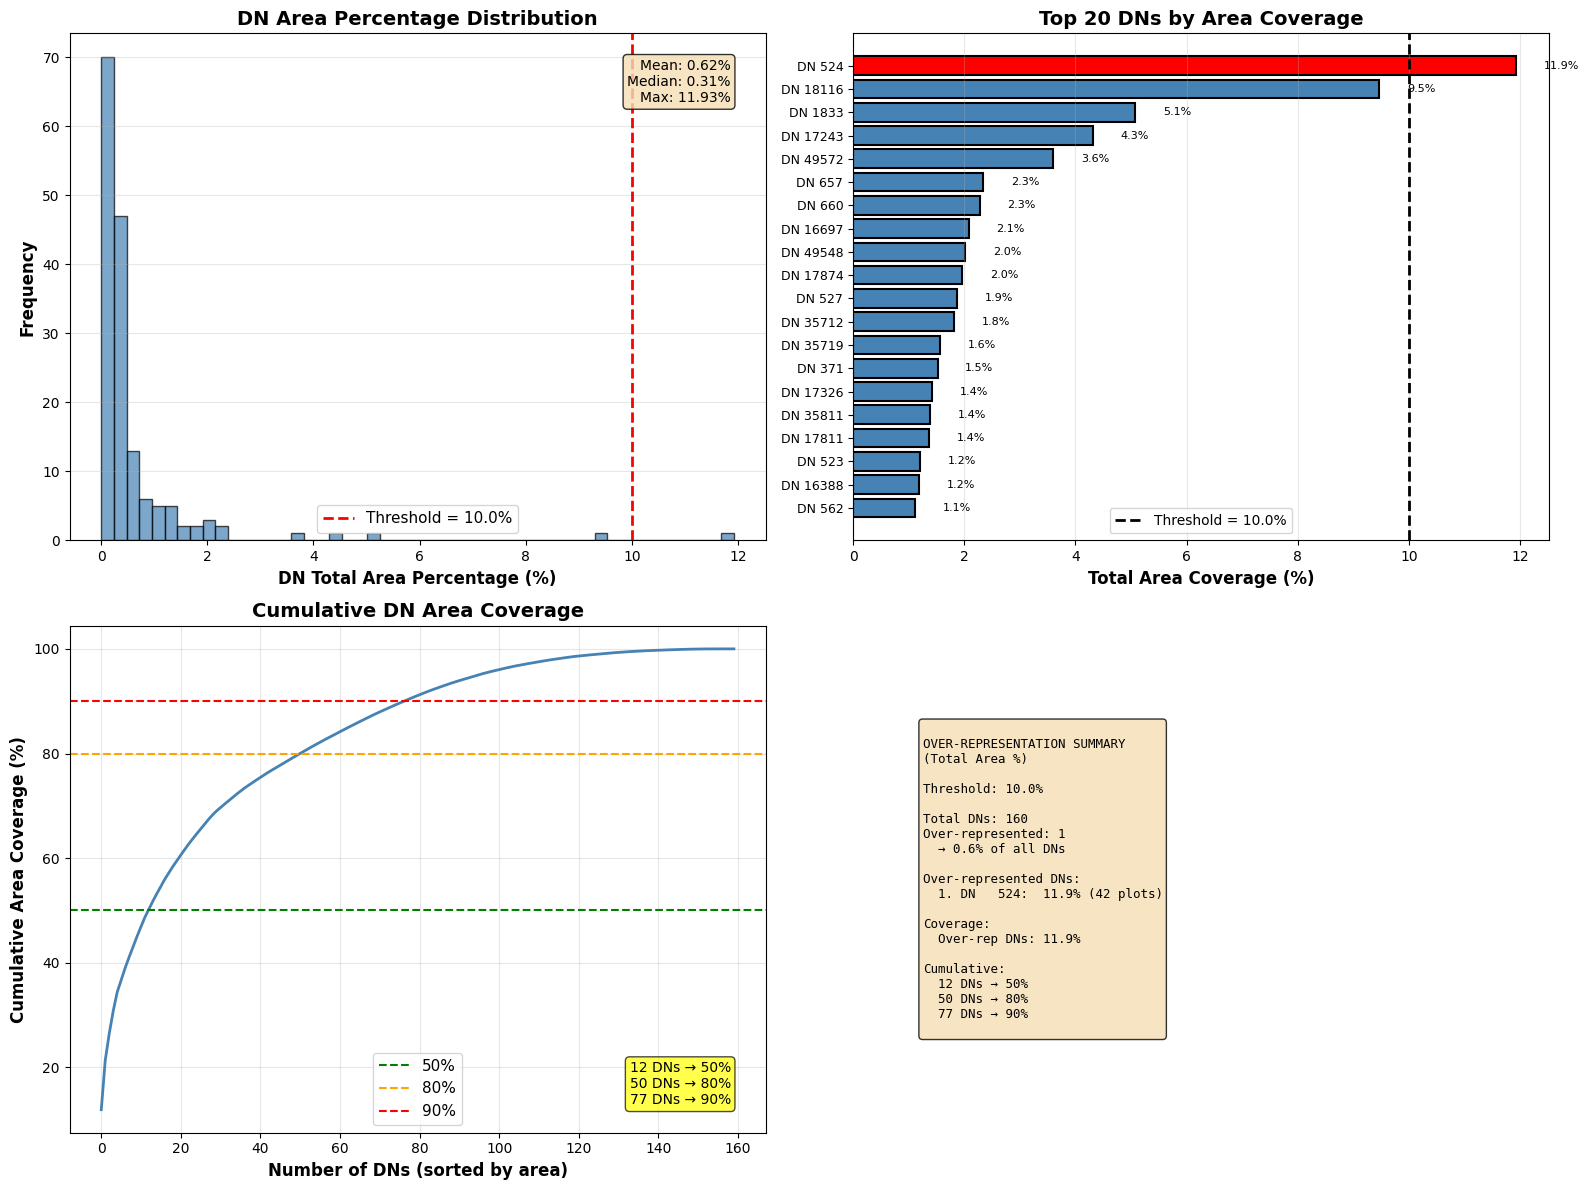

   ✅ Visualization: /content/drive/MyDrive/FigQC_Overrepresentation_NEW_2016.png

6️⃣ Saving results...
   ✅ All DN statistics: /content/drive/MyDrive/dn_total_areas_2016.csv
   ✅ Over-represented DNs: /content/drive/MyDrive/overrepresented_dns_2016.csv

✅ OVER-REPRESENTATION ANALYSIS COMPLETE

📋 NEXT STEPS:
   For the 1 over-represented DNs, perform:

   1. Species composition analysis
   2. Basal area (BA) distribution
   3. Volume distribution
   4. Height/Diameter distributions
   5. Compare to FIA reference distributions

   These analyses should focus ONLY on over-represented DNs.


   💾 Over-represented DN data: /content/drive/MyDrive/intersection_2016_OVERREP_ONLY.csv
      Contains 45 fragments from 1 DNs


In [4]:
# ============================================================
# Section 3.11: OVER-REPRESENTATION ANALYSIS
# ============================================================


# ============================
# Step 1: Calculate DN total area percentages
# ============================
print("\n1️⃣ Calculating DN total area percentages...")
print("   (Using AREA in m², NOT area_ratio)")

# Calculate total area for each DN
dn_total_areas = intersection_gdf.groupby('DN').agg(
    Total_Area_m2=('Area', 'sum'),
    Num_Plots=('globalid', 'nunique'),
    Num_Fragments=('Area', 'count')
).reset_index()

# Calculate total aggregate area
total_aggregate_area = intersection_gdf['Area'].sum()

print(f"\n   📊 Total aggregate area: {total_aggregate_area:,.0f} m²")

# Calculate percentage
dn_total_areas['Percentage'] = (dn_total_areas['Total_Area_m2'] / total_aggregate_area) * 100

# Sort by percentage
dn_total_areas = dn_total_areas.sort_values('Percentage', ascending=False)

print(f"\n   ✅ Calculated percentages for {len(dn_total_areas)} unique DNs")

print(f"\n   📊 Top 15 DNs by total area coverage:")
print(dn_total_areas.head(15)[['DN', 'Percentage', 'Total_Area_m2', 'Num_Plots']].to_string(index=False))

# ============================
# Step 2: Define over-representation threshold
# ============================
print("\n2️⃣ Defining over-representation threshold...")

OVERREP_THRESHOLD = 10.0

print(f"\n   Threshold: {OVERREP_THRESHOLD}%")
print(f"   DNs with > {OVERREP_THRESHOLD}% of total aggregate area → over-represented")

# Identify over-represented DNs
overrep_dns = dn_total_areas[dn_total_areas['Percentage'] > OVERREP_THRESHOLD].copy()

print(f"\n   🎯 Found {len(overrep_dns)} over-represented DNs")

if len(overrep_dns) > 0:
    print(f"\n   📋 Over-represented DNs:")
    print(overrep_dns[['DN', 'Percentage', 'Total_Area_m2', 'Num_Plots', 'Num_Fragments']].to_string(index=False))

    overrep_total_pct = overrep_dns['Percentage'].sum()
    print(f"\n   📈 These {len(overrep_dns)} DNs cover {overrep_total_pct:.1f}% of total area")
else:
    print(f"\n   ✅ No DNs exceed {OVERREP_THRESHOLD}% threshold")

# ============================
# Step 3: Compare with old method
# ============================
print("\n3️⃣ Comparing with old method...")

# Old method: DNs appearing in 2+ plots
old_method = dn_total_areas[dn_total_areas['Num_Plots'] >= 2]

print(f"\n   📊 Method comparison:")
print(f"      Old method (≥2 plots): {len(old_method)} DNs")
print(f"      New method (>10% area): {len(overrep_dns)} DNs")

if len(overrep_dns) > 0:
    # DNs identified by both
    both_methods = set(overrep_dns['DN']) & set(old_method['DN'])
    new_only = set(overrep_dns['DN']) - set(old_method['DN'])
    old_only = set(old_method['DN']) - set(overrep_dns['DN'])

    print(f"\n      Both methods: {len(both_methods)} DNs")
    print(f"      New only: {len(new_only)} DNs (large area, few plots)")
    print(f"      Old only: {len(old_only)} DNs (small area, many plots)")

    if len(new_only) > 0:
        print(f"\n      DNs in new method only:")
        for dn in list(new_only)[:5]:
            info = dn_total_areas[dn_total_areas['DN'] == dn].iloc[0]
            print(f"         DN {int(dn):5d}: {info['Percentage']:5.1f}% area, {int(info['Num_Plots'])} plots")

# ============================
# Step 4: Cumulative coverage analysis
# ============================
print("\n4️⃣ Cumulative coverage analysis...")

cumulative_pct = dn_total_areas['Percentage'].cumsum()

# Find how many DNs needed for different coverage levels
dns_for_50 = (cumulative_pct <= 50).sum()
dns_for_80 = (cumulative_pct <= 80).sum()
dns_for_90 = (cumulative_pct <= 90).sum()

print(f"\n   📊 Area coverage:")
print(f"      {dns_for_50} DNs cover 50% of area")
print(f"      {dns_for_80} DNs cover 80% of area")
print(f"      {dns_for_90} DNs cover 90% of area")

# ============================
# Step 5: Visualization
# ============================
print("\n5️⃣ Creating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: DN percentage distribution
ax = axes[0, 0]
ax.hist(dn_total_areas['Percentage'], bins=50, edgecolor='black',
       color='steelblue', alpha=0.7)
ax.axvline(OVERREP_THRESHOLD, color='red', linestyle='--', linewidth=2,
          label=f'Threshold = {OVERREP_THRESHOLD}%')
ax.set_xlabel('DN Total Area Percentage (%)', fontweight='bold', fontsize=12)
ax.set_ylabel('Frequency', fontweight='bold', fontsize=12)
ax.set_title('DN Area Percentage Distribution', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')

# Add stats
ax.text(0.95, 0.95,
       f'Mean: {dn_total_areas["Percentage"].mean():.2f}%\n'
       f'Median: {dn_total_areas["Percentage"].median():.2f}%\n'
       f'Max: {dn_total_areas["Percentage"].max():.2f}%',
       transform=ax.transAxes,
       verticalalignment='top',
       horizontalalignment='right',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
       fontsize=10)

# Plot 2: Top 20 DNs
ax = axes[0, 1]
top_dns = dn_total_areas.head(20)

colors = ['red' if pct > OVERREP_THRESHOLD else 'steelblue'
         for pct in top_dns['Percentage']]

bars = ax.barh(range(len(top_dns)), top_dns['Percentage'],
              color=colors, edgecolor='black', linewidth=1.5)

ax.set_yticks(range(len(top_dns)))
ax.set_yticklabels([f"DN {int(dn)}" for dn in top_dns['DN']], fontsize=9)
ax.set_xlabel('Total Area Coverage (%)', fontweight='bold', fontsize=12)
ax.set_title('Top 20 DNs by Area Coverage', fontweight='bold', fontsize=14)
ax.axvline(OVERREP_THRESHOLD, color='black', linestyle='--', linewidth=2,
          label=f'Threshold = {OVERREP_THRESHOLD}%')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='x')
ax.invert_yaxis()

# Add labels
for i, pct in enumerate(top_dns['Percentage']):
    ax.text(pct + 0.5, i, f'{pct:.1f}%', va='center', fontsize=8)

# Plot 3: Cumulative coverage
ax = axes[1, 0]

ax.plot(range(len(cumulative_pct)), cumulative_pct,
       linewidth=2, color='steelblue')
ax.axhline(50, color='green', linestyle='--', linewidth=1.5, label='50%')
ax.axhline(80, color='orange', linestyle='--', linewidth=1.5, label='80%')
ax.axhline(90, color='red', linestyle='--', linewidth=1.5, label='90%')

ax.set_xlabel('Number of DNs (sorted by area)', fontweight='bold', fontsize=12)
ax.set_ylabel('Cumulative Area Coverage (%)', fontweight='bold', fontsize=12)
ax.set_title('Cumulative DN Area Coverage', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# Add annotation
ax.text(0.95, 0.05,
       f'{dns_for_50} DNs → 50%\n'
       f'{dns_for_80} DNs → 80%\n'
       f'{dns_for_90} DNs → 90%',
       transform=ax.transAxes,
       verticalalignment='bottom',
       horizontalalignment='right',
       bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
       fontsize=10)

# Plot 4: Summary
ax = axes[1, 1]
ax.axis('off')

summary_text = f"""
OVER-REPRESENTATION SUMMARY
(Total Area %)

Threshold: {OVERREP_THRESHOLD}%

Total DNs: {len(dn_total_areas)}
Over-represented: {len(overrep_dns)}
  → {len(overrep_dns)/len(dn_total_areas)*100:.1f}% of all DNs

"""

if len(overrep_dns) > 0:
    summary_text += "Over-represented DNs:\n"
    for i, (_, row) in enumerate(overrep_dns.head(8).iterrows(), 1):
        summary_text += f"  {i}. DN {int(row['DN']):5d}: {row['Percentage']:5.1f}%"
        summary_text += f" ({int(row['Num_Plots'])} plots)\n"

    summary_text += f"\nCoverage:\n"
    summary_text += f"  Over-rep DNs: {overrep_total_pct:.1f}%\n"
else:
    summary_text += "✅ No over-represented DNs\n"

summary_text += f"\nCumulative:\n"
summary_text += f"  {dns_for_50} DNs → 50%\n"
summary_text += f"  {dns_for_80} DNs → 80%\n"
summary_text += f"  {dns_for_90} DNs → 90%\n"

ax.text(0.1, 0.5, summary_text,
       transform=ax.transAxes,
       verticalalignment='center',
       fontsize=9,
       fontfamily='monospace',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
viz_path = f"/content/drive/MyDrive/FigQC_Overrepresentation_NEW_{year}.png"
plt.savefig(viz_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"   ✅ Visualization: {viz_path}")

# ============================
# Step 6: Save results
# ============================
print("\n6️⃣ Saving results...")

# Save all DN statistics
dn_areas_path = f"/content/drive/MyDrive/dn_total_areas_{year}.csv"
dn_total_areas.to_csv(dn_areas_path, index=False)
print(f"   ✅ All DN statistics: {dn_areas_path}")

# Save over-represented DNs
if len(overrep_dns) > 0:
    overrep_path = f"/content/drive/MyDrive/overrepresented_dns_{year}.csv"
    overrep_dns.to_csv(overrep_path, index=False)
    print(f"   ✅ Over-represented DNs: {overrep_path}")

print("\n" + "="*80)
print("✅ OVER-REPRESENTATION ANALYSIS COMPLETE")
print("="*80)

if len(overrep_dns) > 0:
    print(f"""
📋 NEXT STEPS:
   For the {len(overrep_dns)} over-represented DNs, perform:

   1. Species composition analysis
   2. Basal area (BA) distribution
   3. Volume distribution
   4. Height/Diameter distributions
   5. Compare to FIA reference distributions

   These analyses should focus ONLY on over-represented DNs.
""")

    # Filter data for over-represented DNs
    overrep_dn_list = overrep_dns['DN'].tolist()
    intersection_overrep = intersection_gdf[intersection_gdf['DN'].isin(overrep_dn_list)].copy()

    overrep_data_path = f"/content/drive/MyDrive/intersection_{year}_OVERREP_ONLY.csv"
    intersection_overrep.to_csv(overrep_data_path, index=False)
    print(f"\n   💾 Over-represented DN data: {overrep_data_path}")
    print(f"      Contains {len(intersection_overrep):,} fragments from {len(overrep_dns)} DNs")
else:
    print("""
✅ No over-represented DNs found
   → All DNs have < 10% of total aggregate area
   → Proceed with normal validation workflow for all DNs
""")

# 4: Post-Merge Quality Control

In [5]:
# ============================================================
# Section 4: Post-Merge Quality Control
# ============================================================
print("\n" + "="*60)
print("📁 LOADING MERGED DATA")
print("="*60)

df = pd.read_csv(f"/content/drive/MyDrive/final_area_summary_{year}_MERGED.csv")
print(f"Records: {len(df):,}  |  Plots: {df['globalid'].nunique()}  |  DNs: {df['DN'].nunique()}")

# Area ratio verification
area_check = df.groupby('globalid')['area_ratio'].sum()
print(f"Area ratio sum — Mean: {area_check.mean():.6f}  Std: {area_check.std():.6f}")

# DN distribution
dn_per_plot = df.groupby("globalid")["DN"].nunique()
print(f"\nDN count distribution:")
print(dn_per_plot.value_counts().sort_index())

# All plots retained (no area-based filtering for circular design)
df_filtered = df.copy()
# Re-normalize area_ratio (in case of any floating point drift)
df_filtered["area_ratio"] = df_filtered.groupby("globalid")["area_ratio"].transform(
    lambda x: x / x.sum()
)

output_final = f"/content/drive/MyDrive/final_area_summary_{year}_FINAL.csv"
df_filtered.to_csv(output_final, index=False)

final_dn = df_filtered.groupby("globalid")["DN"].nunique()
print(f"\n✅ Final dataset: {final_dn.count()} plots, {len(df_filtered)} fragments")
print(f"   Mean DNs/plot: {final_dn.mean():.2f}")


📁 LOADING MERGED DATA
Records: 310  |  Plots: 237  |  DNs: 134
Area ratio sum — Mean: 1.000000  Std: 0.000000

DN count distribution:
DN
1    174
2     53
3     10
Name: count, dtype: int64

✅ Final dataset: 237 plots, 310 fragments
   Mean DNs/plot: 1.31


# 5: Attribute Comparison - Diameter and Height

DIAMETER AND HEIGHT COMPARISON

1️⃣ Preparing TreeMap data...
   Using TreeMap ID column: tm_id


/tmp/ipython-input-747/3311160287.py:58: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  treemap_treetable["DIA"].fillna(treemap_treetable["DIA"].mean(), inplace=True)
/tmp/ipython-input-747/3311160287.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[c

   ✅ TreeMap: 55215 polygons with mean DIA/HT

2️⃣ Computing area-weighted TreeMap attributes...
   ✅ Computed weighted attributes for 237 plots

3️⃣ Preparing field data...
   ✅ Field: 253 plots with mean DIA/HT

4️⃣ Comparing TreeMap vs Field...
   ✅ Matched 234 plots for comparison

VALIDATION METRICS

📏 Diameter Metrics:
   RMSE  = 3.431 inches
   MAE   = 2.636 inches
   R²    = -0.687
   Bias  = -1.671 inches
   %RMSE = 32.7%

📏 Height Metrics:
   RMSE  = 13.997 feet
   MAE   = 11.266 feet
   R²    = -0.183
   Bias  = -2.781 feet
   %RMSE = 23.5%

5️⃣ Creating visualizations...


/tmp/ipython-input-747/3311160287.py:119: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  talladega_treetable["Tree diameter (inches)"].fillna(
/tmp/ipython-input-747/3311160287.py:122: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

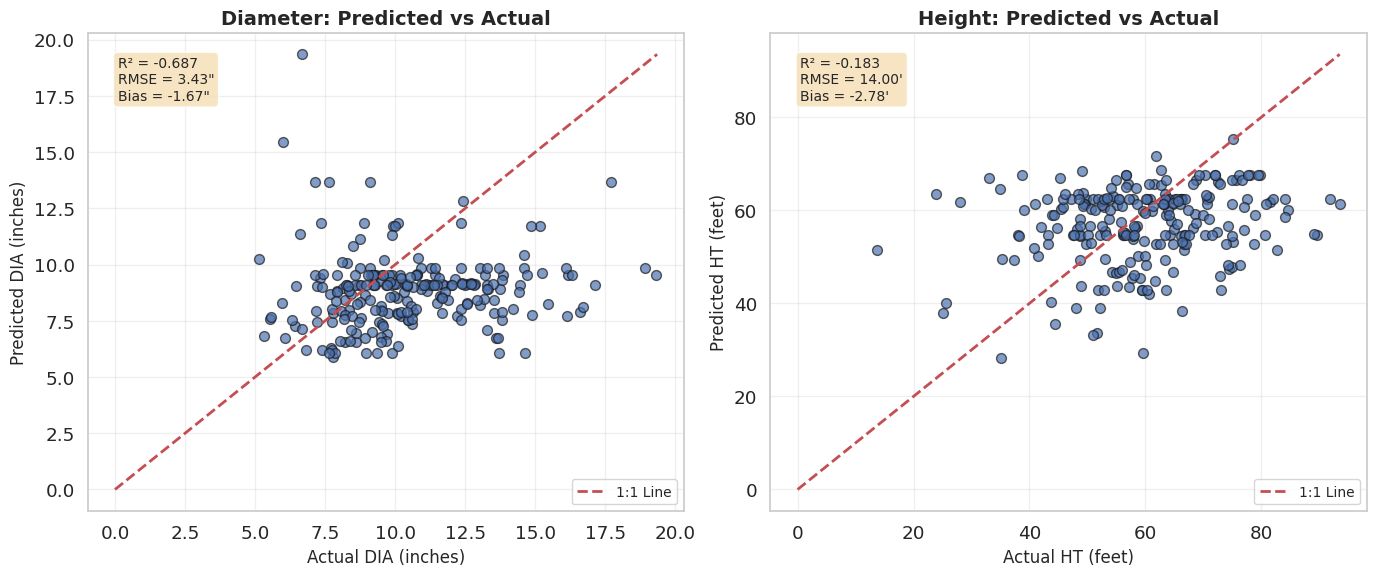

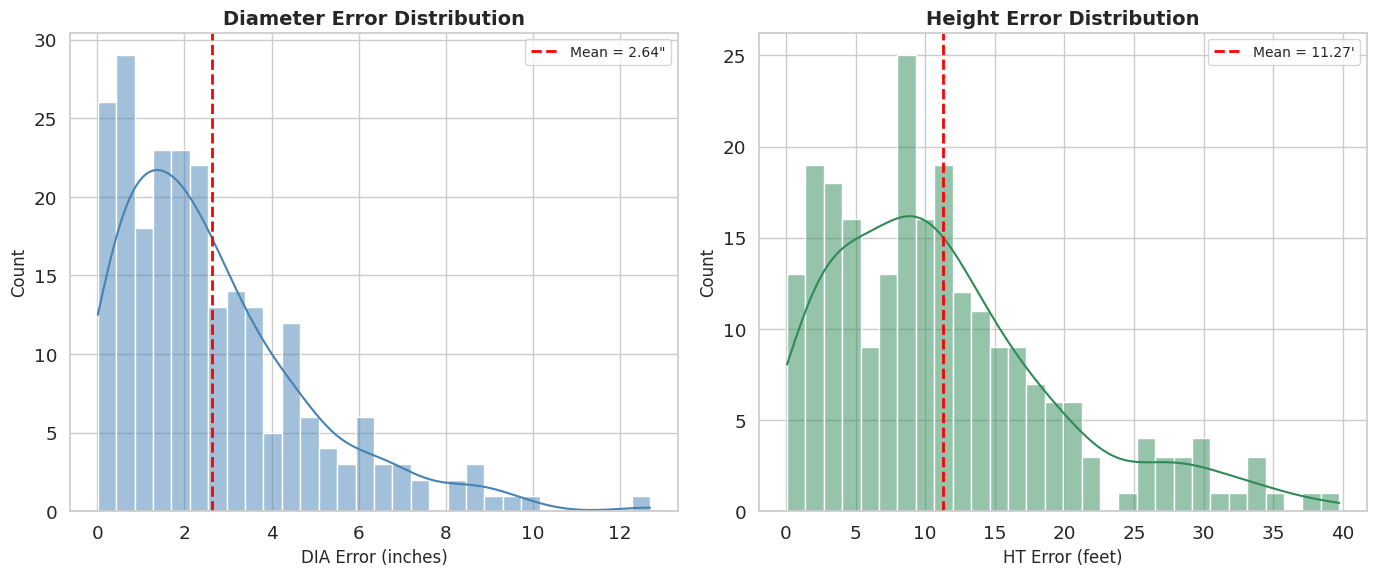

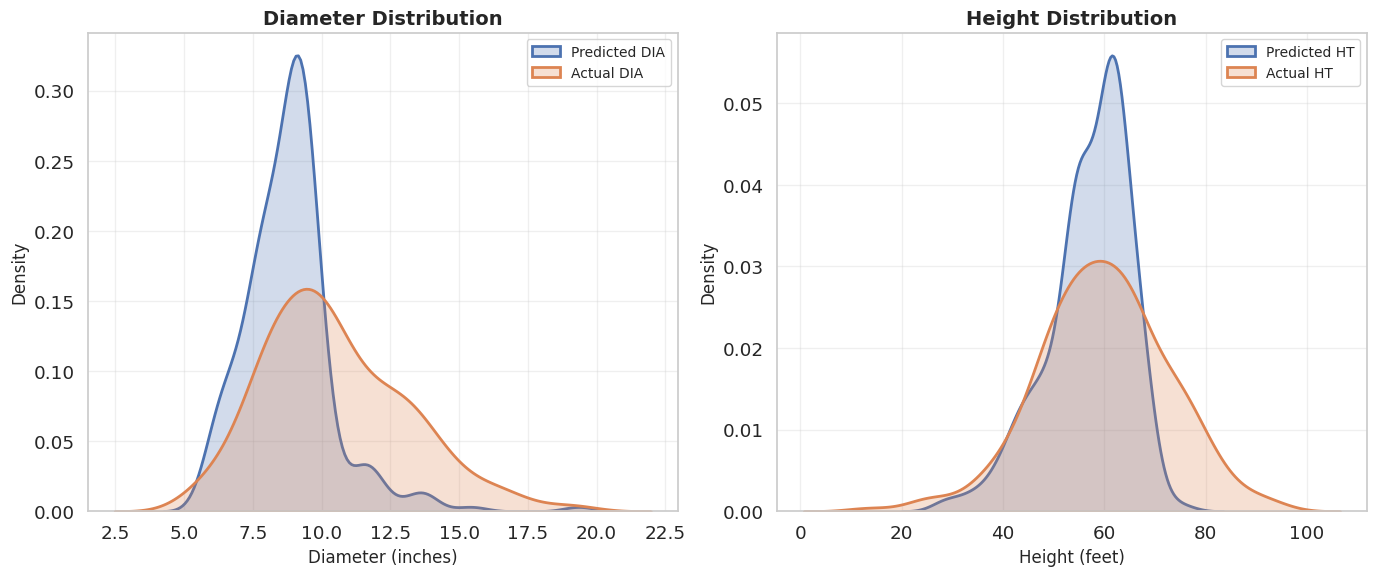

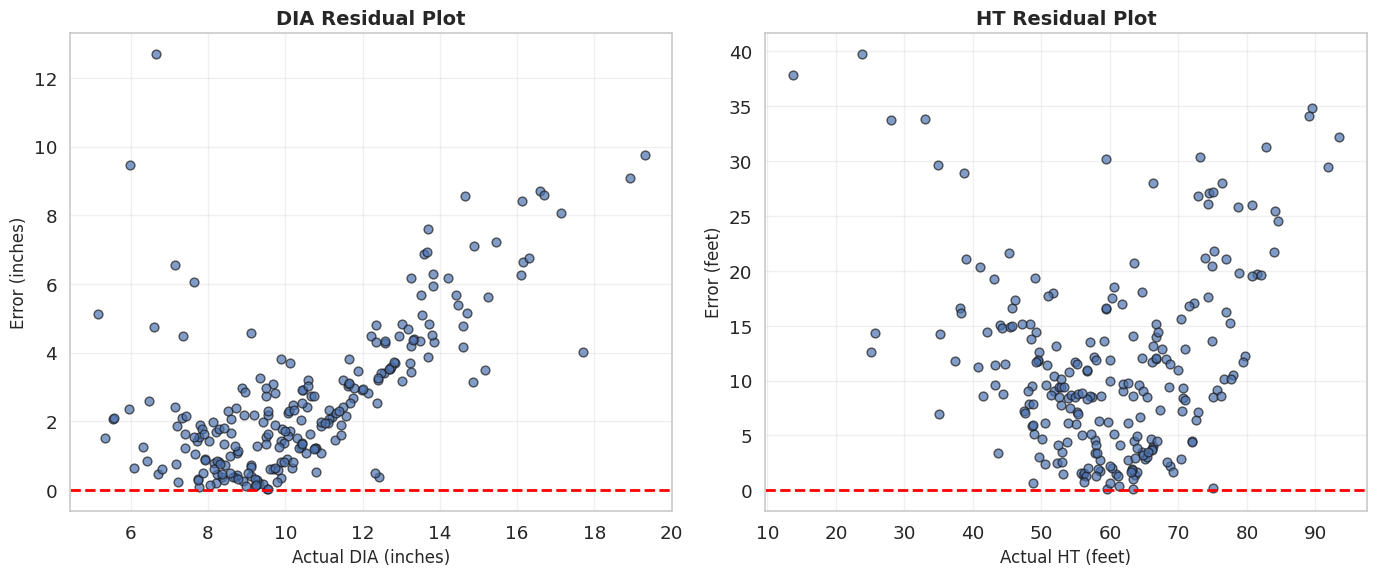


✅ All figures saved with 'Fig' prefix for easy identification
✅ Comparison results saved: /content/drive/MyDrive/diameter_height_comparison_2016.csv

✅ DIAMETER AND HEIGHT COMPARISON COMPLETE


In [6]:
# ============================================================
# Section 5: Diameter and Height Comparison - FINAL VERSION
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt

# Set visualization style
sns.set(style="whitegrid", font_scale=1.2)

# Base directory
base_dir = "/content/drive/MyDrive"

# File paths
treemap_treetable_path = f"{base_dir}/TreeMap{year}_tree_table.csv"
talladega_treetable_path = f"{base_dir}/TreeDataExport_editTY.csv"
final_export_path = f"{base_dir}/final_area_summary_{year}_FINAL.csv"

# Load data
treemap_treetable = pd.read_csv(treemap_treetable_path)
talladega_treetable = pd.read_csv(talladega_treetable_path)
final_export_data = pd.read_csv(final_export_path)

print("="*60)
print("DIAMETER AND HEIGHT COMPARISON")
print("="*60)

# ============================
# 5.1 TreeMap data preparation
# ============================
print("\n1️⃣ Preparing TreeMap data...")

# Detect TreeMap ID column
tm_id_col = None
for c in ["tm_id", "TM_ID", "Tm_ID", "TMID", "TmID"]:
    if c in treemap_treetable.columns:
        tm_id_col = c
        break
if tm_id_col is None:
    raise KeyError("❌ TreeMap ID column not found")

print(f"   Using TreeMap ID column: {tm_id_col}")

# Convert to numeric
treemap_treetable["DIA"] = pd.to_numeric(treemap_treetable["DIA"], errors="coerce")
treemap_treetable["HT"] = pd.to_numeric(treemap_treetable["HT"], errors="coerce")

# Fill missing values
treemap_treetable["DIA"] = treemap_treetable.groupby(tm_id_col)["DIA"].transform(
    lambda x: x.fillna(x.mean())
)
treemap_treetable["HT"] = treemap_treetable.groupby(tm_id_col)["HT"].transform(
    lambda x: x.fillna(x.mean())
)
treemap_treetable["DIA"].fillna(treemap_treetable["DIA"].mean(), inplace=True)
treemap_treetable["HT"].fillna(treemap_treetable["HT"].mean(), inplace=True)

# Filter valid trees
treemap_filtered = treemap_treetable[
    (treemap_treetable["DIA"] >= 5) & (treemap_treetable["HT"] > 0)
]

# Calculate mean per TreeMap polygon
treemap_mean = (
    treemap_filtered.groupby(tm_id_col)[["DIA", "HT"]]
    .mean()
    .reset_index()
)

print(f"   ✅ TreeMap: {len(treemap_mean)} polygons with mean DIA/HT")

# ============================
# 5.2 Weighted aggregation
# ============================
print("\n2️⃣ Computing area-weighted TreeMap attributes...")

weighted_attributes = final_export_data.merge(
    treemap_mean, left_on="DN", right_on=tm_id_col, how="left"
)

weighted_attributes["weighted_DIA"] = (
    weighted_attributes["DIA"] * weighted_attributes["area_ratio"]
)
weighted_attributes["weighted_HT"] = (
    weighted_attributes["HT"] * weighted_attributes["area_ratio"]
)

globalid_weighted = (
    weighted_attributes.groupby("globalid")[["weighted_DIA", "weighted_HT"]]
    .sum()
    .reset_index()
)

print(f"   ✅ Computed weighted attributes for {len(globalid_weighted)} plots")

# ============================
# 5.3 Field data preparation
# ============================
print("\n3️⃣ Preparing field data...")

talladega_treetable["Tree diameter (inches)"] = pd.to_numeric(
    talladega_treetable["Tree diameter (inches)"], errors="coerce"
)
talladega_treetable["Tree height (feet)"] = pd.to_numeric(
    talladega_treetable["Tree height (feet)"], errors="coerce"
)

talladega_treetable["Tree diameter (inches)"] = talladega_treetable.groupby(
    "ParentGlobalID *"
)["Tree diameter (inches)"].transform(lambda x: x.fillna(x.mean()))

talladega_treetable["Tree height (feet)"] = talladega_treetable.groupby(
    "ParentGlobalID *"
)["Tree height (feet)"].transform(lambda x: x.fillna(x.mean()))

talladega_treetable["Tree diameter (inches)"].fillna(
    talladega_treetable["Tree diameter (inches)"].mean(), inplace=True
)
talladega_treetable["Tree height (feet)"].fillna(
    talladega_treetable["Tree height (feet)"].mean(), inplace=True
)

talladega_filtered = talladega_treetable[
    talladega_treetable["Tree diameter (inches)"] >= 5
]

talladega_mean = talladega_filtered.groupby("ParentGlobalID *")[
    ["Tree diameter (inches)", "Tree height (feet)"]
].mean().reset_index()

print(f"   ✅ Field: {len(talladega_mean)} plots with mean DIA/HT")

# ============================
# 5.4 Merge and compute errors
# ============================
print("\n4️⃣ Comparing TreeMap vs Field...")

comparison = globalid_weighted.merge(
    talladega_mean,
    left_on="globalid",
    right_on="ParentGlobalID *",
    how="inner"
)

comparison["DIA_error"] = abs(
    comparison["weighted_DIA"] - comparison["Tree diameter (inches)"]
)
comparison["HT_error"] = abs(
    comparison["weighted_HT"] - comparison["Tree height (feet)"]
)

print(f"   ✅ Matched {len(comparison)} plots for comparison")

# ============================
# 5.5 Compute validation metrics
# ============================
print("\n" + "="*60)
print("VALIDATION METRICS")
print("="*60)

# Diameter
mse_dia = mean_squared_error(
    comparison["Tree diameter (inches)"], comparison["weighted_DIA"]
)
rmse_dia = np.sqrt(mse_dia)
mae_dia = mean_absolute_error(
    comparison["Tree diameter (inches)"], comparison["weighted_DIA"]
)
r2_dia = r2_score(
    comparison["Tree diameter (inches)"], comparison["weighted_DIA"]
)
bias_dia = (comparison["weighted_DIA"] - comparison["Tree diameter (inches)"]).mean()

print(f"\n📏 Diameter Metrics:")
print(f"   RMSE  = {rmse_dia:.3f} inches")
print(f"   MAE   = {mae_dia:.3f} inches")
print(f"   R²    = {r2_dia:.3f}")
print(f"   Bias  = {bias_dia:.3f} inches")
print(f"   %RMSE = {(rmse_dia / comparison['Tree diameter (inches)'].mean()) * 100:.1f}%")

# Height
mse_ht = mean_squared_error(
    comparison["Tree height (feet)"], comparison["weighted_HT"]
)
rmse_ht = np.sqrt(mse_ht)
mae_ht = mean_absolute_error(
    comparison["Tree height (feet)"], comparison["weighted_HT"]
)
r2_ht = r2_score(
    comparison["Tree height (feet)"], comparison["weighted_HT"]
)
bias_ht = (comparison["weighted_HT"] - comparison["Tree height (feet)"]).mean()

print(f"\n📏 Height Metrics:")
print(f"   RMSE  = {rmse_ht:.3f} feet")
print(f"   MAE   = {mae_ht:.3f} feet")
print(f"   R²    = {r2_ht:.3f}")
print(f"   Bias  = {bias_ht:.3f} feet")
print(f"   %RMSE = {(rmse_ht / comparison['Tree height (feet)'].mean()) * 100:.1f}%")

# ============================
# 5.6 Visualization
# ============================
print("\n5️⃣ Creating visualizations...")

# --------------------------------------
# Figure 1: Scatter plots (你的风格 + 我的标注)
# --------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Diameter
axes[0].scatter(
    comparison["Tree diameter (inches)"],
    comparison["weighted_DIA"],
    alpha=0.7,
    edgecolor="k",
    s=50
)
max_dia = max(
    comparison["Tree diameter (inches)"].max(),
    comparison["weighted_DIA"].max()
)
axes[0].plot([0, max_dia], [0, max_dia], "r--", linewidth=2, label="1:1 Line")
axes[0].set_title("Diameter: Predicted vs Actual", fontweight="bold", fontsize=14)
axes[0].set_xlabel("Actual DIA (inches)", fontsize=12)
axes[0].set_ylabel("Predicted DIA (inches)", fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Add metrics box
axes[0].text(
    0.05, 0.95,
    f'R² = {r2_dia:.3f}\nRMSE = {rmse_dia:.2f}"\nBias = {bias_dia:.2f}"',
    transform=axes[0].transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
    fontsize=10
)

# Height
axes[1].scatter(
    comparison["Tree height (feet)"],
    comparison["weighted_HT"],
    alpha=0.7,
    edgecolor="k",
    s=50
)
max_ht = max(
    comparison["Tree height (feet)"].max(),
    comparison["weighted_HT"].max()
)
axes[1].plot([0, max_ht], [0, max_ht], "r--", linewidth=2, label="1:1 Line")
axes[1].set_title("Height: Predicted vs Actual", fontweight="bold", fontsize=14)
axes[1].set_xlabel("Actual HT (feet)", fontsize=12)
axes[1].set_ylabel("Predicted HT (feet)", fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

# Add metrics box
axes[1].text(
    0.05, 0.95,
    f'R² = {r2_ht:.3f}\nRMSE = {rmse_ht:.2f}\'\nBias = {bias_ht:.2f}\'',
    transform=axes[1].transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
    fontsize=10
)

plt.tight_layout()
plt.savefig(f"{base_dir}/Fig1_diameter_height_scatter_{year}.png", dpi=300, bbox_inches="tight")
plt.show()

# --------------------------------------
# Figure 2: Error distributions
# --------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(
    comparison["DIA_error"],
    bins=30,
    kde=True,
    ax=axes[0],
    color="steelblue"
)
axes[0].set_title("Diameter Error Distribution", fontweight="bold", fontsize=14)
axes[0].set_xlabel("DIA Error (inches)", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].axvline(
    comparison["DIA_error"].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean = {comparison["DIA_error"].mean():.2f}"'
)
axes[0].legend(fontsize=10)

sns.histplot(
    comparison["HT_error"],
    bins=30,
    kde=True,
    ax=axes[1],
    color="seagreen"
)
axes[1].set_title("Height Error Distribution", fontweight="bold", fontsize=14)
axes[1].set_xlabel("HT Error (feet)", fontsize=12)
axes[1].set_ylabel("Count", fontsize=12)
axes[1].axvline(
    comparison["HT_error"].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean = {comparison["HT_error"].mean():.2f}\''
)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(f"{base_dir}/Fig2_diameter_height_errors_{year}.png", dpi=300, bbox_inches="tight")
plt.show()

# --------------------------------------
# Figure 3: Distribution comparison (KDE)
# --------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.kdeplot(
    comparison["weighted_DIA"],
    label="Predicted DIA",
    ax=axes[0],
    fill=True,
    linewidth=2
)
sns.kdeplot(
    comparison["Tree diameter (inches)"],
    label="Actual DIA",
    ax=axes[0],
    fill=True,
    linewidth=2
)
axes[0].set_title("Diameter Distribution", fontweight="bold", fontsize=14)
axes[0].set_xlabel("Diameter (inches)", fontsize=12)
axes[0].set_ylabel("Density", fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

sns.kdeplot(
    comparison["weighted_HT"],
    label="Predicted HT",
    ax=axes[1],
    fill=True,
    linewidth=2
)
sns.kdeplot(
    comparison["Tree height (feet)"],
    label="Actual HT",
    ax=axes[1],
    fill=True,
    linewidth=2
)
axes[1].set_title("Height Distribution", fontweight="bold", fontsize=14)
axes[1].set_xlabel("Height (feet)", fontsize=12)
axes[1].set_ylabel("Density", fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{base_dir}/Fig3_diameter_height_distributions_{year}.png", dpi=300, bbox_inches="tight")
plt.show()

# --------------------------------------
# Figure 4: Residual plots
# --------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(
    comparison["Tree diameter (inches)"],
    comparison["DIA_error"],
    alpha=0.7,
    edgecolor="k",
    s=40
)
axes[0].axhline(0, color="red", linestyle="--", linewidth=2)
axes[0].set_title("DIA Residual Plot", fontweight="bold", fontsize=14)
axes[0].set_xlabel("Actual DIA (inches)", fontsize=12)
axes[0].set_ylabel("Error (inches)", fontsize=12)
axes[0].grid(alpha=0.3)

axes[1].scatter(
    comparison["Tree height (feet)"],
    comparison["HT_error"],
    alpha=0.7,
    edgecolor="k",
    s=40
)
axes[1].axhline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_title("HT Residual Plot", fontweight="bold", fontsize=14)
axes[1].set_xlabel("Actual HT (feet)", fontsize=12)
axes[1].set_ylabel("Error (feet)", fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{base_dir}/Fig4_diameter_height_residuals_{year}.png", dpi=300, bbox_inches="tight")
plt.show()

# Save comparison results
comparison_output = f"{base_dir}/diameter_height_comparison_{year}.csv"
comparison.to_csv(comparison_output, index=False)

print(f"\n✅ All figures saved with 'Fig' prefix for easy identification")
print(f"✅ Comparison results saved: {comparison_output}")

print("\n" + "="*60)
print("✅ DIAMETER AND HEIGHT COMPARISON COMPLETE")
print("="*60)

# 6: Quadratic Mean Diameter (QMD) Comparison

QUADRATIC MEAN DIAMETER (QMD) COMPARISON

1️⃣ Computing Field QMD...
   ✅ Computed Field QMD for 255 plots
   Mean Field QMD: 9.64 inches
   Range: 3.42 - 21.48 inches

2️⃣ Computing TreeMap QMD per polygon...
   Using TreeMap ID column: tm_id
   ✅ Computed TreeMap QMD for 55215 polygons
   Mean TreeMap QMD: 11.22 inches

3️⃣ Aggregating TreeMap QMD to plots using area_ratio...
   ✅ Aggregated TreeMap QMD to 237 plots

4️⃣ Comparing TreeMap QMD vs Field QMD...
   ✅ Matched 236 plots for comparison

VALIDATION METRICS

📏 QMD Metrics (2016):
   RMSE  = 3.264 inches
   MAE   = 2.453 inches
   R²    = -0.300
   Bias  = -0.322 inches
   %RMSE = 33.9%

5️⃣ Creating visualizations...


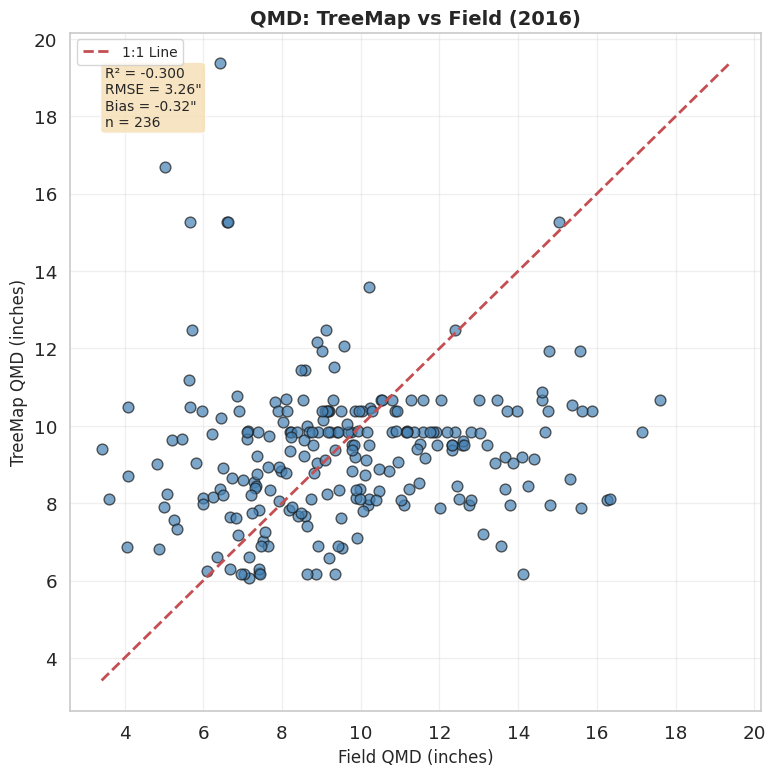

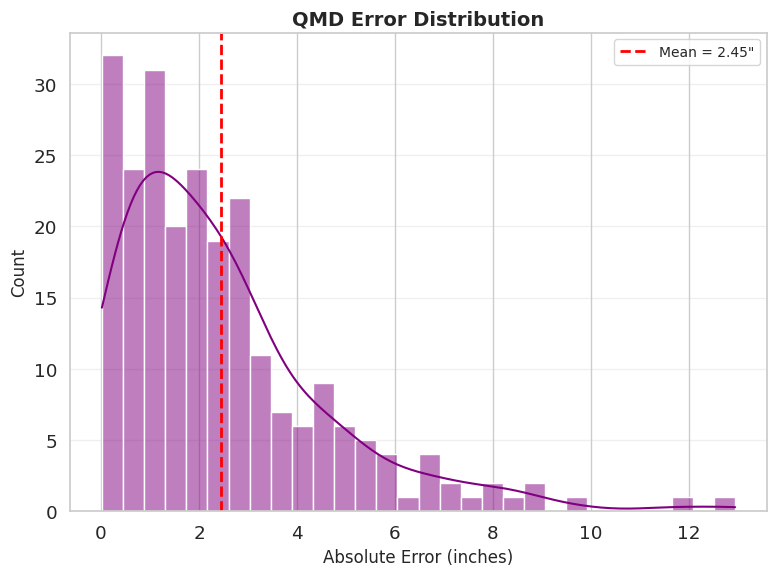

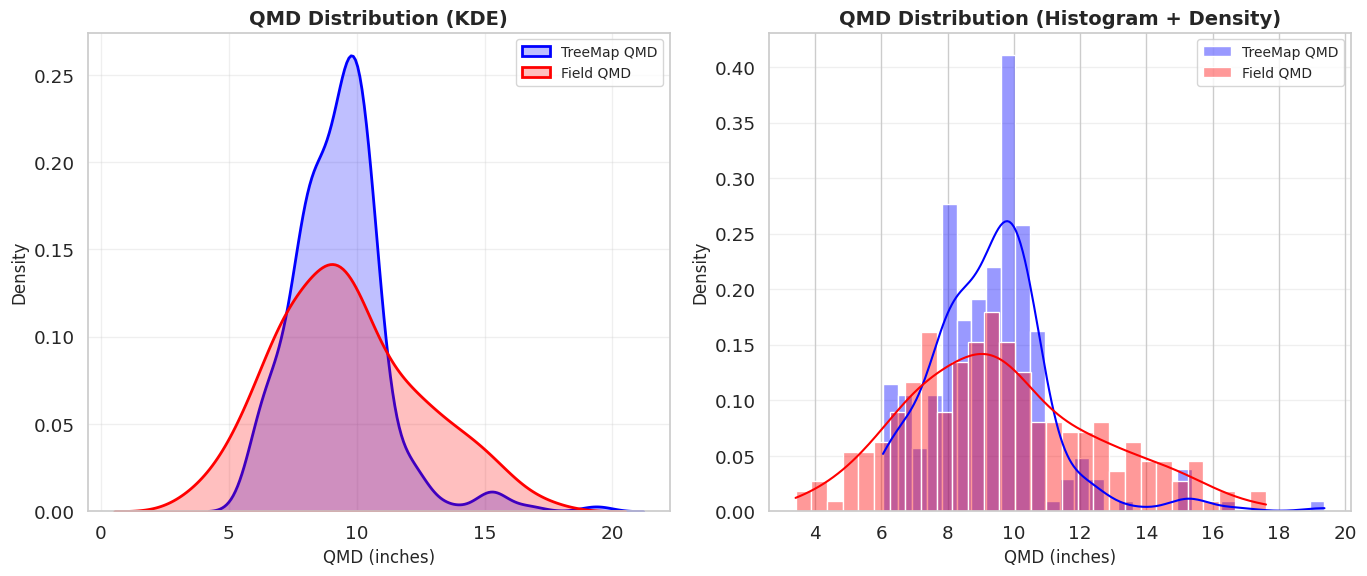

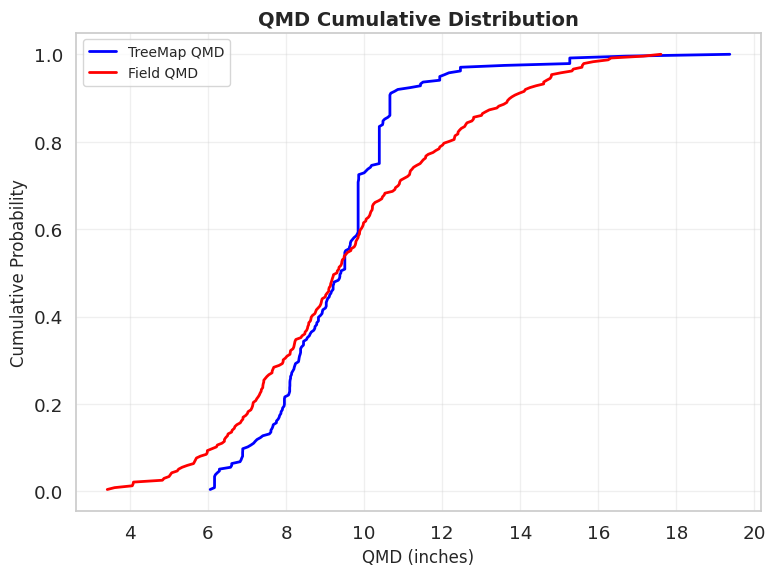


✅ QMD comparison saved to: /content/drive/MyDrive/QMD_comparison_2016.csv
✅ All QMD figures saved with 'Fig' prefix

✅ QMD COMPARISON COMPLETE

📊 Summary Statistics:

Field QMD:
count    236.000000
mean       9.620697
std        2.869480
min        3.417967
25%        7.429052
50%        9.308457
75%       11.445245
max       17.604886
Name: Field_QMD, dtype: float64

TreeMap QMD:
count    236.000000
mean       9.298891
std        1.823139
min        6.055036
25%        8.101142
50%        9.405177
75%       10.388677
max       19.368660
Name: TreeMap_QMD, dtype: float64

QMD Error:
count    236.000000
mean       2.452656
std        2.158526
min        0.016660
25%        0.912029
50%        1.967594
75%        3.193454
max       12.949678
Name: QMD_error, dtype: float64


In [7]:
# ============================================================
# Section 6: Quadratic Mean Diameter (QMD) Comparison
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt

# Set visualization style
sns.set(style="whitegrid", font_scale=1.2)

base_dir = "/content/drive/MyDrive"

print("="*60)
print("QUADRATIC MEAN DIAMETER (QMD) COMPARISON")
print("="*60)

# ============================
# 6.1 Field QMD Calculation
# ============================
print("\n1️⃣ Computing Field QMD...")

field_path = f"{base_dir}/TreeDataExport_editTY.csv"
talladega = pd.read_csv(field_path)

# Convert to numeric
talladega["Tree diameter (inches)"] = pd.to_numeric(
    talladega["Tree diameter (inches)"], errors="coerce"
)

# Filter valid diameters (DBH > 0)
talladega_clean = talladega[talladega["Tree diameter (inches)"] > 0].copy()

def qmd_with_N(d):
    """
    Calculate QMD with explicit N in formula:
    QMD = sqrt(sum(DBH^2) / N)

    Parameters:
    - d: Series of diameter values

    Returns:
    - QMD value
    """
    d = d.dropna()
    N = len(d)
    if N == 0:
        return np.nan
    return np.sqrt((d**2).sum() / N)

# Calculate Field QMD per plot
field_qmd = (
    talladega_clean.groupby("ParentGlobalID *")["Tree diameter (inches)"]
    .apply(qmd_with_N)
    .reset_index(name="Field_QMD")
)

print(f"   ✅ Computed Field QMD for {len(field_qmd)} plots")
print(f"   Mean Field QMD: {field_qmd['Field_QMD'].mean():.2f} inches")
print(f"   Range: {field_qmd['Field_QMD'].min():.2f} - {field_qmd['Field_QMD'].max():.2f} inches")

# ============================
# 6.2 TreeMap QMD Calculation
# ============================
print("\n2️⃣ Computing TreeMap QMD per polygon...")

treemap_path = f"{base_dir}/TreeMap{year}_tree_table.csv"
area_path = f"{base_dir}/final_area_summary_{year}_FINAL.csv"

treemap = pd.read_csv(treemap_path)
area_df = pd.read_csv(area_path)

# Detect TreeMap ID column
tm_id_col = None
for c in ["tm_id", "TM_ID", "Tm_ID", "TMID", "TmID"]:
    if c in treemap.columns:
        tm_id_col = c
        break
if tm_id_col is None:
    raise KeyError("❌ TreeMap ID column not found")

print(f"   Using TreeMap ID column: {tm_id_col}")

# Convert to numeric
treemap["DIA"] = pd.to_numeric(treemap["DIA"], errors="coerce")
treemap_clean = treemap[treemap["DIA"] >= 5].copy()

# Calculate QMD per TreeMap polygon
# QMD_DN = sqrt(sum(DIA^2) / N_DN)
treemap_clean["DIA2"] = treemap_clean["DIA"] ** 2

tm_stats = (
    treemap_clean
    .groupby(tm_id_col)
    .agg(
        DIA2_sum=("DIA2", "sum"),
        N=("DIA2", "size")
    )
    .reset_index()
)

tm_stats["QMD_DN"] = np.sqrt(tm_stats["DIA2_sum"] / tm_stats["N"])

print(f"   ✅ Computed TreeMap QMD for {len(tm_stats)} polygons")
print(f"   Mean TreeMap QMD: {tm_stats['QMD_DN'].mean():.2f} inches")

# ============================
# 6.3 Area-weighted QMD aggregation
# ============================
print("\n3️⃣ Aggregating TreeMap QMD to plots using area_ratio...")

# Merge TreeMap QMD with area ratios
merged = area_df.merge(
    tm_stats[[tm_id_col, "QMD_DN", "DIA2_sum", "N"]],
    left_on="DN",
    right_on=tm_id_col,
    how="left"
)

# Remove rows without QMD
merged = merged.dropna(subset=["QMD_DN"]).copy()

# [Fix 8] 原代码：QMD_plot = sqrt(sum(area_ratio * QMD_DN²))
# 问题：等价于面积加权，当各 polygon 树密度不同时有偏。
# 正确：QMD_plot = sqrt(Σ(area_ratio * DIA2_sum) / Σ(area_ratio * N))
# 即把 DIA²之和 和 树数量 分别加权后再合并，最后才开方。
merged["wDIA2_sum"] = merged["DIA2_sum"] * merged["area_ratio"]
merged["wN"]        = merged["N"]        * merged["area_ratio"]

plot_qmd_tm = (
    merged.groupby("globalid")
    .agg(total_wDIA2=("wDIA2_sum", "sum"),
         total_wN=("wN", "sum"))
    .reset_index()
)

plot_qmd_tm["TreeMap_QMD"] = np.sqrt(plot_qmd_tm["total_wDIA2"] / plot_qmd_tm["total_wN"])
plot_qmd_tm = plot_qmd_tm[["globalid", "TreeMap_QMD"]]

print(f"   ✅ Aggregated TreeMap QMD to {len(plot_qmd_tm)} plots")

# ============================
# 6.4 Merge and compute errors
# ============================
print("\n4️⃣ Comparing TreeMap QMD vs Field QMD...")

qmd_comp = plot_qmd_tm.merge(
    field_qmd,
    left_on="globalid",
    right_on="ParentGlobalID *",
    how="inner"
)

qmd_comp["QMD_error"] = (qmd_comp["TreeMap_QMD"] - qmd_comp["Field_QMD"]).abs()

print(f"   ✅ Matched {len(qmd_comp)} plots for comparison")

# ============================
# 6.5 Compute validation metrics
# ============================
print("\n" + "="*60)
print("VALIDATION METRICS")
print("="*60)

mse_qmd = mean_squared_error(qmd_comp["Field_QMD"], qmd_comp["TreeMap_QMD"])
rmse_qmd = np.sqrt(mse_qmd)
mae_qmd = mean_absolute_error(qmd_comp["Field_QMD"], qmd_comp["TreeMap_QMD"])
r2_qmd = r2_score(qmd_comp["Field_QMD"], qmd_comp["TreeMap_QMD"])
bias_qmd = (qmd_comp["TreeMap_QMD"] - qmd_comp["Field_QMD"]).mean()

print(f"\n📏 QMD Metrics ({year}):")
print(f"   RMSE  = {rmse_qmd:.3f} inches")
print(f"   MAE   = {mae_qmd:.3f} inches")
print(f"   R²    = {r2_qmd:.3f}")
print(f"   Bias  = {bias_qmd:.3f} inches")
print(f"   %RMSE = {(rmse_qmd / qmd_comp['Field_QMD'].mean()) * 100:.1f}%")

# ============================
# 6.6 Visualization
# ============================
print("\n5️⃣ Creating visualizations...")

# --------------------------------------
# Figure 1: Scatter plot with 1:1 line
# --------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    qmd_comp["Field_QMD"],
    qmd_comp["TreeMap_QMD"],
    alpha=0.7,
    edgecolor="k",
    s=60,
    color='steelblue'
)

max_q = max(qmd_comp["Field_QMD"].max(), qmd_comp["TreeMap_QMD"].max())
min_q = min(qmd_comp["Field_QMD"].min(), qmd_comp["TreeMap_QMD"].min())

ax.plot([min_q, max_q], [min_q, max_q], "r--", linewidth=2, label="1:1 Line")

ax.set_title(f"QMD: TreeMap vs Field ({year})", fontweight="bold", fontsize=14)
ax.set_xlabel("Field QMD (inches)", fontsize=12)
ax.set_ylabel("TreeMap QMD (inches)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Add metrics annotation
ax.text(
    0.05, 0.95,
    f'R² = {r2_qmd:.3f}\nRMSE = {rmse_qmd:.2f}"\nBias = {bias_qmd:.2f}"\nn = {len(qmd_comp)}',
    transform=ax.transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
    fontsize=10
)

plt.tight_layout()
plt.savefig(f"{base_dir}/Fig5_QMD_scatter_{year}.png", dpi=300, bbox_inches="tight")
plt.show()

# --------------------------------------
# Figure 2: Error distribution
# --------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

sns.histplot(
    qmd_comp["QMD_error"],
    bins=30,
    kde=True,
    color="purple",
    ax=ax
)

ax.set_title("QMD Error Distribution", fontweight="bold", fontsize=14)
ax.set_xlabel("Absolute Error (inches)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.axvline(
    qmd_comp["QMD_error"].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean = {qmd_comp["QMD_error"].mean():.2f}"'
)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{base_dir}/Fig6_QMD_error_distribution_{year}.png", dpi=300, bbox_inches="tight")
plt.show()

# --------------------------------------
# Figure 3: Distribution comparison
# --------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# KDE comparison
sns.kdeplot(
    qmd_comp["TreeMap_QMD"],
    label="TreeMap QMD",
    ax=axes[0],
    fill=True,
    linewidth=2,
    color='blue'
)
sns.kdeplot(
    qmd_comp["Field_QMD"],
    label="Field QMD",
    ax=axes[0],
    fill=True,
    linewidth=2,
    color='red'
)
axes[0].set_title("QMD Distribution (KDE)", fontweight="bold", fontsize=14)
axes[0].set_xlabel("QMD (inches)", fontsize=12)
axes[0].set_ylabel("Density", fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Histogram comparison
sns.histplot(
    qmd_comp["TreeMap_QMD"],
    bins=30,
    kde=True,
    color="blue",
    label="TreeMap QMD",
    stat="density",
    alpha=0.4,
    ax=axes[1]
)
sns.histplot(
    qmd_comp["Field_QMD"],
    bins=30,
    kde=True,
    color="red",
    label="Field QMD",
    stat="density",
    alpha=0.4,
    ax=axes[1]
)
axes[1].set_title("QMD Distribution (Histogram + Density)", fontweight="bold", fontsize=14)
axes[1].set_xlabel("QMD (inches)", fontsize=12)
axes[1].set_ylabel("Density", fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{base_dir}/Fig7_QMD_distributions_{year}.png", dpi=300, bbox_inches="tight")
plt.show()

# --------------------------------------
# Figure 4: Cumulative Distribution (CDF)
# --------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

# Sort data for CDF
tm_sorted = np.sort(qmd_comp["TreeMap_QMD"].dropna())
fd_sorted = np.sort(qmd_comp["Field_QMD"].dropna())

# Compute cumulative probabilities
tm_cdf = np.arange(1, len(tm_sorted)+1) / len(tm_sorted)
fd_cdf = np.arange(1, len(fd_sorted)+1) / len(fd_sorted)

ax.plot(tm_sorted, tm_cdf, label="TreeMap QMD", linewidth=2, color='blue')
ax.plot(fd_sorted, fd_cdf, label="Field QMD", linewidth=2, color='red')

ax.set_title("QMD Cumulative Distribution", fontweight="bold", fontsize=14)
ax.set_xlabel("QMD (inches)", fontsize=12)
ax.set_ylabel("Cumulative Probability", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{base_dir}/Fig8_QMD_CDF_{year}.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================
# 6.7 Save results
# ============================
qmd_output_path = f"{base_dir}/QMD_comparison_{year}.csv"
qmd_comp.to_csv(qmd_output_path, index=False)

print(f"\n✅ QMD comparison saved to: {qmd_output_path}")
print(f"✅ All QMD figures saved with 'Fig' prefix")

print("\n" + "="*60)
print("✅ QMD COMPARISON COMPLETE")
print("="*60)

# ============================
# 6.8 Summary statistics table
# ============================
print("\n📊 Summary Statistics:")
print("\nField QMD:")
print(qmd_comp["Field_QMD"].describe())
print("\nTreeMap QMD:")
print(qmd_comp["TreeMap_QMD"].describe())
print("\nQMD Error:")
print(qmd_comp["QMD_error"].describe())

# 7: Basal Area (BA) and Live Basal Area (BALIVE) Comparison

BASAL AREA (BA) AND BALIVE COMPARISON

1️⃣ Computing Field BA and BALIVE...
   ✅ Computed Field BA for 255 plots
   Mean Field BA (sum per plot): 10.202 sqft/plot
   Mean Field BALIVE: 102.02 sqft/acre

   🔍 Sanity check:
      Expected BALIVE range: ~50-200 sqft/acre for typical forests
      Actual range: 1.4 - 232.1 sqft/acre

2️⃣ Computing TreeMap BA and BALIVE...
   Using TreeMap ID column: tm_id


/tmp/ipython-input-747/4276086672.py:101: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  treemap_clean["TPA_UNADJ"].fillna(6.018, inplace=True)


   ⚠️ TPA_UNADJ varies within 47875 polygons
      Using per-tree method
   ✅ Computed TreeMap BA for 55609 polygons
   Mean TreeMap BA (sum per polygon): 23.645 sqft/polygon
   Mean TreeMap BALIVE: 119.51 sqft/acre

3️⃣ Aggregating TreeMap BA to plots using area_ratio...
   ✅ Aggregated to 237 plots

4️⃣ Comparing TreeMap vs Field...
   ✅ Matched 236 plots for comparison

VALIDATION METRICS

📏 BA Metrics (2016):
   RMSE  = 8.945 sqft/plot
   MAE   = 7.097 sqft/plot
   R²    = -2.647
   Bias  = 5.547 sqft/plot
   %RMSE = 84.9%

📏 BALIVE Metrics (2016):
   RMSE  = 49.44 sqft/acre
   MAE   = 40.28 sqft/acre
   R²    = -0.114
   Bias  = 16.62 sqft/acre
   %RMSE = 46.9%

🔍 Result sanity check:
   Field BALIVE: 105.3 ± 46.9 sqft/acre
   TreeMap BALIVE: 122.0 ± 40.4 sqft/acre
   ✅ BALIVE values are in reasonable range

5️⃣ Creating visualizations...


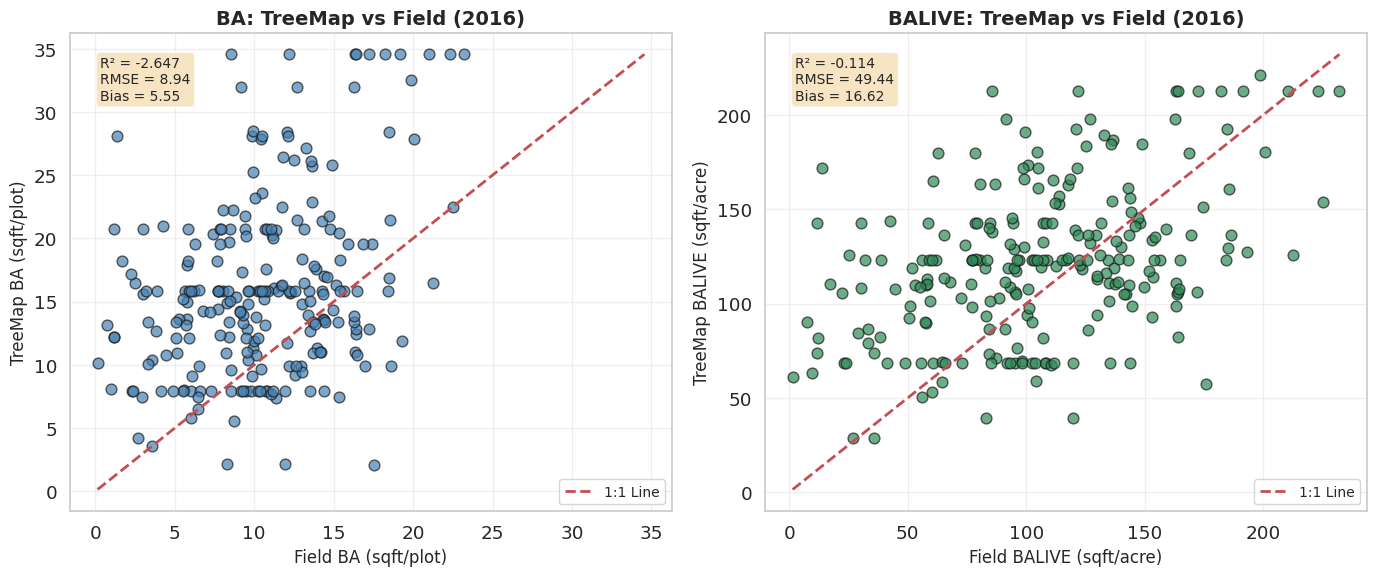

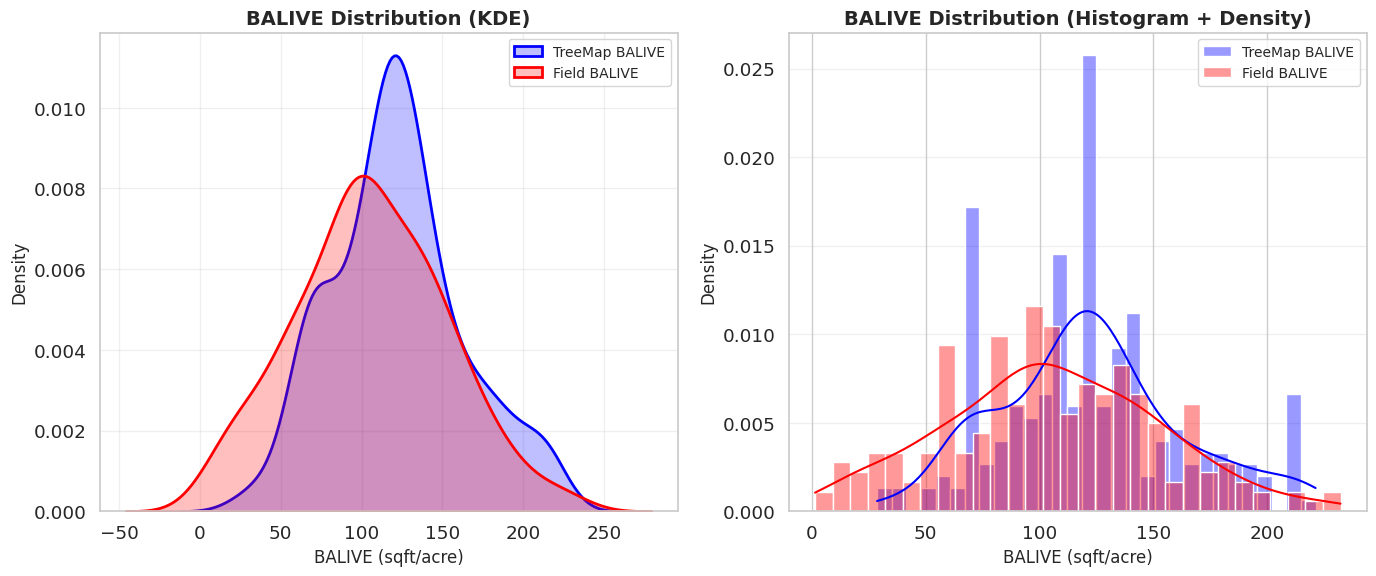

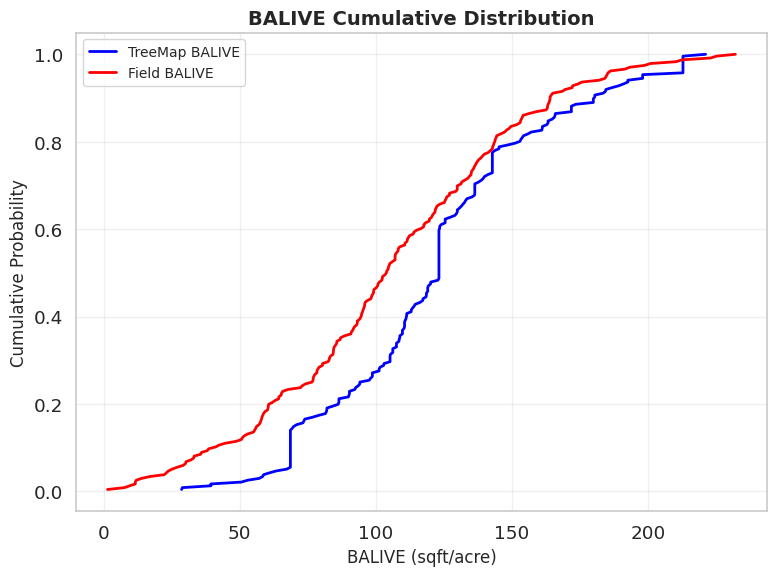

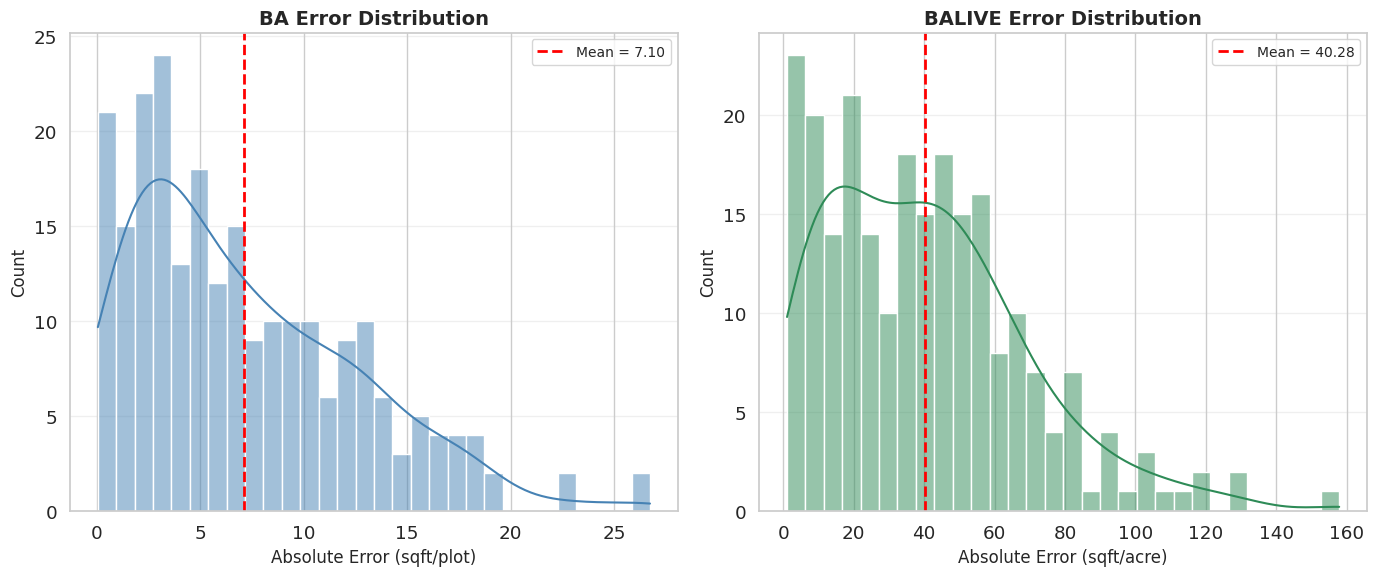


✅ BA/BALIVE comparison saved to: /content/drive/MyDrive/BA_BALIVE_comparison_2016.csv
✅ All BA/BALIVE figures saved with 'Fig' prefix

✅ BA AND BALIVE COMPARISON COMPLETE

📊 Summary Statistics:

Field BA (sqft/plot):
count    236.000000
mean      10.534161
std        4.693885
min        0.141804
25%        7.684713
50%       10.395406
75%       13.696289
max       23.212551
Name: Field_BA, dtype: float64

TreeMap BA (sqft/plot):
count    236.000000
mean      16.081255
std        7.105327
min        2.113986
25%       10.998214
50%       15.626706
75%       20.203111
max       34.560471
Name: TreeMap_BA, dtype: float64

Field BALIVE (sqft/acre):
count    236.000000
mean     105.341607
std       46.938852
min        1.418040
25%       76.847133
50%      103.954058
75%      136.962893
max      232.125512
Name: Field_BALIVE, dtype: float64

TreeMap BALIVE (sqft/acre):
count    236.000000
mean     121.958738
std       40.423336
min       28.633022
25%       96.709740
50%      123.193299
75

In [8]:
# ============================================================
# Section 7: Basal Area (BA) and BALIVE Comparison - CORRECTED
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt

# Set visualization style
sns.set(style="whitegrid", font_scale=1.2)

base_dir = "/content/drive/MyDrive"

print("="*60)
print("BASAL AREA (BA) AND BALIVE COMPARISON")
print("="*60)

# ============================
# 7.1 Field BA Calculation - CORRECTED
# ============================
print("\n1️⃣ Computing Field BA and BALIVE...")

field_path = f"{base_dir}/TreeDataExport_editTY.csv"
talladega = pd.read_csv(field_path)

# Convert to numeric
talladega["Tree diameter (inches)"] = pd.to_numeric(
    talladega["Tree diameter (inches)"], errors="coerce"
)

# Filter valid trees (DBH > 0)
talladega_clean = talladega[talladega["Tree diameter (inches)"] > 0].copy()

# Calculate basal area per tree (square feet)
# BA = 0.005454 × DBH²
talladega_clean["BA"] = 0.005454 * (talladega_clean["Tree diameter (inches)"] ** 2)

# 🔧 CORRECTED: Use SUM instead of MEAN
talladega_summary = talladega_clean.groupby("ParentGlobalID *").agg(
    Field_BA_sum=("BA", "sum"),  # ✅ CHANGED: sum instead of mean
    tree_count=("Tree diameter (inches)", "size")
).reset_index()

# Expansion factor for 1/10 acre plots
talladega_summary["TPA_UNADJ"] = 10.0

# Calculate BALIVE (total BA per plot × expansion factor)
talladega_summary["Field_BALIVE"] = (
    talladega_summary["Field_BA_sum"] * talladega_summary["TPA_UNADJ"]
)

print(f"   ✅ Computed Field BA for {len(talladega_summary)} plots")
print(f"   Mean Field BA (sum per plot): {talladega_summary['Field_BA_sum'].mean():.3f} sqft/plot")
print(f"   Mean Field BALIVE: {talladega_summary['Field_BALIVE'].mean():.2f} sqft/acre")

# Sanity check
print(f"\n   🔍 Sanity check:")
print(f"      Expected BALIVE range: ~50-200 sqft/acre for typical forests")
print(f"      Actual range: {talladega_summary['Field_BALIVE'].min():.1f} - {talladega_summary['Field_BALIVE'].max():.1f} sqft/acre")

# ============================
# 7.2 TreeMap BA Calculation - CORRECTED
# ============================
print("\n2️⃣ Computing TreeMap BA and BALIVE...")

treemap_path = f"{base_dir}/TreeMap{year}_tree_table.csv"
final_export_path = f"{base_dir}/final_area_summary_{year}_FINAL.csv"

treemap = pd.read_csv(treemap_path)
final_export_data = pd.read_csv(final_export_path)

# Detect TreeMap ID column
tm_id_col = None
for c in ["tm_id", "TM_ID", "Tm_ID", "TMID", "TmID"]:
    if c in treemap.columns:
        tm_id_col = c
        break
if tm_id_col is None:
    raise KeyError("❌ TreeMap ID column not found")

print(f"   Using TreeMap ID column: {tm_id_col}")

# Convert to numeric
treemap["DIA"] = pd.to_numeric(treemap["DIA"], errors="coerce")
treemap_clean = treemap[treemap["DIA"] > 0].copy()

# Calculate BA per tree
treemap_clean["BA"] = 0.005454 * (treemap_clean["DIA"] ** 2)

# Handle TPA_UNADJ
if "TPA_UNADJ" in treemap_clean.columns:
    treemap_clean["TPA_UNADJ"] = pd.to_numeric(
        treemap_clean["TPA_UNADJ"], errors="coerce"
    )
else:
    treemap_clean["TPA_UNADJ"] = np.nan

# Fill missing TPA_UNADJ with default FIA value
treemap_clean["TPA_UNADJ"].fillna(6.018, inplace=True)

# 🔧 CORRECTED: Calculate BALIVE per polygon properly
# Check if TPA varies within polygons
tpa_per_polygon = treemap_clean.groupby(tm_id_col)["TPA_UNADJ"].nunique()
tpa_varies = (tpa_per_polygon > 1).sum()

if tpa_varies == 0:
    print(f"   ✅ TPA_UNADJ is constant per polygon")
    print(f"      Using sum-then-multiply method")

    # Method 1: TPA constant per polygon
    # Sum BA per polygon, then multiply by TPA
    treemap_summary = treemap_clean.groupby(tm_id_col).agg(
        BA_sum=("BA", "sum"),  # ✅ CHANGED: sum instead of mean
        TPA_UNADJ=("TPA_UNADJ", "first")
    ).reset_index()

    treemap_summary["BALIVE_polygon"] = (
        treemap_summary["BA_sum"] * treemap_summary["TPA_UNADJ"]
    )
else:
    print(f"   ⚠️ TPA_UNADJ varies within {tpa_varies} polygons")
    print(f"      Using per-tree method")

    # Method 2: TPA varies per tree
    # Calculate BALIVE per tree, then sum
    treemap_clean["BALIVE_tree"] = treemap_clean["BA"] * treemap_clean["TPA_UNADJ"]

    treemap_summary = treemap_clean.groupby(tm_id_col).agg(
        BA_sum=("BA", "sum"),  # ✅ CHANGED: sum instead of mean
        BALIVE_polygon=("BALIVE_tree", "sum")  # ✅ CHANGED: sum instead of mean
    ).reset_index()

print(f"   ✅ Computed TreeMap BA for {len(treemap_summary)} polygons")
print(f"   Mean TreeMap BA (sum per polygon): {treemap_summary['BA_sum'].mean():.3f} sqft/polygon")
print(f"   Mean TreeMap BALIVE: {treemap_summary['BALIVE_polygon'].mean():.2f} sqft/acre")

# ============================
# 7.3 Area-weighted aggregation
# ============================
print("\n3️⃣ Aggregating TreeMap BA to plots using area_ratio...")

# Merge TreeMap BA with area ratios
weighted_attributes = final_export_data.merge(
    treemap_summary,
    left_on="DN",
    right_on=tm_id_col,
    how="left"
)

# Remove rows without BA/BALIVE
weighted_attributes = weighted_attributes.dropna(subset=["BA_sum", "BALIVE_polygon"]).copy()

# Calculate weighted attributes
weighted_attributes["weighted_BA"] = (
    weighted_attributes["BA_sum"] * weighted_attributes["area_ratio"]
)
weighted_attributes["weighted_BALIVE"] = (
    weighted_attributes["BALIVE_polygon"] * weighted_attributes["area_ratio"]
)

# Sum by plot
treemap_plot_summary = weighted_attributes.groupby("globalid").agg(
    TreeMap_BA=("weighted_BA", "sum"),
    TreeMap_BALIVE=("weighted_BALIVE", "sum")
).reset_index()

print(f"   ✅ Aggregated to {len(treemap_plot_summary)} plots")

# ============================
# 7.4 Merge and compute errors
# ============================
print("\n4️⃣ Comparing TreeMap vs Field...")

ba_comp = treemap_plot_summary.merge(
    talladega_summary[["ParentGlobalID *", "Field_BA_sum", "Field_BALIVE"]],
    left_on="globalid",
    right_on="ParentGlobalID *",
    how="inner"
)

# Rename for consistency
ba_comp.rename(columns={"Field_BA_sum": "Field_BA"}, inplace=True)

# Calculate errors
ba_comp["BA_error"] = (ba_comp["TreeMap_BA"] - ba_comp["Field_BA"]).abs()
ba_comp["BALIVE_error"] = (ba_comp["TreeMap_BALIVE"] - ba_comp["Field_BALIVE"]).abs()

print(f"   ✅ Matched {len(ba_comp)} plots for comparison")

# ============================
# 7.5 Compute validation metrics
# ============================
print("\n" + "="*60)
print("VALIDATION METRICS")
print("="*60)

# BA metrics (sum per plot, NOT per-tree mean!)
mse_ba = mean_squared_error(ba_comp["Field_BA"], ba_comp["TreeMap_BA"])
rmse_ba = np.sqrt(mse_ba)
mae_ba = mean_absolute_error(ba_comp["Field_BA"], ba_comp["TreeMap_BA"])
r2_ba = r2_score(ba_comp["Field_BA"], ba_comp["TreeMap_BA"])
bias_ba = (ba_comp["TreeMap_BA"] - ba_comp["Field_BA"]).mean()

print(f"\n📏 BA Metrics ({year}):")
print(f"   RMSE  = {rmse_ba:.3f} sqft/plot")  # Changed unit
print(f"   MAE   = {mae_ba:.3f} sqft/plot")   # Changed unit
print(f"   R²    = {r2_ba:.3f}")
print(f"   Bias  = {bias_ba:.3f} sqft/plot")  # Changed unit
print(f"   %RMSE = {(rmse_ba / ba_comp['Field_BA'].mean()) * 100:.1f}%")

# BALIVE metrics
mse_balive = mean_squared_error(ba_comp["Field_BALIVE"], ba_comp["TreeMap_BALIVE"])
rmse_balive = np.sqrt(mse_balive)
mae_balive = mean_absolute_error(ba_comp["Field_BALIVE"], ba_comp["TreeMap_BALIVE"])
r2_balive = r2_score(ba_comp["Field_BALIVE"], ba_comp["TreeMap_BALIVE"])
bias_balive = (ba_comp["TreeMap_BALIVE"] - ba_comp["Field_BALIVE"]).mean()

print(f"\n📏 BALIVE Metrics ({year}):")
print(f"   RMSE  = {rmse_balive:.2f} sqft/acre")
print(f"   MAE   = {mae_balive:.2f} sqft/acre")
print(f"   R²    = {r2_balive:.3f}")
print(f"   Bias  = {bias_balive:.2f} sqft/acre")
print(f"   %RMSE = {(rmse_balive / ba_comp['Field_BALIVE'].mean()) * 100:.1f}%")

# Sanity check on results
print(f"\n🔍 Result sanity check:")
print(f"   Field BALIVE: {ba_comp['Field_BALIVE'].mean():.1f} ± {ba_comp['Field_BALIVE'].std():.1f} sqft/acre")
print(f"   TreeMap BALIVE: {ba_comp['TreeMap_BALIVE'].mean():.1f} ± {ba_comp['TreeMap_BALIVE'].std():.1f} sqft/acre")
if ba_comp['Field_BALIVE'].mean() < 10:
    print(f"   ⚠️ WARNING: Field BALIVE seems too low - check calculation!")
elif ba_comp['Field_BALIVE'].mean() > 500:
    print(f"   ⚠️ WARNING: Field BALIVE seems too high - check calculation!")
else:
    print(f"   ✅ BALIVE values are in reasonable range")

# ============================
# 7.6 Visualization
# ============================
print("\n5️⃣ Creating visualizations...")

# --------------------------------------
# Figure 1: BA and BALIVE scatter plots
# --------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# BA scatter
axes[0].scatter(
    ba_comp["Field_BA"],
    ba_comp["TreeMap_BA"],
    alpha=0.7,
    edgecolor="k",
    s=60,
    color='steelblue'
)
max_ba = max(ba_comp["Field_BA"].max(), ba_comp["TreeMap_BA"].max())
min_ba = min(ba_comp["Field_BA"].min(), ba_comp["TreeMap_BA"].min())
axes[0].plot([min_ba, max_ba], [min_ba, max_ba], "r--", linewidth=2, label="1:1 Line")
axes[0].set_title(f"BA: TreeMap vs Field ({year})", fontweight="bold", fontsize=14)
axes[0].set_xlabel("Field BA (sqft/plot)", fontsize=12)  # Changed unit
axes[0].set_ylabel("TreeMap BA (sqft/plot)", fontsize=12)  # Changed unit
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Add metrics
axes[0].text(
    0.05, 0.95,
    f'R² = {r2_ba:.3f}\nRMSE = {rmse_ba:.2f}\nBias = {bias_ba:.2f}',
    transform=axes[0].transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
    fontsize=10
)

# BALIVE scatter
axes[1].scatter(
    ba_comp["Field_BALIVE"],
    ba_comp["TreeMap_BALIVE"],
    alpha=0.7,
    edgecolor="k",
    s=60,
    color='seagreen'
)
max_balive = max(ba_comp["Field_BALIVE"].max(), ba_comp["TreeMap_BALIVE"].max())
min_balive = min(ba_comp["Field_BALIVE"].min(), ba_comp["TreeMap_BALIVE"].min())
axes[1].plot([min_balive, max_balive], [min_balive, max_balive], "r--", linewidth=2, label="1:1 Line")
axes[1].set_title(f"BALIVE: TreeMap vs Field ({year})", fontweight="bold", fontsize=14)
axes[1].set_xlabel("Field BALIVE (sqft/acre)", fontsize=12)
axes[1].set_ylabel("TreeMap BALIVE (sqft/acre)", fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

# Add metrics
axes[1].text(
    0.05, 0.95,
    f'R² = {r2_balive:.3f}\nRMSE = {rmse_balive:.2f}\nBias = {bias_balive:.2f}',
    transform=axes[1].transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
    fontsize=10
)

plt.tight_layout()
plt.savefig(f"{base_dir}/Fig9_BA_BALIVE_scatter_{year}.png", dpi=300, bbox_inches="tight")
plt.show()

# --------------------------------------
# Figure 2: BALIVE distributions (KDE + Histogram)
# --------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# KDE
sns.kdeplot(
    ba_comp["TreeMap_BALIVE"],
    label="TreeMap BALIVE",
    ax=axes[0],
    fill=True,
    linewidth=2,
    color='blue'
)
sns.kdeplot(
    ba_comp["Field_BALIVE"],
    label="Field BALIVE",
    ax=axes[0],
    fill=True,
    linewidth=2,
    color='red'
)
axes[0].set_title("BALIVE Distribution (KDE)", fontweight="bold", fontsize=14)
axes[0].set_xlabel("BALIVE (sqft/acre)", fontsize=12)
axes[0].set_ylabel("Density", fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Histogram
sns.histplot(
    ba_comp["TreeMap_BALIVE"],
    bins=30,
    kde=True,
    color="blue",
    label="TreeMap BALIVE",
    stat="density",
    alpha=0.4,
    ax=axes[1]
)
sns.histplot(
    ba_comp["Field_BALIVE"],
    bins=30,
    kde=True,
    color="red",
    label="Field BALIVE",
    stat="density",
    alpha=0.4,
    ax=axes[1]
)
axes[1].set_title("BALIVE Distribution (Histogram + Density)", fontweight="bold", fontsize=14)
axes[1].set_xlabel("BALIVE (sqft/acre)", fontsize=12)
axes[1].set_ylabel("Density", fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{base_dir}/Fig10_BALIVE_distributions_{year}.png", dpi=300, bbox_inches="tight")
plt.show()

# --------------------------------------
# Figure 3: BALIVE CDF
# --------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

tm_sorted = np.sort(ba_comp["TreeMap_BALIVE"].dropna())
fd_sorted = np.sort(ba_comp["Field_BALIVE"].dropna())

tm_cdf = np.arange(1, len(tm_sorted)+1) / len(tm_sorted)
fd_cdf = np.arange(1, len(fd_sorted)+1) / len(fd_sorted)

ax.plot(tm_sorted, tm_cdf, label="TreeMap BALIVE", linewidth=2, color='blue')
ax.plot(fd_sorted, fd_cdf, label="Field BALIVE", linewidth=2, color='red')

ax.set_title("BALIVE Cumulative Distribution", fontweight="bold", fontsize=14)
ax.set_xlabel("BALIVE (sqft/acre)", fontsize=12)
ax.set_ylabel("Cumulative Probability", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{base_dir}/Fig11_BALIVE_CDF_{year}.png", dpi=300, bbox_inches="tight")
plt.show()

# --------------------------------------
# Figure 4: Error distributions
# --------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(
    ba_comp["BA_error"],
    bins=30,
    kde=True,
    color="steelblue",
    ax=axes[0]
)
axes[0].set_title("BA Error Distribution", fontweight="bold", fontsize=14)
axes[0].set_xlabel("Absolute Error (sqft/plot)", fontsize=12)  # Changed unit
axes[0].set_ylabel("Count", fontsize=12)
axes[0].axvline(
    ba_comp["BA_error"].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean = {ba_comp["BA_error"].mean():.2f}'
)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3, axis='y')

sns.histplot(
    ba_comp["BALIVE_error"],
    bins=30,
    kde=True,
    color="seagreen",
    ax=axes[1]
)
axes[1].set_title("BALIVE Error Distribution", fontweight="bold", fontsize=14)
axes[1].set_xlabel("Absolute Error (sqft/acre)", fontsize=12)
axes[1].set_ylabel("Count", fontsize=12)
axes[1].axvline(
    ba_comp["BALIVE_error"].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean = {ba_comp["BALIVE_error"].mean():.2f}'
)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{base_dir}/Fig12_BA_BALIVE_errors_{year}.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================
# 7.7 Save results
# ============================
ba_output_path = f"{base_dir}/BA_BALIVE_comparison_{year}.csv"
ba_comp.to_csv(ba_output_path, index=False)

print(f"\n✅ BA/BALIVE comparison saved to: {ba_output_path}")
print(f"✅ All BA/BALIVE figures saved with 'Fig' prefix")

print("\n" + "="*60)
print("✅ BA AND BALIVE COMPARISON COMPLETE")
print("="*60)

# ============================
# 7.8 Summary statistics
# ============================
print("\n📊 Summary Statistics:")
print("\nField BA (sqft/plot):")  # Changed description
print(ba_comp["Field_BA"].describe())
print("\nTreeMap BA (sqft/plot):")  # Changed description
print(ba_comp["TreeMap_BA"].describe())
print("\nField BALIVE (sqft/acre):")
print(ba_comp["Field_BALIVE"].describe())
print("\nTreeMap BALIVE (sqft/acre):")
print(ba_comp["TreeMap_BALIVE"].describe())

# 8: Species-Specific Volume Calculation and Comparison

SPECIES-SPECIFIC VOLUME COMPARISON

1️⃣ Loading volume coefficients...
   ✅ Loaded volume coefficients for 361 species

2️⃣ Computing TreeMap volume per polygon...
   Using TreeMap ID column: tm_id


/tmp/ipython-input-747/2762823001.py:65: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  treemap["TPA_UNADJ"].fillna(6.018, inplace=True)


   Trees before filter: 2076390
   Trees after filter (DIA >= 5): 1661563


/tmp/ipython-input-747/2762823001.py:81: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  treemap["a"].fillna(a_all, inplace=True)
/tmp/ipython-input-747/2762823001.py:82: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 


   ⚠️ HT缺失: 181726 棵 (2.67%)，开始填充...
   Level-1（同polygon均值）后仍缺失: 144 棵
   Level-2（同SPCD均值）后仍缺失: 0 棵

   📊 TreeMap volume statistics (per tree):
      Mean: 33.98 ft³/tree
      Median: 9.18 ft³/tree
      Range: 0.24 - 20768.05 ft³/tree

   ⚠️ TPA_UNADJ varies within 12007 polygons
      → Using per-tree TPA method

   ✅ Computed volume for 55215 TreeMap polygons
      Mean polygon volume: 14578.92 ft³/acre
      Median polygon volume: 10238.26 ft³/acre
      Range: 3.87 - 383119

   🔬 Volume Coefficient Coverage:
      Total trees: 6801785
      Species-specific: 6569139 (96.6%)
      Default coefficients: 232646 (3.4%)

3️⃣ Computing Field volume...
   ⚠️ Warning: 69 trees with unmatched species
   Trees before filter: 23486
   Trees after filter (DBH >= 5): 15870

   📊 Field volume statistics (per tree):
      Mean: 22.33 ft³/tree
      Median: 12.09 ft³/tree

   ✅ Computed volume for 253 field plots
      Mean plot volume: 13985.58 ft³/acre
      Median plot volume: 11078.62 ft³/a

/tmp/ipython-input-747/2762823001.py:190: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  talladega["a"].fillna(a_all, inplace=True)
/tmp/ipython-input-747/2762823001.py:191: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

   ✅ Aggregated to 237 plots

5️⃣ Comparing TreeMap vs Field volume...
   ✅ Matched 234 plots for comparison

VALIDATION METRICS

📏 Volume Metrics (2016):
   RMSE  = 10985.42 ft³/acre
   MAE   = 8485.30 ft³/acre
   R²    = -0.032
   Bias  = 99.92 ft³/acre
   %RMSE = 75.5%

📊 Comparison Summary:
   Field volume:   14545.98 ± 10836.73 ft³/acre
   TreeMap volume: 14645.89 ± 9456.18 ft³/acre
   Mean difference: 99.92 ft³/acre (0.7%)

SANITY CHECKS

✓ Field volume range: 144 - 58440 ft³/acre
✓ TreeMap volume range: 461 - 42531 ft³/acre

✅ Field volume (14546 ft³/acre) is reasonable

CREATING VISUALIZATIONS

📊 Figure 1: Volume scatter plot...


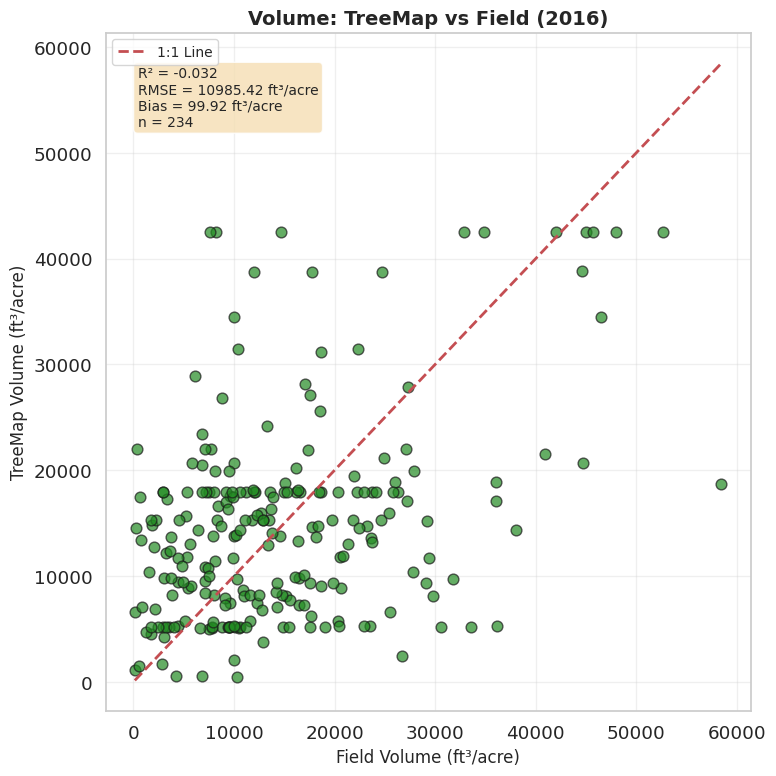


📊 Figure 2: Volume distribution...


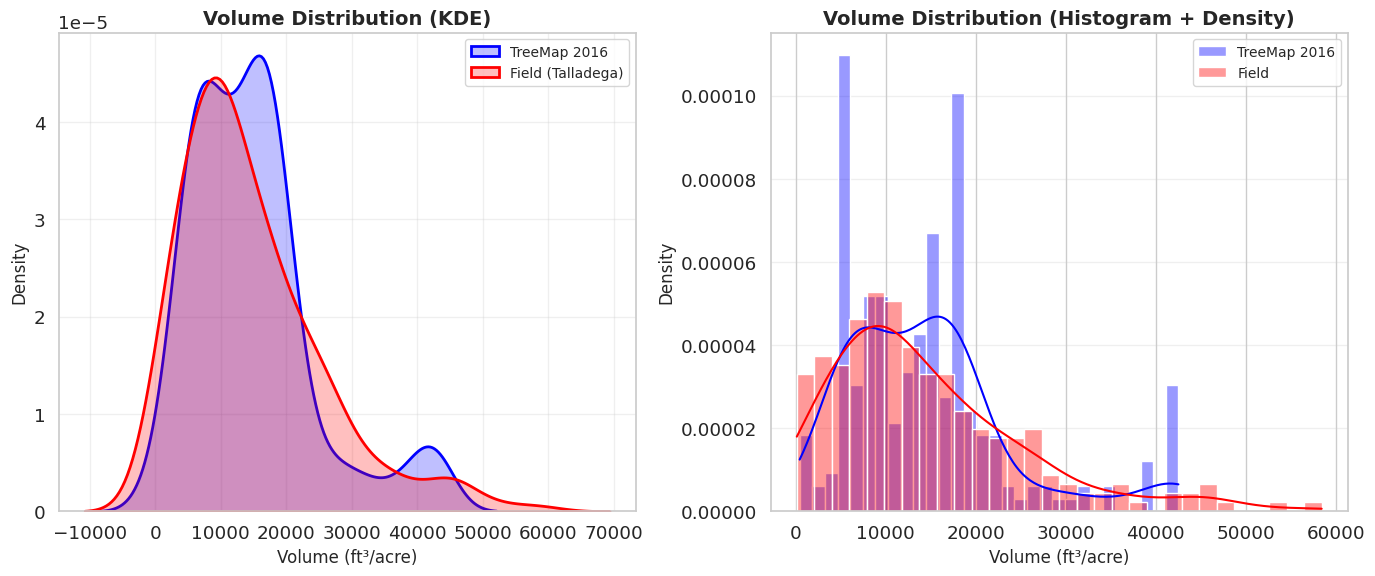


📊 Figure 3: Cumulative distribution...


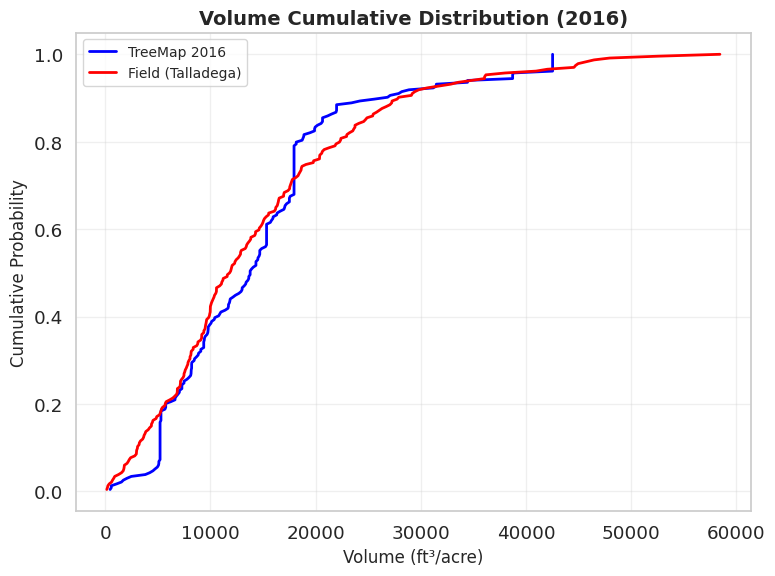


📊 Figure 4: Error distribution...


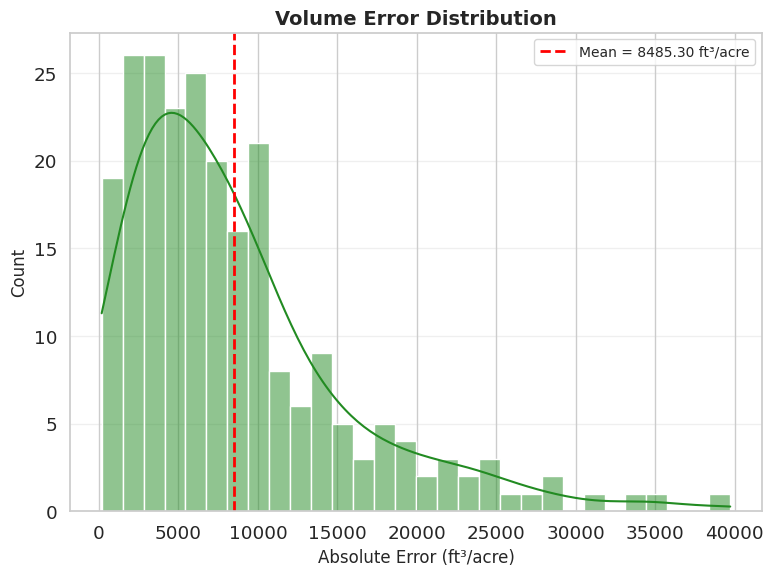


📊 Figure 5: Residual plot...


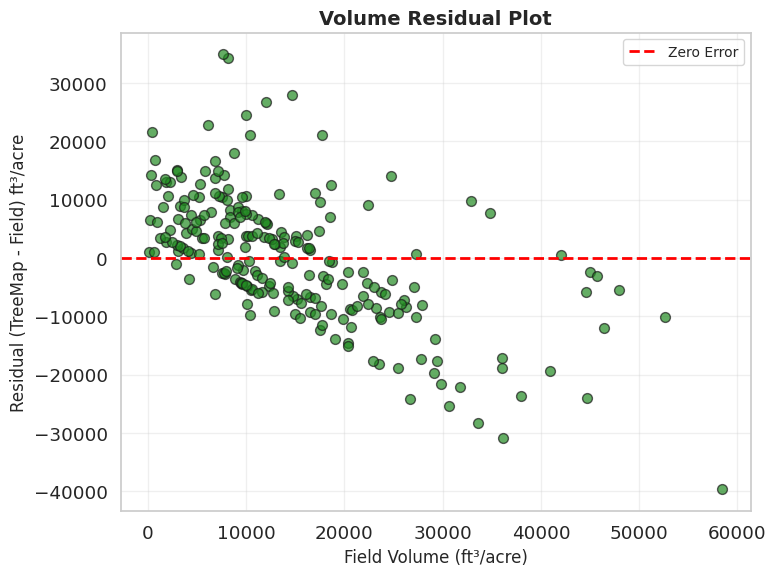


✅ Volume comparison saved to: /content/drive/MyDrive/Volume_comparison_2016.csv
✅ All volume figures saved (Fig13-Fig17)

✅ SPECIES-SPECIFIC VOLUME COMPARISON COMPLETE

📊 Summary Statistics:

Field Volume (ft³/acre):
count      234.000000
mean     14545.977604
std      10836.730999
min        143.781700
25%       7178.741241
50%      11874.139768
75%      19599.546617
max      58440.253650
Name: Field_VOL, dtype: float64

TreeMap Volume (ft³/acre):
count      234.000000
mean     14645.894257
std       9456.184543
min        461.195723
25%       7558.760036
50%      13774.500762
75%      17947.495848
max      42530.741527
Name: TreeMap_VOL, dtype: float64

Volume Error (ft³/acre):
count      234.000000
mean      8485.298283
std       6992.004956
min        168.424739
25%       3504.958875
50%       6689.378945
75%      10683.111351
max      39719.582902
Name: VOLUME_error, dtype: float64

🔬 Species Coverage:
   TreeMap unique species: 346
   Field unique species: 36

   TreeMap trees w

In [9]:
# ============================================================
# Section 8: Species-Specific Volume Comparison (COMPLETE)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", font_scale=1.2)
base_dir = "/content/drive/MyDrive"

print("="*80)
print("SPECIES-SPECIFIC VOLUME COMPARISON")
print("="*80)

# ============================
# 8.1 Load volume coefficients
# ============================
print("\n1️⃣ Loading volume coefficients...")

# Default all-species coefficients
a_all, b_all, c_all = 0.08168, 1.15697, 0.06573

# File paths
treemap_path = f"{base_dir}/TreeMap{year}_tree_table.csv"
talladega_path = f"{base_dir}/TreeDataExport_editTY.csv"
area_summary_path = f"{base_dir}/final_area_summary_{year}_FINAL.csv"
coef_path = f"{base_dir}/Table S3a_volob_coefs_spcd.csv"
species_ref_path = f"{base_dir}/species_ref_final.csv"

# Load coefficient table
coefs = pd.read_csv(coef_path)
coefs.columns = coefs.columns.str.lower()
coefs = coefs.rename(columns={"spcd": "SPCD", "coefa": "a", "coefb": "b", "coefc": "c"})

print(f"   ✅ Loaded volume coefficients for {len(coefs)} species")

# ============================
# 8.2 TreeMap volume calculation (CORRECTED)
# ============================
print("\n2️⃣ Computing TreeMap volume per polygon...")

treemap = pd.read_csv(treemap_path)

# Detect TreeMap ID column
tm_id_col = None
for col in ["tm_id", "TM_ID", "Tm_ID", "TMID", "TmID"]:
    if col in treemap.columns:
        tm_id_col = col
        break
if tm_id_col is None:
    raise KeyError("❌ TreeMap ID column not found")

print(f"   Using TreeMap ID column: {tm_id_col}")

# Convert to numeric
treemap["SPCD"] = pd.to_numeric(treemap.get("SPCD"), errors="coerce")
treemap["DIA"] = pd.to_numeric(treemap.get("DIA"), errors="coerce")
treemap["HT"] = pd.to_numeric(treemap.get("HT"), errors="coerce")
treemap["TPA_UNADJ"] = pd.to_numeric(treemap.get("TPA_UNADJ"), errors="coerce")

# Fill missing TPA_UNADJ
treemap["TPA_UNADJ"].fillna(6.018, inplace=True)

# Filter valid trees (DBH >= 5 inches)
treemap_original_count = len(treemap)
treemap = treemap[treemap["DIA"] >= 5].copy()

print(f"   Trees before filter: {treemap_original_count}")
print(f"   Trees after filter (DIA >= 5): {len(treemap)}")

# Merge with volume coefficients
treemap = treemap.merge(coefs, on="SPCD", how="left")

# Track coefficient usage
treemap["used_default_coef"] = treemap["a"].isna()

# Fill missing coefficients
treemap["a"].fillna(a_all, inplace=True)
treemap["b"].fillna(b_all, inplace=True)
treemap["c"].fillna(c_all, inplace=True)

ht_miss = treemap["HT"].isna().sum()
if ht_miss > 0:
    print(f"\n   ⚠️ HT缺失: {ht_miss} 棵 ({ht_miss/len(treemap)*100:.2f}%)，开始填充...")
    treemap["HT"] = treemap.groupby(tm_id_col)["HT"].transform(
        lambda x: x.fillna(x.mean()))
    still = treemap["HT"].isna().sum()
    print(f"   Level-1（同polygon均值）后仍缺失: {still} 棵")
    if still > 0:
        treemap["HT"] = treemap.groupby("SPCD")["HT"].transform(
            lambda x: x.fillna(x.mean()))
        still2 = treemap["HT"].isna().sum()
        print(f"   Level-2（同SPCD均值）后仍缺失: {still2} 棵")
        if still2 > 0:
            global_ht = treemap["HT"].mean()
            treemap["HT"].fillna(global_ht, inplace=True)
            print(f"   Level-3（全局均值={global_ht:.2f}ft）填充完毕")
else:
    print(f"\n   ✅ HT无缺失值")

# Calculate volume per tree (ft³/tree)
treemap["Vol_tree"] = (
    treemap["a"] *
    (treemap["DIA"] ** treemap["b"]) *
    (treemap["HT"] ** treemap["c"])
)

print(f"\n   📊 TreeMap volume statistics (per tree):")
print(f"      Mean: {treemap['Vol_tree'].mean():.2f} ft³/tree")
print(f"      Median: {treemap['Vol_tree'].median():.2f} ft³/tree")
print(f"      Range: {treemap['Vol_tree'].min():.2f} - {treemap['Vol_tree'].max():.2f} ft³/tree")

# 🔧 CORRECTED: Check TPA structure
tpa_per_polygon = treemap.groupby(tm_id_col)["TPA_UNADJ"].nunique()
tpa_varies = (tpa_per_polygon > 1).sum()

if tpa_varies == 0:
    print("\n   ✅ TPA_UNADJ is constant per polygon")
    print("      → Using correct aggregation method")

    # Method 1: TPA constant per polygon
    treemap_vol_by_DN = (
        treemap.groupby(tm_id_col)
        .agg({
            'Vol_tree': 'sum',
            'TPA_UNADJ': 'first'
        })
        .reset_index()
    )
    treemap_vol_by_DN["VOL_DN"] = (
        treemap_vol_by_DN["Vol_tree"] * treemap_vol_by_DN["TPA_UNADJ"]
    )
else:
    print(f"\n   ⚠️ TPA_UNADJ varies within {tpa_varies} polygons")
    print("      → Using per-tree TPA method")

    # Method 2: TPA varies per tree
    treemap["VOLUME_tree_acre"] = treemap["Vol_tree"] * treemap["TPA_UNADJ"]
    treemap_vol_by_DN = (
        treemap.groupby(tm_id_col)["VOLUME_tree_acre"]
        .sum()
        .reset_index()
        .rename(columns={"VOLUME_tree_acre": "VOL_DN"})
    )

print(f"\n   ✅ Computed volume for {len(treemap_vol_by_DN)} TreeMap polygons")
print(f"      Mean polygon volume: {treemap_vol_by_DN['VOL_DN'].mean():.2f} ft³/acre")
print(f"      Median polygon volume: {treemap_vol_by_DN['VOL_DN'].median():.2f} ft³/acre")
print(f"      Range: {treemap_vol_by_DN['VOL_DN'].min():.2f} - {treemap_vol_by_DN['VOL_DN'].max():.0f}")

# Coefficient coverage
total_trees = len(treemap)
default_count = treemap["used_default_coef"].sum()
specific_count = total_trees - default_count

print(f"\n   🔬 Volume Coefficient Coverage:")
print(f"      Total trees: {total_trees}")
print(f"      Species-specific: {specific_count} ({specific_count/total_trees*100:.1f}%)")
print(f"      Default coefficients: {default_count} ({default_count/total_trees*100:.1f}%)")

# ============================
# 8.3 Field volume calculation (CORRECTED)
# ============================
print("\n3️⃣ Computing Field volume...")

talladega = pd.read_csv(talladega_path)
species_ref = pd.read_csv(species_ref_path)

# Clean species names
talladega["Species"] = talladega["Species"].astype(str).str.strip().str.lower()
species_ref["Species"] = species_ref["Species"].astype(str).str.strip().str.lower()

# Merge to get SPCD
talladega = talladega.merge(species_ref, on="Species", how="left")

unmatched = talladega["SPCD"].isna().sum()
if unmatched > 0:
    print(f"   ⚠️ Warning: {unmatched} trees with unmatched species")

# Merge with volume coefficients
talladega = talladega.merge(coefs, on="SPCD", how="left")

# Track coefficient usage
talladega["used_default_coef"] = talladega["a"].isna()

# Fill missing coefficients
talladega["a"].fillna(a_all, inplace=True)
talladega["b"].fillna(b_all, inplace=True)
talladega["c"].fillna(c_all, inplace=True)

# Convert to numeric
talladega["Tree diameter (inches)"] = pd.to_numeric(
    talladega["Tree diameter (inches)"], errors="coerce"
)
talladega["Tree height (feet)"] = pd.to_numeric(
    talladega["Tree height (feet)"], errors="coerce"
)

# Filter valid trees
talladega_original_count = len(talladega)
talladega = talladega[talladega["Tree diameter (inches)"] >= 5].copy()

print(f"   Trees before filter: {talladega_original_count}")
print(f"   Trees after filter (DBH >= 5): {len(talladega)}")

# Calculate volume per tree
talladega["Vol_tree"] = (
    talladega["a"] *
    (talladega["Tree diameter (inches)"] ** talladega["b"]) *
    (talladega["Tree height (feet)"] ** talladega["c"])
)

print(f"\n   📊 Field volume statistics (per tree):")
print(f"      Mean: {talladega['Vol_tree'].mean():.2f} ft³/tree")
print(f"      Median: {talladega['Vol_tree'].median():.2f} ft³/tree")

# 🔧 CORRECTED: Aggregate then multiply by TPA
talladega_vol_by_plot = (
    talladega.groupby("ParentGlobalID *")["Vol_tree"]
    .sum()
    .reset_index()
)
talladega_vol_by_plot["Field_VOL"] = talladega_vol_by_plot["Vol_tree"] * 10.0

print(f"\n   ✅ Computed volume for {len(talladega_vol_by_plot)} field plots")
print(f"      Mean plot volume: {talladega_vol_by_plot['Field_VOL'].mean():.2f} ft³/acre")
print(f"      Median plot volume: {talladega_vol_by_plot['Field_VOL'].median():.2f} ft³/acre")
print(f"      Range: {talladega_vol_by_plot['Field_VOL'].min():.2f} - {talladega_vol_by_plot['Field_VOL'].max():.2f}")

# Field coefficient coverage
total_field_trees = len(talladega)
default_field = talladega["used_default_coef"].sum()
specific_field = total_field_trees - default_field

print(f"\n   🔬 Field Volume Coefficient Coverage:")
print(f"      Total trees: {total_field_trees}")
print(f"      Species-specific: {specific_field} ({specific_field/total_field_trees*100:.1f}%)")
print(f"      Default coefficients: {default_field} ({default_field/total_field_trees*100:.1f}%)")

# ============================
# 8.4 Area-weighted aggregation
# ============================
print("\n4️⃣ Aggregating TreeMap volume to plots using area_ratio...")

area_summary = pd.read_csv(area_summary_path)

area_with_vol = area_summary.merge(
    treemap_vol_by_DN,
    left_on="DN",
    right_on=tm_id_col,
    how="left"
)

area_with_vol = area_with_vol.dropna(subset=["VOL_DN"]).copy()

area_with_vol["VOL_DN_weighted"] = (
    area_with_vol["VOL_DN"] * area_with_vol["area_ratio"]
)

treemap_vol_by_plot = (
    area_with_vol
    .groupby("globalid")["VOL_DN_weighted"]
    .sum()
    .reset_index()
    .rename(columns={"VOL_DN_weighted": "TreeMap_VOL"})
)

print(f"   ✅ Aggregated to {len(treemap_vol_by_plot)} plots")

# ============================
# 8.5 Merge and compute errors
# ============================
print("\n5️⃣ Comparing TreeMap vs Field volume...")

comparison = treemap_vol_by_plot.merge(
    talladega_vol_by_plot,
    left_on="globalid",
    right_on="ParentGlobalID *",
    how="inner"
)

comparison["VOLUME_error"] = (comparison["TreeMap_VOL"] - comparison["Field_VOL"]).abs()

print(f"   ✅ Matched {len(comparison)} plots for comparison")

# ============================
# 8.6 Validation metrics
# ============================
print("\n" + "="*80)
print("VALIDATION METRICS")
print("="*80)

mse_vol = mean_squared_error(comparison["Field_VOL"], comparison["TreeMap_VOL"])
rmse_vol = np.sqrt(mse_vol)
mae_vol = mean_absolute_error(comparison["Field_VOL"], comparison["TreeMap_VOL"])
r2_vol = r2_score(comparison["Field_VOL"], comparison["TreeMap_VOL"])
bias_vol = (comparison["TreeMap_VOL"] - comparison["Field_VOL"]).mean()

print(f"\n📏 Volume Metrics ({year}):")
print(f"   RMSE  = {rmse_vol:.2f} ft³/acre")
print(f"   MAE   = {mae_vol:.2f} ft³/acre")
print(f"   R²    = {r2_vol:.3f}")
print(f"   Bias  = {bias_vol:.2f} ft³/acre")
print(f"   %RMSE = {(rmse_vol / comparison['Field_VOL'].mean()) * 100:.1f}%")

print(f"\n📊 Comparison Summary:")
print(f"   Field volume:   {comparison['Field_VOL'].mean():.2f} ± {comparison['Field_VOL'].std():.2f} ft³/acre")
print(f"   TreeMap volume: {comparison['TreeMap_VOL'].mean():.2f} ± {comparison['TreeMap_VOL'].std():.2f} ft³/acre")
print(f"   Mean difference: {bias_vol:.2f} ft³/acre ({(bias_vol/comparison['Field_VOL'].mean())*100:.1f}%)")

# ============================
# 8.7 Sanity checks
# ============================
print("\n" + "="*80)
print("SANITY CHECKS")
print("="*80)

print(f"\n✓ Field volume range: {comparison['Field_VOL'].min():.0f} - {comparison['Field_VOL'].max():.0f} ft³/acre")
print(f"✓ TreeMap volume range: {comparison['TreeMap_VOL'].min():.0f} - {comparison['TreeMap_VOL'].max():.0f} ft³/acre")

if comparison['Field_VOL'].mean() > 50000:
    print(f"\n⚠️ WARNING: Field volume ({comparison['Field_VOL'].mean():.0f}) seems too high!")
elif comparison['Field_VOL'].mean() < 500:
    print(f"\n⚠️ WARNING: Field volume ({comparison['Field_VOL'].mean():.0f}) seems too low!")
else:
    print(f"\n✅ Field volume ({comparison['Field_VOL'].mean():.0f} ft³/acre) is reasonable")

# ============================
# 8.8 Visualization
# ============================
print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

# Figure 1: Volume scatter plot
print("\n📊 Figure 1: Volume scatter plot...")
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    comparison["Field_VOL"],
    comparison["TreeMap_VOL"],
    alpha=0.7,
    edgecolor="k",
    s=60,
    color='forestgreen'
)

max_vol = max(comparison["Field_VOL"].max(), comparison["TreeMap_VOL"].max())
min_vol = min(comparison["Field_VOL"].min(), comparison["TreeMap_VOL"].min())

ax.plot([min_vol, max_vol], [min_vol, max_vol], "r--", linewidth=2, label="1:1 Line")

ax.set_title(f"Volume: TreeMap vs Field ({year})", fontweight="bold", fontsize=14)
ax.set_xlabel("Field Volume (ft³/acre)", fontsize=12)
ax.set_ylabel("TreeMap Volume (ft³/acre)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

ax.text(
    0.05, 0.95,
    f'R² = {r2_vol:.3f}\nRMSE = {rmse_vol:.2f} ft³/acre\nBias = {bias_vol:.2f} ft³/acre\nn = {len(comparison)}',
    transform=ax.transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
    fontsize=10
)

plt.tight_layout()
plt.savefig(f"{base_dir}/Fig13_Volume_scatter_{year}.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 2: Volume distribution comparison
print("\n📊 Figure 2: Volume distribution...")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# KDE
sns.kdeplot(
    comparison["TreeMap_VOL"],
    label=f"TreeMap {year}",
    ax=axes[0],
    fill=True,
    linewidth=2,
    color='blue'
)
sns.kdeplot(
    comparison["Field_VOL"],
    label="Field (Talladega)",
    ax=axes[0],
    fill=True,
    linewidth=2,
    color='red'
)
axes[0].set_title(f"Volume Distribution (KDE)", fontweight="bold", fontsize=14)
axes[0].set_xlabel("Volume (ft³/acre)", fontsize=12)
axes[0].set_ylabel("Density", fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Histogram
sns.histplot(
    comparison["TreeMap_VOL"],
    bins=30,
    kde=True,
    label=f"TreeMap {year}",
    color="blue",
    stat="density",
    alpha=0.4,
    ax=axes[1]
)
sns.histplot(
    comparison["Field_VOL"],
    bins=30,
    kde=True,
    label="Field",
    color="red",
    stat="density",
    alpha=0.4,
    ax=axes[1]
)
axes[1].set_title("Volume Distribution (Histogram + Density)", fontweight="bold", fontsize=14)
axes[1].set_xlabel("Volume (ft³/acre)", fontsize=12)
axes[1].set_ylabel("Density", fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{base_dir}/Fig14_Volume_distributions_{year}.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 3: Volume CDF
print("\n📊 Figure 3: Cumulative distribution...")
fig, ax = plt.subplots(figsize=(8, 6))

tm_sorted = np.sort(comparison["TreeMap_VOL"].dropna())
fd_sorted = np.sort(comparison["Field_VOL"].dropna())

tm_cdf = np.arange(1, len(tm_sorted)+1) / len(tm_sorted)
fd_cdf = np.arange(1, len(fd_sorted)+1) / len(fd_sorted)

ax.plot(tm_sorted, tm_cdf, label=f"TreeMap {year}", linewidth=2, color='blue')
ax.plot(fd_sorted, fd_cdf, label="Field (Talladega)", linewidth=2, color='red')

ax.set_title(f"Volume Cumulative Distribution ({year})", fontweight="bold", fontsize=14)
ax.set_xlabel("Volume (ft³/acre)", fontsize=12)
ax.set_ylabel("Cumulative Probability", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{base_dir}/Fig15_Volume_CDF_{year}.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 4: Volume error distribution
print("\n📊 Figure 4: Error distribution...")
fig, ax = plt.subplots(figsize=(8, 6))

sns.histplot(
    comparison["VOLUME_error"],
    bins=30,
    kde=True,
    color="forestgreen",
    ax=ax
)

ax.set_title("Volume Error Distribution", fontweight="bold", fontsize=14)
ax.set_xlabel("Absolute Error (ft³/acre)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.axvline(
    comparison["VOLUME_error"].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean = {comparison["VOLUME_error"].mean():.2f} ft³/acre'
)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{base_dir}/Fig16_Volume_error_distribution_{year}.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 5: Volume residual plot
print("\n📊 Figure 5: Residual plot...")
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    comparison["Field_VOL"],
    comparison["TreeMap_VOL"] - comparison["Field_VOL"],
    alpha=0.7,
    edgecolor="k",
    s=50,
    color='forestgreen'
)

ax.axhline(0, color="red", linestyle="--", linewidth=2, label="Zero Error")
ax.set_title("Volume Residual Plot", fontweight="bold", fontsize=14)
ax.set_xlabel("Field Volume (ft³/acre)", fontsize=12)
ax.set_ylabel("Residual (TreeMap - Field) ft³/acre", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{base_dir}/Fig17_Volume_residuals_{year}.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================
# 8.9 Save results
# ============================
vol_output_path = f"{base_dir}/Volume_comparison_{year}.csv"
comparison.to_csv(vol_output_path, index=False)

print(f"\n✅ Volume comparison saved to: {vol_output_path}")
print(f"✅ All volume figures saved (Fig13-Fig17)")

print("\n" + "="*80)
print("✅ SPECIES-SPECIFIC VOLUME COMPARISON COMPLETE")
print("="*80)

# ============================
# 8.10 Summary statistics
# ============================
print("\n📊 Summary Statistics:")
print("\nField Volume (ft³/acre):")
print(comparison["Field_VOL"].describe())
print("\nTreeMap Volume (ft³/acre):")
print(comparison["TreeMap_VOL"].describe())
print("\nVolume Error (ft³/acre):")
print(comparison["VOLUME_error"].describe())

# ============================
# 8.11 Species coverage
# ============================
print("\n🔬 Species Coverage:")
tm_species = treemap["SPCD"].dropna().nunique()
fd_species = talladega["SPCD"].dropna().nunique()
print(f"   TreeMap unique species: {tm_species}")
print(f"   Field unique species: {fd_species}")

tm_with_coef = (~treemap["used_default_coef"]).sum()
fd_with_coef = (~talladega["used_default_coef"]).sum()
print(f"\n   TreeMap trees with specific coefficients: {tm_with_coef} ({tm_with_coef/len(treemap)*100:.1f}%)")
print(f"   Field trees with specific coefficients: {fd_with_coef} ({fd_with_coef/len(talladega)*100:.1f}%)")

# 9: Species Composition Analysis

In [10]:
# ============================================================
# Step 1: Explore All Species in Dataset
# ============================================================

import pandas as pd
import numpy as np

base_dir = "/content/drive/MyDrive"

print("="*60)
print("SPECIES EXPLORATION - PRELIMINARY ANALYSIS")
print("="*60)

# Load data
talladega_path = f"{base_dir}/TreeDataExport_editTY.csv"
species_ref_path = f"{base_dir}/species_ref_final.csv"

talladega = pd.read_csv(talladega_path)
species_ref = pd.read_csv(species_ref_path)

# Clean species names
talladega["Species"] = talladega["Species"].astype(str).str.strip().str.lower()
species_ref["Species"] = species_ref["Species"].astype(str).str.strip().str.lower()

# Merge to get SPCD
talladega = talladega.merge(species_ref, on="Species", how="left")

print(f"\n📊 Dataset Overview:")
print(f"   Total trees: {len(talladega):,}")
print(f"   Unique species: {talladega['Species'].nunique()}")
print(f"   Trees with SPCD: {talladega['SPCD'].notna().sum():,}")
print(f"   Trees without SPCD: {talladega['SPCD'].isna().sum():,}")

# ============================
# Show ALL species
# ============================
print("\n" + "="*60)
print("ALL SPECIES IN DATASET (sorted by count)")
print("="*60)

species_full_list = (
    talladega.groupby(["Species", "SPCD"])
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

species_full_list["Percentage"] = (species_full_list["Count"] / len(talladega) * 100).round(2)
species_full_list["Cumulative_%"] = species_full_list["Percentage"].cumsum().round(2)

print(f"\nTotal unique species: {len(species_full_list)}\n")

# Display all species
for idx, row in species_full_list.iterrows():
    spcd_str = f"SPCD {int(row['SPCD'])}" if pd.notna(row['SPCD']) else "No SPCD"
    print(f"{idx+1:3d}. {row['Species']:30s} ({spcd_str:15s}): {row['Count']:5d} trees ({row['Percentage']:5.2f}%) | Cumulative: {row['Cumulative_%']:5.2f}%")

# ============================
# Identify species without SPCD
# ============================
print("\n" + "="*60)
print("SPECIES WITHOUT SPCD (need to check species_ref)")
print("="*60)

no_spcd = species_full_list[species_full_list["SPCD"].isna()]
if len(no_spcd) > 0:
    print(f"\n⚠️ Found {len(no_spcd)} species without SPCD codes:")
    for idx, row in no_spcd.iterrows():
        print(f"   - {row['Species']:30s}: {row['Count']:5d} trees ({row['Percentage']:.2f}%)")
else:
    print("\n✅ All species have SPCD codes")

# ============================
# Show SPCD distribution
# ============================
print("\n" + "="*60)
print("SPCD CODE PATTERNS")
print("="*60)

spcd_ranges = {
    "100-199 (Softwoods - Pines)": (100, 199),
    "200-299 (Softwoods - Other)": (200, 299),
    "300-399 (Hardwoods - Maples, Hickories)": (300, 399),
    "400-499 (Hardwoods - Various)": (400, 499),
    "500-599 (Hardwoods - Birches, Hollies)": (500, 599),
    "600-699 (Hardwoods - Sweetgum, Blackgum)": (600, 699),
    "700-799 (Hardwoods - Dogwood, Sourwood)": (700, 799),
    "800-899 (Hardwoods - Oaks)": (800, 899),
    "900+ (Hardwoods - Other)": (900, 9999)
}

print("\nSPCD Code Distribution:")
for range_name, (start, end) in spcd_ranges.items():
    count = talladega[(talladega["SPCD"] >= start) & (talladega["SPCD"] <= end)]["SPCD"].count()
    if count > 0:
        pct = (count / len(talladega)) * 100
        print(f"   {range_name:50s}: {count:5d} trees ({pct:5.2f}%)")

# ============================
# Save full list for reference
# ============================
output_path = f"{base_dir}/ALL_Species_List_Complete.csv"
species_full_list.to_csv(output_path, index=False)
print(f"\n✅ Full species list saved to: {output_path}")

print("\n" + "="*60)
print("EXPLORATION COMPLETE - Ready for grouping decision")
print("="*60)

SPECIES EXPLORATION - PRELIMINARY ANALYSIS

📊 Dataset Overview:
   Total trees: 6,431
   Unique species: 44
   Trees with SPCD: 6,362
   Trees without SPCD: 69

ALL SPECIES IN DATASET (sorted by count)

Total unique species: 37

 14. longleaf pine                  (SPCD 121       ):  1653 trees (25.70%) | Cumulative: 25.70%
 13. loblolly pine                  (SPCD 131       ):  1313 trees (20.42%) | Cumulative: 46.12%
 24. shortleaf pine                 (SPCD 110       ):   424 trees ( 6.59%) | Cumulative: 52.71%
 33. virginia pine                  (SPCD 132       ):   369 trees ( 5.74%) | Cumulative: 58.45%
 21. red maple                      (SPCD 316       ):   321 trees ( 4.99%) | Cumulative: 63.44%
 17. northern red                   (SPCD 833       ):   308 trees ( 4.79%) | Cumulative: 68.23%
 25. sourwood                       (SPCD 711       ):   284 trees ( 4.42%) | Cumulative: 72.65%
  8. chestnut oak                   (SPCD 832       ):   214 trees ( 3.33%) | Cumulative: 75

SPECIES COMPOSITION ANALYSIS

1️⃣ Loading field data and species reference...
   Total trees in dataset: 6,431
   Unique species: 44
   Trees with SPCD: 6,362 (98.9%)

2️⃣ Defining species groups (3 groups: Pine, Oak, Other)...

   Species Group Distribution:
   Pine                : 3,759 trees ( 58.5%)
   Other Hardwood      : 1,624 trees ( 25.3%)
   Oak                 :   979 trees ( 15.2%)
   Unknown             :    69 trees (  1.1%)

3️⃣ Top 20 species by tree count...

   Top 20 Species:
          Species   SPCD  Species_Group  Count
    longleaf pine  121.0           Pine   1653
    loblolly pine  131.0           Pine   1313
   shortleaf pine  110.0           Pine    424
    virginia pine  132.0           Pine    369
        red maple  316.0 Other Hardwood    321
     northern red  833.0            Oak    308
         sourwood  711.0 Other Hardwood    284
     chestnut oak  832.0            Oak    214
         sweetgum  611.0 Other Hardwood    200
        white oak  802.0     

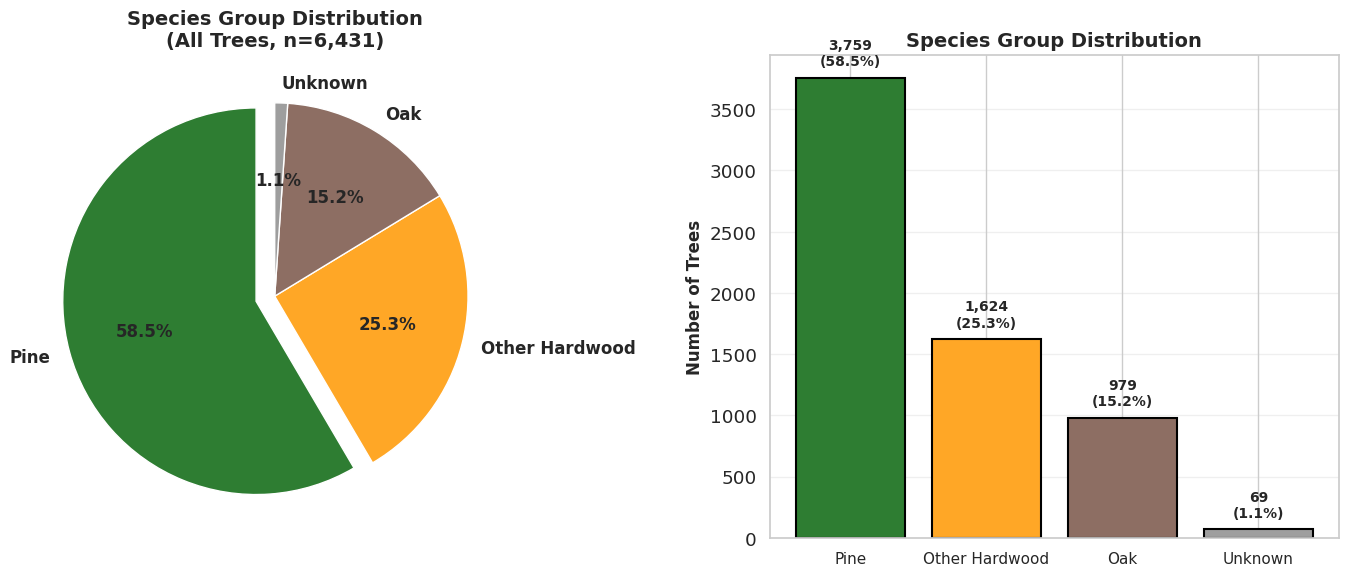

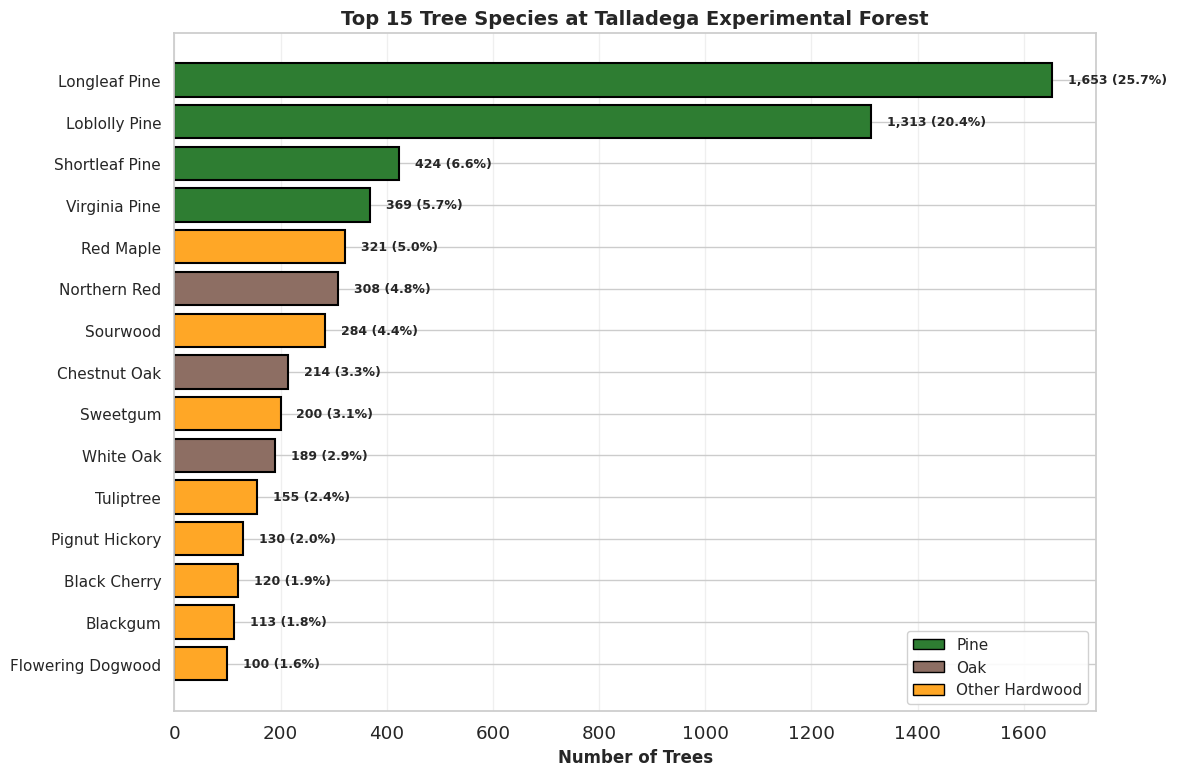

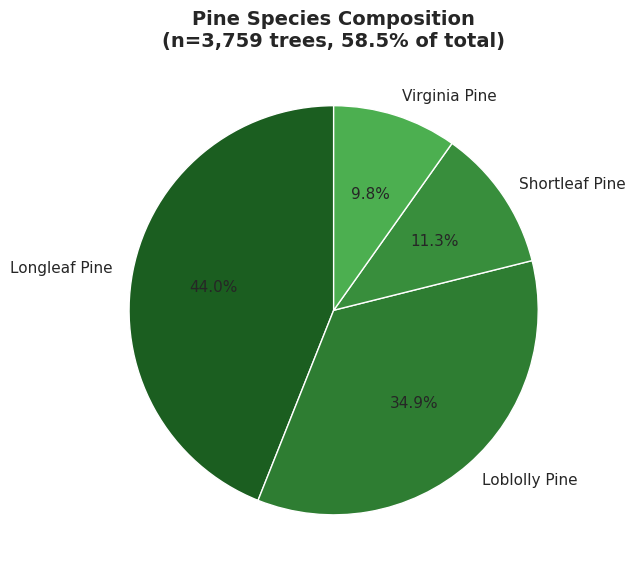

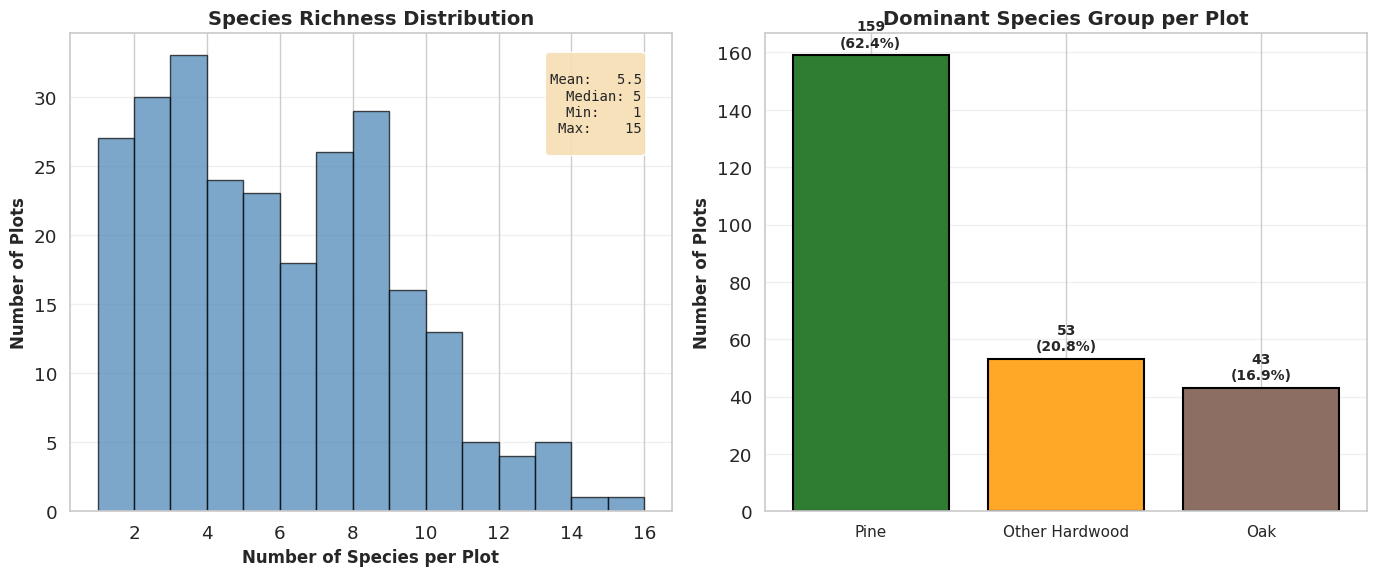


5️⃣ Saving results...
   ✅ Summary saved: /content/drive/MyDrive/Species_Composition_Summary.csv
   ✅ Detailed list saved: /content/drive/MyDrive/Species_List_Detailed.csv

✅ SPECIES COMPOSITION ANALYSIS COMPLETE

📊 Statistical Summary:

Total trees analyzed: 6,431
Total unique species: 44
Plots with species data: 255

🌲 Species Group Proportions:
   Pine                :  58.5% (3,759 trees)
   Oak                 :  15.2% (979 trees)
   Other Hardwood      :  25.3% (1,624 trees)
   Unknown             :   1.1% (69 trees)

🌳 Species Richness:
   Mean species per plot:   5.45
   Median species per plot: 5
   Range: 1-15 species

🏆 Top 5 Most Abundant Species:
   1. Longleaf Pine             (Pine           ): 1,653 trees (25.7%)
   2. Loblolly Pine             (Pine           ): 1,313 trees (20.4%)
   3. Shortleaf Pine            (Pine           ): 424 trees (6.6%)
   4. Virginia Pine             (Pine           ): 369 trees (5.7%)
   5. Red Maple                 (Other Hardwood ): 32

In [11]:
# ============================================================
# Section 9: Species Composition Analysis - CORRECTED
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set(style="whitegrid", font_scale=1.2)

base_dir = "/content/drive/MyDrive"

print("="*60)
print("SPECIES COMPOSITION ANALYSIS")
print("="*60)

# ============================
# 9.1 Load data
# ============================
print("\n1️⃣ Loading field data and species reference...")

talladega_path = f"{base_dir}/TreeDataExport_editTY.csv"
species_ref_path = f"{base_dir}/species_ref_final.csv"

talladega = pd.read_csv(talladega_path)
species_ref = pd.read_csv(species_ref_path)

# Clean species names
talladega["Species"] = talladega["Species"].astype(str).str.strip().str.lower()
species_ref["Species"] = species_ref["Species"].astype(str).str.strip().str.lower()

# Merge to get SPCD
talladega = talladega.merge(species_ref, on="Species", how="left")

print(f"   Total trees in dataset: {len(talladega):,}")
print(f"   Unique species: {talladega['Species'].nunique()}")
print(f"   Trees with SPCD: {talladega['SPCD'].notna().sum():,} ({talladega['SPCD'].notna().sum()/len(talladega)*100:.1f}%)")

# ============================
# 9.2 Define species groups - SIMPLIFIED TO 3 GROUPS
# ============================
print("\n2️⃣ Defining species groups (3 groups: Pine, Oak, Other)...")

# Pine species: SPCD 100-199
# Oak species: SPCD 800-899
# Other: everything else

def classify_species(spcd):
    if pd.isna(spcd):
        return "Unknown"
    spcd = int(spcd)

    # Pine (all Pinus species): SPCD 100-199
    if 100 <= spcd <= 199:
        return "Pine"
    # Oak (all Quercus species): SPCD 800-899
    elif 800 <= spcd <= 899:
        return "Oak"
    # Everything else
    else:
        return "Other Hardwood"

talladega["Species_Group"] = talladega["SPCD"].apply(classify_species)

# Count by group
group_counts = talladega["Species_Group"].value_counts()
print("\n   Species Group Distribution:")
for group, count in group_counts.items():
    pct = (count / len(talladega)) * 100
    print(f"   {group:20s}: {count:5,d} trees ({pct:5.1f}%)")

# ============================
# 9.3 Detailed species breakdown
# ============================
print("\n3️⃣ Top 20 species by tree count...")

# Get species names from SPCD
species_counts = (
    talladega.groupby(["Species", "SPCD", "Species_Group"])
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

print("\n   Top 20 Species:")
print(species_counts.head(20).to_string(index=False))

# ============================
# 9.4 Visualization
# ============================
print("\n4️⃣ Creating visualizations...")

# --------------------------------------
# Figure 1: Species Group Distribution
# --------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Define colors (3 groups only)
colors_map = {
    "Pine": '#2E7D32',           # Dark Green
    "Oak": '#8D6E63',            # Brown
    "Other Hardwood": '#FFA726', # Orange
    "Unknown": '#9E9E9E'         # Gray (if any)
}

# Get colors in order
colors = [colors_map.get(group, '#CCCCCC') for group in group_counts.index]

# Explode Pine slice
explode = [0.1 if group == 'Pine' else 0 for group in group_counts.index]

# Pie chart
axes[0].pie(
    group_counts.values,
    labels=group_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=explode,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)
axes[0].set_title("Species Group Distribution\n(All Trees, n=6,431)",
                  fontweight='bold', fontsize=14)

# Bar chart
axes[1].bar(
    range(len(group_counts)),
    group_counts.values,
    color=colors,
    edgecolor='black',
    linewidth=1.5
)
axes[1].set_xticks(range(len(group_counts)))
axes[1].set_xticklabels(group_counts.index, rotation=0, fontsize=11)
axes[1].set_ylabel("Number of Trees", fontweight='bold', fontsize=12)
axes[1].set_title("Species Group Distribution", fontweight='bold', fontsize=14)
axes[1].grid(alpha=0.3, axis='y')

# Add count and percentage labels
for i, (group, count) in enumerate(group_counts.items()):
    pct = (count / len(talladega)) * 100
    axes[1].text(i, count + 100, f'{count:,}\n({pct:.1f}%)',
                ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(f"{base_dir}/Fig18_Species_Group_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# --------------------------------------
# Figure 2: Top 15 Individual Species
# --------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))

top_species = species_counts.head(15).copy()

# Color by group
bar_colors = [colors_map.get(group, '#CCCCCC') for group in top_species["Species_Group"]]

bars = ax.barh(
    range(len(top_species)),
    top_species["Count"],
    color=bar_colors,
    edgecolor='black',
    linewidth=1.5
)

ax.set_yticks(range(len(top_species)))
ax.set_yticklabels([
    f"{row['Species'].title()}" if pd.notna(row['SPCD'])
    else f"{row['Species'].title()}"
    for _, row in top_species.iterrows()
], fontsize=11)

ax.set_xlabel("Number of Trees", fontweight='bold', fontsize=12)
ax.set_title("Top 15 Tree Species at Talladega Experimental Forest",
             fontweight='bold', fontsize=14)
ax.grid(alpha=0.3, axis='x')
ax.invert_yaxis()  # Highest count on top

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E7D32', edgecolor='black', label='Pine'),
    Patch(facecolor='#8D6E63', edgecolor='black', label='Oak'),
    Patch(facecolor='#FFA726', edgecolor='black', label='Other Hardwood')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11, framealpha=0.9)

# Add count labels
for i, count in enumerate(top_species["Count"]):
    pct = (count / len(talladega)) * 100
    ax.text(count + 30, i, f'{count:,} ({pct:.1f}%)',
           va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig(f"{base_dir}/Fig19_Top15_Species.png", dpi=300, bbox_inches="tight")
plt.show()

# --------------------------------------
# Figure 3: Dominant Pine Species
# --------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Get Pine species only
pine_species = species_counts[species_counts["Species_Group"] == "Pine"].copy()

# Create pie chart for Pine breakdown
pine_colors = ['#1B5E20', '#2E7D32', '#388E3C', '#4CAF50', '#66BB6A']

ax.pie(
    pine_species["Count"],
    labels=[s.title() for s in pine_species["Species"]],
    autopct='%1.1f%%',
    startangle=90,
    colors=pine_colors[:len(pine_species)],
    textprops={'fontsize': 11}
)
ax.set_title(f"Pine Species Composition\n(n={pine_species['Count'].sum():,} trees, 58.5% of total)",
            fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig(f"{base_dir}/Fig20_Pine_Species_Breakdown.png", dpi=300, bbox_inches="tight")
plt.show()

# --------------------------------------
# Figure 4: Species Richness by Plot
# --------------------------------------
species_per_plot = (
    talladega.groupby("ParentGlobalID *")["Species"]
    .nunique()
    .reset_index(name="Species_Count")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram
axes[0].hist(
    species_per_plot["Species_Count"],
    bins=range(1, species_per_plot["Species_Count"].max() + 2),
    edgecolor='black',
    color='steelblue',
    alpha=0.7
)
axes[0].set_xlabel("Number of Species per Plot", fontweight='bold', fontsize=12)
axes[0].set_ylabel("Number of Plots", fontweight='bold', fontsize=12)
axes[0].set_title("Species Richness Distribution", fontweight='bold', fontsize=14)
axes[0].grid(alpha=0.3, axis='y')

# Summary statistics box
stats_text = f"""
Mean:   {species_per_plot['Species_Count'].mean():.1f}
Median: {species_per_plot['Species_Count'].median():.0f}
Min:    {species_per_plot['Species_Count'].min():.0f}
Max:    {species_per_plot['Species_Count'].max():.0f}
"""
axes[0].text(
    0.95, 0.95, stats_text,
    transform=axes[0].transAxes,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9),
    fontsize=10,
    family='monospace'
)

# Species group dominance per plot
plot_groups = (
    talladega.groupby(["ParentGlobalID *", "Species_Group"])
    .size()
    .reset_index(name="Count")
)

# Dominant group per plot
dominant_group = (
    plot_groups.loc[plot_groups.groupby("ParentGlobalID *")["Count"].idxmax()]
    ["Species_Group"]
    .value_counts()
)

# Get colors
dominant_colors = [colors_map.get(group, '#CCCCCC') for group in dominant_group.index]

axes[1].bar(
    range(len(dominant_group)),
    dominant_group.values,
    color=dominant_colors,
    edgecolor='black',
    linewidth=1.5
)
axes[1].set_xticks(range(len(dominant_group)))
axes[1].set_xticklabels(dominant_group.index, rotation=0, fontsize=11)
axes[1].set_ylabel("Number of Plots", fontweight='bold', fontsize=12)
axes[1].set_title("Dominant Species Group per Plot", fontweight='bold', fontsize=14)
axes[1].grid(alpha=0.3, axis='y')

# Add count and percentage labels
n_plots = talladega["ParentGlobalID *"].nunique()
for i, count in enumerate(dominant_group.values):
    pct = (count / n_plots) * 100
    axes[1].text(i, count + 3, f'{count}\n({pct:.1f}%)',
                ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(f"{base_dir}/Fig21_Species_Richness.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================
# 9.5 Save results
# ============================
print("\n5️⃣ Saving results...")

# Summary table
summary_df = pd.DataFrame({
    'Species_Group': group_counts.index,
    'Count': group_counts.values,
    'Percentage': (group_counts.values / len(talladega) * 100).round(2)
})
summary_output = f"{base_dir}/Species_Composition_Summary.csv"
summary_df.to_csv(summary_output, index=False)

# Detailed species list
species_output = f"{base_dir}/Species_List_Detailed.csv"
species_counts.to_csv(species_output, index=False)

print(f"   ✅ Summary saved: {summary_output}")
print(f"   ✅ Detailed list saved: {species_output}")

print("\n" + "="*60)
print("✅ SPECIES COMPOSITION ANALYSIS COMPLETE")
print("="*60)

# ============================
# 9.6 Statistical summary
# ============================
print("\n📊 Statistical Summary:")
print(f"\nTotal trees analyzed: {len(talladega):,}")
print(f"Total unique species: {talladega['Species'].nunique()}")
print(f"Plots with species data: {talladega['ParentGlobalID *'].nunique()}")

print("\n🌲 Species Group Proportions:")
for group in ['Pine', 'Oak', 'Other Hardwood']:
    if group in group_counts.index:
        count = group_counts[group]
        pct = (count / len(talladega)) * 100
        print(f"   {group:20s}: {pct:5.1f}% ({count:,d} trees)")

if 'Unknown' in group_counts.index:
    count = group_counts['Unknown']
    pct = (count / len(talladega)) * 100
    print(f"   {'Unknown':20s}: {pct:5.1f}% ({count:,d} trees)")

print(f"\n🌳 Species Richness:")
print(f"   Mean species per plot:   {species_per_plot['Species_Count'].mean():.2f}")
print(f"   Median species per plot: {species_per_plot['Species_Count'].median():.0f}")
print(f"   Range: {species_per_plot['Species_Count'].min():.0f}-{species_per_plot['Species_Count'].max():.0f} species")

print(f"\n🏆 Top 5 Most Abundant Species:")
for i, (idx, row) in enumerate(species_counts.head(5).iterrows(), 1):
    pct = (row['Count'] / len(talladega)) * 100
    print(f"   {i}. {row['Species'].title():25s} ({row['Species_Group']:15s}): {row['Count']:,d} trees ({pct:.1f}%)")

# Pine breakdown
print(f"\n🌲 Pine Species Breakdown:")
pine_species = species_counts[species_counts["Species_Group"] == "Pine"]
for idx, row in pine_species.iterrows():
    pct_of_pine = (row['Count'] / pine_species['Count'].sum()) * 100
    pct_of_total = (row['Count'] / len(talladega)) * 100
    print(f"   {row['Species'].title():25s}: {row['Count']:,d} ({pct_of_pine:5.1f}% of Pine, {pct_of_total:5.1f}% of total)")

# 10: Species-Stratified Validation Analysis




In [13]:
# ============================================================
# Section 10: Species-Stratified Validation Analysis (ENHANCED + CCC)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import kruskal, mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid", font_scale=1.2)

base_dir = "/content/drive/MyDrive"

print("="*80)
print("SPECIES-STRATIFIED VALIDATION ANALYSIS (WITH STATISTICAL TESTS & CCC)")
print("="*80)

# ============================
# 10.1 Load all comparison data
# ============================
print("\n1️⃣ Loading comparison results and species data...")

diameter_comp = pd.read_csv(f"{base_dir}/diameter_height_comparison_{year}.csv")
qmd_comp = pd.read_csv(f"{base_dir}/QMD_comparison_{year}.csv")
ba_comp = pd.read_csv(f"{base_dir}/BA_BALIVE_comparison_{year}.csv")
volume_comp = pd.read_csv(f"{base_dir}/Volume_comparison_{year}.csv")

talladega = pd.read_csv(f"{base_dir}/TreeDataExport_editTY.csv")
species_ref = pd.read_csv(f"{base_dir}/species_ref_final.csv")

talladega["Species"] = talladega["Species"].astype(str).str.strip().str.lower()
species_ref["Species"] = species_ref["Species"].astype(str).str.strip().str.lower()
talladega = talladega.merge(species_ref, on="Species", how="left")

# ============================
# 10.2 Classify species group
# ============================
def classify_species(spcd):
    if pd.isna(spcd):
        return "Unknown"
    spcd = int(spcd)
    if 100 <= spcd <= 199:
        return "Pine"
    elif 800 <= spcd <= 899:
        return "Oak"
    else:
        return "Other Hardwood"

talladega["Species_Group"] = talladega["SPCD"].apply(classify_species)

# ============================
# 10.3 Determine dominant species per plot
# ============================
plot_species = (
    talladega.groupby(["ParentGlobalID *", "Species_Group"])
    .size().reset_index(name="Tree_Count")
)
dominant_species = (
    plot_species.loc[plot_species.groupby("ParentGlobalID *")["Tree_Count"].idxmax()]
    [["ParentGlobalID *", "Species_Group", "Tree_Count"]]
    .rename(columns={"Species_Group": "Dominant_Group"})
)

plot_totals = plot_species.groupby("ParentGlobalID *")["Tree_Count"].sum().reset_index(name="Total_Trees")
plot_species = plot_species.merge(plot_totals, on="ParentGlobalID *")
plot_species["Proportion"] = plot_species["Tree_Count"] / plot_species["Total_Trees"]

species_proportions = plot_species.pivot(
    index="ParentGlobalID *",
    columns="Species_Group",
    values="Proportion"
).fillna(0).reset_index()

# ============================
# 10.4 Merge species info with validation results
# ============================
dominant_species_mapped = dominant_species.rename(columns={"ParentGlobalID *": "plot_id"})
species_proportions_mapped = species_proportions.rename(columns={"ParentGlobalID *": "plot_id"})

def merge_species_info(df, dominant_df, proportion_df):
    # 判断原始 df 的 plot 列
    if 'globalid' in df.columns:
        plot_col = 'globalid'
    elif 'ParentGlobalID *' in df.columns:
        plot_col = 'ParentGlobalID *'
    else:
        raise KeyError(f"No plot ID column found in df")

    # merge dominant
    dominant_temp = dominant_df.copy()
    dominant_temp['merge_key'] = dominant_temp['plot_id']
    df_merged = df.merge(
        dominant_temp.drop(columns=['plot_id'], errors='ignore'),
        left_on=plot_col,
        right_on='merge_key',
        how='left'
    ).drop(columns=['merge_key'], errors='ignore')

    # merge proportions
    proportion_temp = proportion_df.copy()
    proportion_temp['merge_key'] = proportion_temp['plot_id']
    df_merged = df_merged.merge(
        proportion_temp.drop(columns=['plot_id'], errors='ignore'),
        left_on=plot_col,
        right_on='merge_key',
        how='left'
    ).drop(columns=['merge_key'], errors='ignore')

    return df_merged

diameter_comp = merge_species_info(diameter_comp, dominant_species_mapped, species_proportions_mapped)
qmd_comp = merge_species_info(qmd_comp, dominant_species_mapped, species_proportions_mapped)
ba_comp = merge_species_info(ba_comp, dominant_species_mapped, species_proportions_mapped)
volume_comp = merge_species_info(volume_comp, dominant_species_mapped, species_proportions_mapped)

# ============================
# 10.5 CCC Function
# ============================
def concordance_correlation_coefficient(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    var_true = np.var(y_true)
    var_pred = np.var(y_pred)
    cov = np.cov(y_true, y_pred, bias=True)[0, 1]
    ccc = (2 * cov) / (var_true + var_pred + (mean_true - mean_pred)**2)
    return ccc

# ============================
# 10.6 Calculate metrics by species group (with CCC)
# ============================
def calculate_metrics_by_group(df, field_col, treemap_col, group_col="Dominant_Group"):
    results = []
    df_clean = df[df[group_col].notna()].copy()
    groups = df_clean[group_col].unique()

    for group in sorted(groups):
        subset = df_clean[df_clean[group_col] == group].copy()
        subset = subset[[field_col, treemap_col]].dropna()
        if len(subset) < 3:
            continue

        field_vals = subset[field_col]
        treemap_vals = subset[treemap_col]

        rmse = np.sqrt(mean_squared_error(field_vals, treemap_vals))
        mae = mean_absolute_error(field_vals, treemap_vals)
        r2 = r2_score(field_vals, treemap_vals)
        bias = (treemap_vals - field_vals).mean()
        rel_rmse = (rmse / field_vals.mean()) * 100
        ccc = concordance_correlation_coefficient(field_vals, treemap_vals)

        results.append({
            'Group': group,
            'n': len(subset),
            'RMSE': rmse,
            'MAE': mae,
            'R²': r2,
            'Bias': bias,
            '%RMSE': rel_rmse,
            'CCC': ccc,
            'Field_Mean': field_vals.mean(),
            'TreeMap_Mean': treemap_vals.mean()
        })

    return pd.DataFrame(results)

# ============================
# 10.7 Compute metrics for all attributes
# ============================
dia_by_species = calculate_metrics_by_group(diameter_comp, "Tree diameter (inches)", "weighted_DIA")
ht_by_species = calculate_metrics_by_group(diameter_comp, "Tree height (feet)", "weighted_HT")
qmd_by_species = calculate_metrics_by_group(qmd_comp, "Field_QMD", "TreeMap_QMD")
balive_by_species = calculate_metrics_by_group(ba_comp, "Field_BALIVE", "TreeMap_BALIVE")
vol_by_species = calculate_metrics_by_group(volume_comp, "Field_VOL", "TreeMap_VOL")

# 打印 metrics
print("\nDiameter by Species:\n", dia_by_species)
print("\nHeight by Species:\n", ht_by_species)
print("\nQMD by Species:\n", qmd_by_species)
print("\nBALIVE by Species:\n", balive_by_species)
print("\nVolume by Species:\n", vol_by_species)

# ============================
# Statistical Test Function
# ============================
def perform_kruskal_wallis_test(df, attribute_name):

    # 自动判断字段
    if attribute_name == "Volume":
        field_col = "Field_VOL"
        pred_col = "TreeMap_VOL"
    elif attribute_name == "BALIVE":
        field_col = "Field_BALIVE"
        pred_col = "TreeMap_BALIVE"
    elif attribute_name == "QMD":
        field_col = "Field_QMD"
        pred_col = "TreeMap_QMD"
    elif attribute_name == "Diameter":
        field_col = "Tree diameter (inches)"
        pred_col = "weighted_DIA"
    elif attribute_name == "Height":
        field_col = "Tree height (feet)"
        pred_col = "weighted_HT"
    else:
        return None

    df_clean = df[["Dominant_Group", field_col, pred_col]].dropna()
    df_clean["Residual"] = df_clean[pred_col] - df_clean[field_col]

    groups = df_clean["Dominant_Group"].unique()
    if len(groups) < 2:
        return None

    # 准备分组残差
    residual_groups = [
        df_clean[df_clean["Dominant_Group"] == g]["Residual"]
        for g in groups
    ]

    # Kruskal-Wallis
    h_stat, p_val = kruskal(*residual_groups)

    # ============================
    # Pairwise Mann-Whitney U
    # ============================
    pairwise_results = {}
    alpha = 0.05
    comparisons = 0

    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):
            comparisons += 1

    bonf_alpha = alpha / comparisons  # Bonferroni correction

    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):

            g1 = groups[i]
            g2 = groups[j]

            data1 = df_clean[df_clean["Dominant_Group"] == g1]["Residual"]
            data2 = df_clean[df_clean["Dominant_Group"] == g2]["Residual"]

            u_stat, p_pair = mannwhitneyu(data1, data2, alternative='two-sided')

            pairwise_results[f"{g1} vs {g2}"] = (
                u_stat,
                p_pair,
                p_pair < bonf_alpha
            )

    return {
        "attribute": attribute_name,
        "h_statistic": h_stat,
        "p_value": p_val,
        "pairwise": pairwise_results
    }

# ============================
# 10.8 Statistical tests (Kruskal-Wallis + Mann-Whitney)
# ============================
# Run tests
stat_test_results = []
for df, attr in [(volume_comp, 'Volume'), (diameter_comp, 'Diameter'),
                 (diameter_comp, 'Height'), (qmd_comp, 'QMD'), (ba_comp, 'BALIVE')]:
    result = perform_kruskal_wallis_test(df, attr)
    if result:
        stat_test_results.append(result)

# 打印统计测试结果
print("\nSpecies-Stratified Statistical Test Results:")
for res in stat_test_results:
    print(f"\nAttribute: {res['attribute']}")
    print(f"H-statistic: {res['h_statistic']:.4f}, p-value: {res['p_value']:.4f}")
    print("Pairwise comparisons:")
    for k, v in res['pairwise'].items():
        print(f"  {k}: U={v[0]:.2f}, p={v[1]:.4f}, significant={v[2]}")
# ============================
# 10.9 Save results including CCC
# ============================
for df, name in [(dia_by_species, "Diameter"), (ht_by_species, "Height"),
                 (qmd_by_species, "QMD"), (balive_by_species, "BALIVE"),
                 (vol_by_species, "Volume")]:
    if not df.empty:
        df.to_csv(f"{base_dir}/{name}_by_Species_{year}.csv", index=False)

pd.DataFrame(stat_test_results).to_csv(f"{base_dir}/Species_Statistical_Tests_{year}.csv", index=False)

print("\n✅ All species-stratified results saved including CCC")

SPECIES-STRATIFIED VALIDATION ANALYSIS (WITH STATISTICAL TESTS & CCC)

1️⃣ Loading comparison results and species data...

Diameter by Species:
             Group    n      RMSE       MAE        R²      Bias      %RMSE  \
0             Oak   41  2.773844  2.183922 -1.838813 -1.716371  25.830547   
1  Other Hardwood   51  2.450906  1.979071 -1.325279 -1.606635  24.232834   
2            Pine  142  3.876222  3.002088 -0.545539 -1.680558  36.777692   

        CCC  Field_Mean  TreeMap_Mean  
0 -0.039177   10.738618      9.022247  
1  0.012030   10.113988      8.507352  
2  0.067163   10.539600      8.859042  

Height by Species:
             Group    n       RMSE        MAE        R²      Bias      %RMSE  \
0             Oak   41  12.143820   9.963475 -0.224121 -2.383033  20.428937   
1  Other Hardwood   51  11.231324   9.171473 -0.584263 -2.588835  18.614545   
2            Pine  142  15.328271  12.395134 -0.122011 -2.965449  25.784469   

        CCC  Field_Mean  TreeMap_Mean  
0  0.153

# 11: Enhanced Validation Metrics

SECTION 11: ENHANCED VALIDATION METRICS

📁 Loading 2016 comparison data...
   ✅ volume: 234 records
   ✅ diameter: 234 records
   ✅ qmd: 236 records
   ✅ ba: 236 records
   ✅ area: 310 records

ENHANCED METRICS — TreeMap 2016

  Volume (ft³/acre)
  n = 234
  Field Mean:    14545.98
  TreeMap Mean:  14645.89

  RMSE:   10985.42  95%CI [9721.62, 12300.78]
  MAE:     8485.30  95%CI [7581.35, 9456.66]
  Bias:      99.92  95%CI [-1277.06, 1434.29]
  Bias%:      0.69%
  %RMSE:     75.52%
  MAPE:     172.54%
  R²:      -0.0320  95%CI [-0.3904, 0.2013]
  CCC:      0.4159  95%CI [0.2488, 0.5452]
    ├─ Pearson r: 0.4198
    └─ Bias correction factor Cb: 0.9907

  Diameter (inches)
  n = 234
  Field Mean:    10.48
  TreeMap Mean:  8.81

  RMSE:       3.43  95%CI [3.08, 3.80]
  MAE:        2.64  95%CI [2.37, 2.92]
  Bias:      -1.67  95%CI [-2.08, -1.27]
  Bias%:    -15.94%
  %RMSE:     32.74%
  MAPE:      24.22%
  R²:      -0.6869  95%CI [-1.0165, -0.4390]
  CCC:      0.0558  95%CI [-0.0508, 0.1

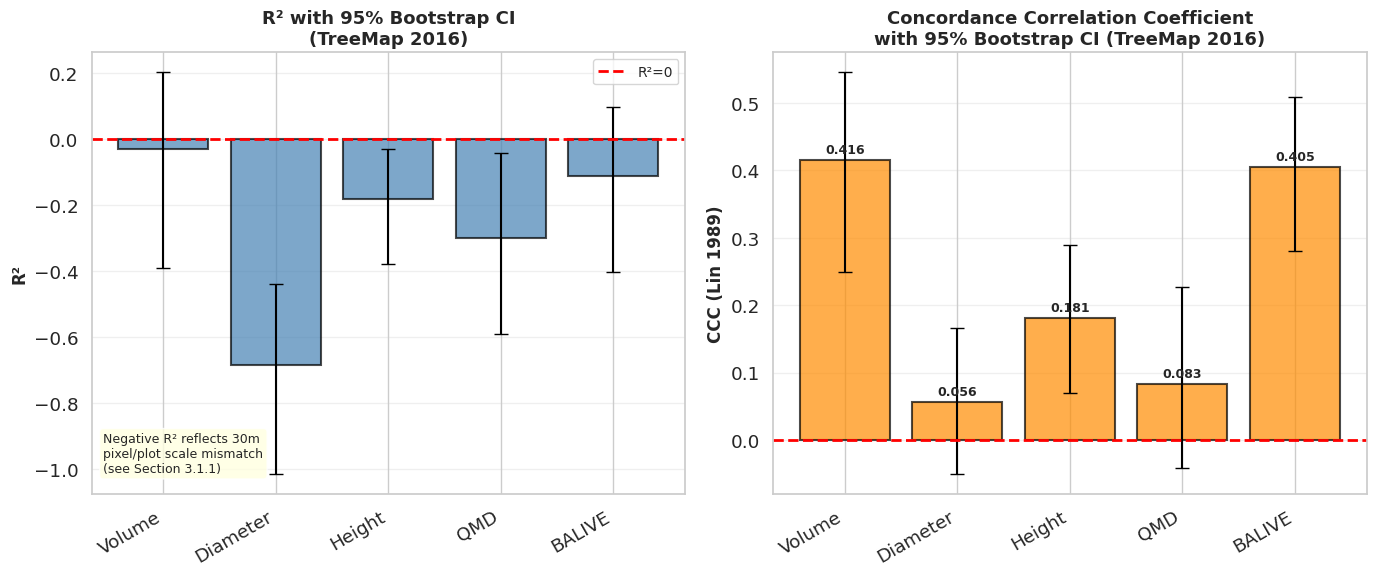

✅ Saved: Fig_Enhanced_R2_vs_CCC_2016.png


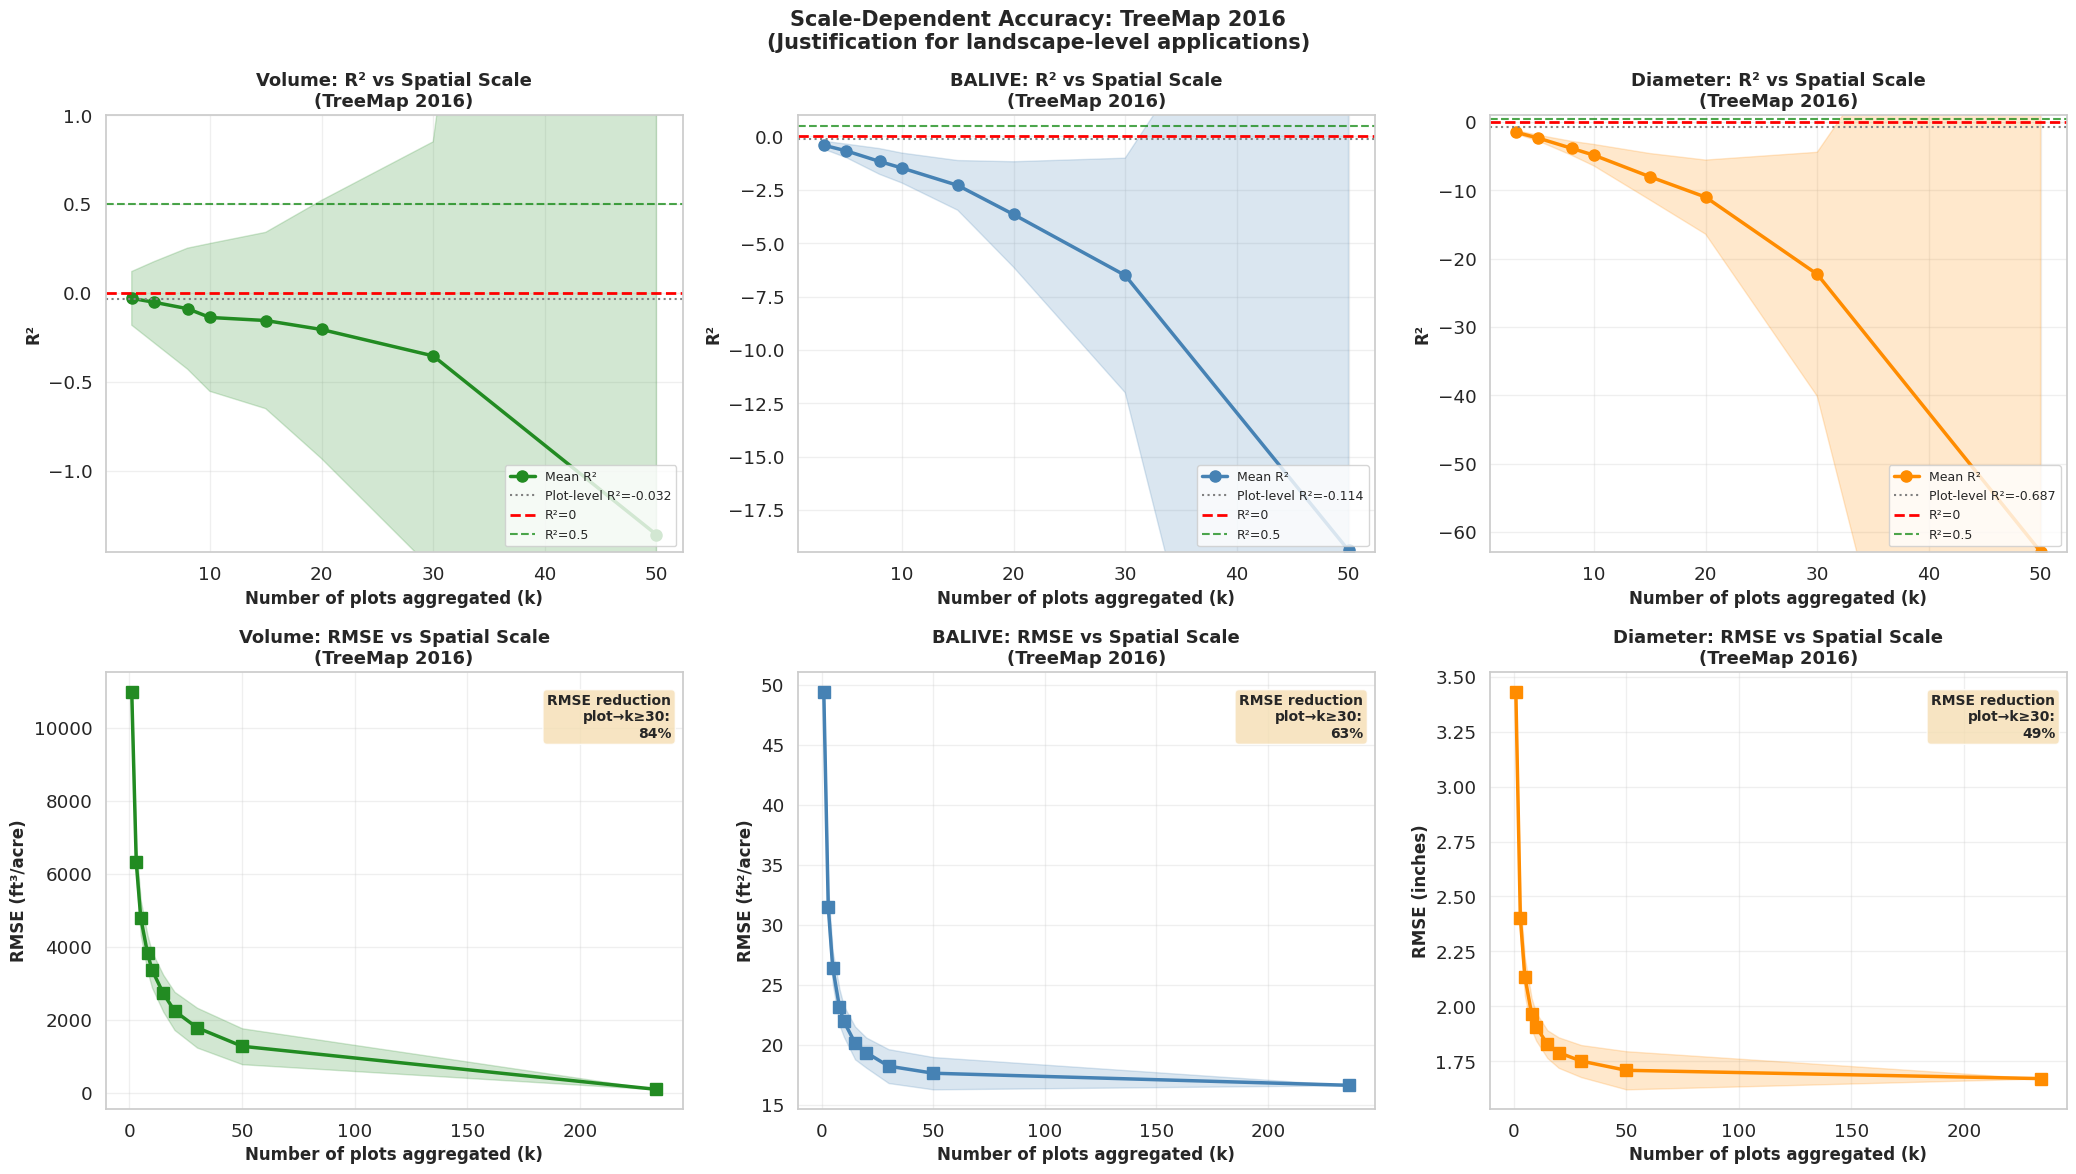

✅ Saved: Fig_Landscape_Aggregation_2016.png


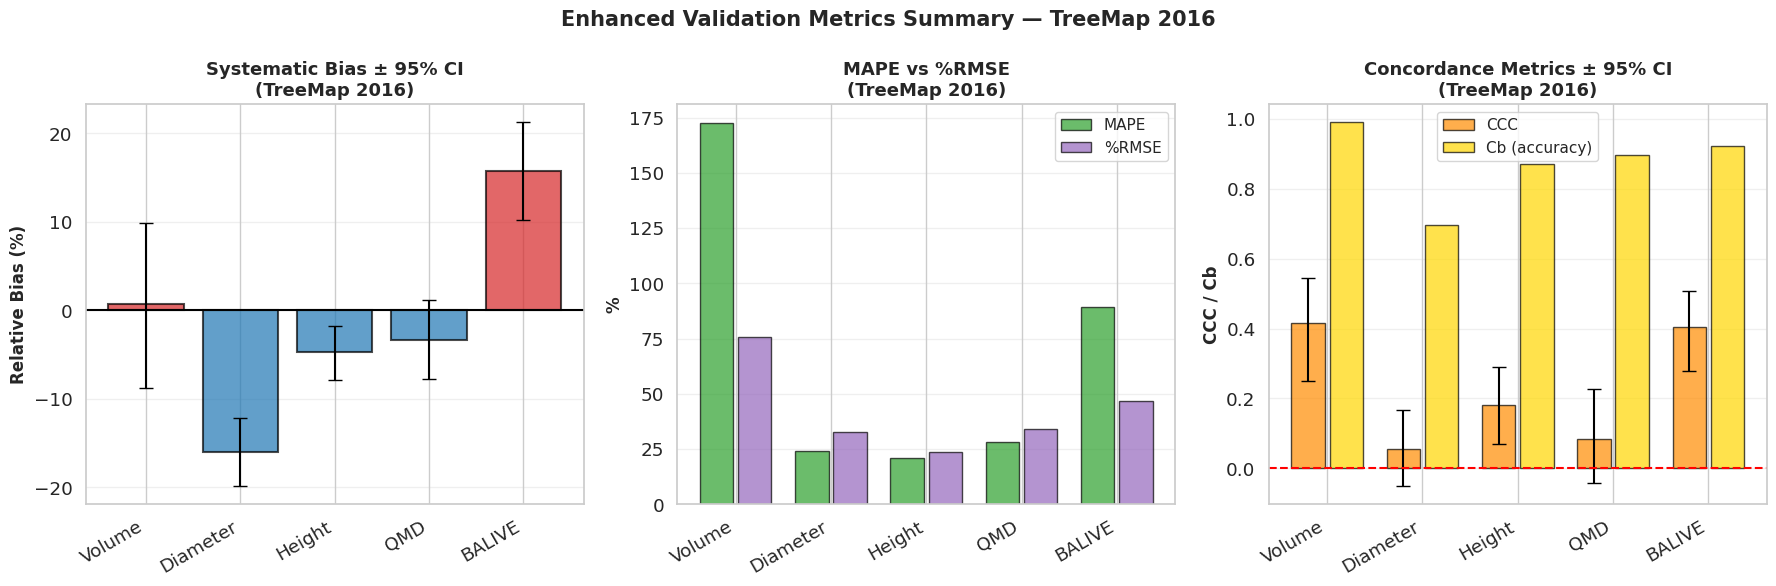

✅ Saved: Fig_Enhanced_Metrics_Summary_2016.png
✅ Landscape aggregation results saved: /content/drive/MyDrive/Landscape_Aggregation_2016.csv
METRICS COMPARISON (R² vs CCC):
Attribute          R²      CCC    Bias%    MAPE%
--------------------------------------------------
Volume        -0.0320   0.4159      0.7    172.5
Diameter      -0.6869   0.0558    -15.9     24.2
Height        -0.1825   0.1809     -4.7     21.1
QMD           -0.2995   0.0828     -3.3     28.3
BALIVE        -0.1141   0.4052     15.8     89.5

📁 Output files:
   Enhanced_Metrics_2016.csv          — full metrics table with 95% CI
   Statistical_Tests_2016.csv         — t-test and Wilcoxon results
   Landscape_Aggregation_2016.csv     — R²/RMSE by spatial scale
   Fig_Enhanced_R2_vs_CCC_2016.png    — R² vs CCC comparison figure
   Fig_Landscape_Aggregation_2016.png — scale-dependent accuracy figure
   Fig_Enhanced_Metrics_Summary_2016.png — metrics panel figure

✅ SECTION 11 COMPLETE


In [14]:
# ============================================================
# Section 11: Enhanced Validation Metrics
# ============================================================
# NEW: Adds CCC, MAPE, and landscape-scale aggregation analysis
# to complement existing RMSE/R² metrics and address the
# structural negative R² issue from scale mismatch.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import ttest_rel, wilcoxon, shapiro
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid", font_scale=1.2)
base_dir = "/content/drive/MyDrive"

print("="*80)
print("SECTION 11: ENHANCED VALIDATION METRICS")
print("="*80)

# ============================================================
# 11.0 Load all comparison data
# ============================================================

def load_comparison_data(year, base_dir):
    data = {}
    files = {
        'volume':   f'Volume_comparison_{year}.csv',
        'diameter': f'diameter_height_comparison_{year}.csv',
        'qmd':      f'QMD_comparison_{year}.csv',
        'ba':       f'BA_BALIVE_comparison_{year}.csv',
        'area':     f'final_area_summary_{year}_FINAL.csv'
    }
    for key, fname in files.items():
        try:
            data[key] = pd.read_csv(f"{base_dir}/{fname}")
            print(f"   ✅ {key}: {len(data[key])} records")
        except FileNotFoundError:
            print(f"   ❌ {key}: NOT FOUND — run Sections 5-8 first")
    return data

print(f"\n📁 Loading {year} comparison data...")
data = load_comparison_data(year, base_dir)

# ============================================================
# 11.1 Concordance Correlation Coefficient (CCC)
# ============================================================
# CCC combines precision (Pearson r) and accuracy (mean agreement)
# into a single metric bounded [-1, 1]. Unlike R², CCC penalizes
# both random error and systematic bias, and is not structurally
# negative when predictions are systematically shifted.
#
# CCC = 2ρσ_x σ_y / (σ_x² + σ_y² + (μ_x - μ_y)²)
# Reference: Lin (1989) Biometrics 45:255-268

def concordance_correlation(y_true, y_pred):
    """
    Lin's concordance correlation coefficient.
    Returns CCC and its components.
    """
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true = np.array(y_true)[mask]
    y_pred = np.array(y_pred)[mask]

    n = len(y_true)
    mu_true = y_true.mean()
    mu_pred = y_pred.mean()
    var_true = y_true.var()
    var_pred = y_pred.var()
    covar = np.cov(y_true, y_pred)[0, 1]

    # Pearson correlation
    rho = covar / (np.sqrt(var_true) * np.sqrt(var_pred) + 1e-10)

    # CCC
    ccc = (2 * covar) / (var_true + var_pred + (mu_true - mu_pred)**2)

    # Cb = bias correction factor
    cb = ccc / (rho + 1e-10)

    return {
        'CCC': round(ccc, 4),
        'Pearson_r': round(rho, 4),
        'Cb': round(cb, 4),  # accuracy (1 = perfect)
        'n': n
    }

# ============================================================
# 11.2 MAPE
# ============================================================

def mape(y_true, y_pred):
    """Mean Absolute Percentage Error, excluding near-zero observations."""
    mask = (~np.isnan(y_true)) & (~np.isnan(y_pred)) & (np.abs(y_true) > 1e-6)
    y_true = np.array(y_true)[mask]
    y_pred = np.array(y_pred)[mask]
    return round(np.mean(np.abs((y_pred - y_true) / y_true)) * 100, 2)

# ============================================================
# 11.3 Bootstrap Confidence Intervals
# ============================================================

def bootstrap_metrics(y_true, y_pred, n_iter=1000, ci=0.95, seed=42):
    """
    Bootstrap confidence intervals for RMSE, MAE, R², Bias, CCC.
    Returns point estimates and [lower, upper] CI bounds.
    """
    np.random.seed(seed)
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true = np.array(y_true)[mask]
    y_pred = np.array(y_pred)[mask]
    n = len(y_true)

    boot = {'rmse': [], 'mae': [], 'r2': [], 'bias': [], 'ccc': []}

    for _ in range(n_iter):
        idx = np.random.choice(n, size=n, replace=True)
        yt, yp = y_true[idx], y_pred[idx]
        boot['rmse'].append(np.sqrt(mean_squared_error(yt, yp)))
        boot['mae'].append(mean_absolute_error(yt, yp))
        boot['r2'].append(r2_score(yt, yp))
        boot['bias'].append((yp - yt).mean())
        boot['ccc'].append(concordance_correlation(yt, yp)['CCC'])

    alpha = 1 - ci
    results = {}
    for metric, vals in boot.items():
        vals = np.array(vals)
        results[metric] = {
            'point': vals.mean(),
            'lower': np.percentile(vals, alpha/2 * 100),
            'upper': np.percentile(vals, (1 - alpha/2) * 100)
        }

    return results

# ============================================================
# 11.4 Full enhanced metrics table
# ============================================================

def compute_enhanced_metrics(y_true, y_pred, attribute_name, unit=''):
    """Compute all metrics for one attribute."""
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    yt = np.array(y_true)[mask]
    yp = np.array(y_pred)[mask]
    n = len(yt)

    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae = mean_absolute_error(yt, yp)
    r2 = r2_score(yt, yp)
    bias = (yp - yt).mean()
    rel_bias = bias / yt.mean() * 100
    pct_rmse = rmse / yt.mean() * 100
    ccc_res = concordance_correlation(yt, yp)
    mape_val = mape(yt, yp)

    # Bootstrap CIs
    ci = bootstrap_metrics(yt, yp, n_iter=1000)

    print(f"\n{'='*60}")
    print(f"  {attribute_name} ({unit})")
    print(f"{'='*60}")
    print(f"  n = {n}")
    print(f"  Field Mean:    {yt.mean():.2f}")
    print(f"  TreeMap Mean:  {yp.mean():.2f}")
    print(f"")
    print(f"  RMSE:   {rmse:8.2f}  95%CI [{ci['rmse']['lower']:.2f}, {ci['rmse']['upper']:.2f}]")
    print(f"  MAE:    {mae:8.2f}  95%CI [{ci['mae']['lower']:.2f}, {ci['mae']['upper']:.2f}]")
    print(f"  Bias:   {bias:8.2f}  95%CI [{ci['bias']['lower']:.2f}, {ci['bias']['upper']:.2f}]")
    print(f"  Bias%:  {rel_bias:8.2f}%")
    print(f"  %RMSE:  {pct_rmse:8.2f}%")
    print(f"  MAPE:   {mape_val:8.2f}%")
    print(f"  R²:     {r2:8.4f}  95%CI [{ci['r2']['lower']:.4f}, {ci['r2']['upper']:.4f}]")
    print(f"  CCC:    {ccc_res['CCC']:8.4f}  95%CI [{ci['ccc']['lower']:.4f}, {ci['ccc']['upper']:.4f}]")
    print(f"    ├─ Pearson r: {ccc_res['Pearson_r']:.4f}")
    print(f"    └─ Bias correction factor Cb: {ccc_res['Cb']:.4f}")

    return {
        'Attribute': attribute_name, 'Unit': unit, 'n': n,
        'Field_Mean': round(yt.mean(), 2), 'TreeMap_Mean': round(yp.mean(), 2),
        'RMSE': round(rmse, 2), 'RMSE_Lower': round(ci['rmse']['lower'], 2),
        'RMSE_Upper': round(ci['rmse']['upper'], 2),
        'MAE': round(mae, 2),
        'Bias': round(bias, 2), 'Bias_Lower': round(ci['bias']['lower'], 2),
        'Bias_Upper': round(ci['bias']['upper'], 2),
        'Bias_pct': round(rel_bias, 2),
        'pct_RMSE': round(pct_rmse, 2),
        'MAPE': round(mape_val, 2),
        'R2': round(r2, 4), 'R2_Lower': round(ci['r2']['lower'], 4),
        'R2_Upper': round(ci['r2']['upper'], 4),
        'CCC': round(ccc_res['CCC'], 4), 'CCC_Lower': round(ci['ccc']['lower'], 4),
        'CCC_Upper': round(ci['ccc']['upper'], 4),
        'Pearson_r': round(ccc_res['Pearson_r'], 4),
        'Cb': round(ccc_res['Cb'], 4)
    }

print(f"\n{'='*80}")
print(f"ENHANCED METRICS — TreeMap {year}")
print(f"{'='*80}")

all_metrics = []

if 'volume' in data:
    m = compute_enhanced_metrics(
        data['volume']['Field_VOL'],
        data['volume']['TreeMap_VOL'],
        'Volume', 'ft³/acre'
    )
    all_metrics.append(m)

if 'diameter' in data:
    m = compute_enhanced_metrics(
        data['diameter']['Tree diameter (inches)'],
        data['diameter']['weighted_DIA'],
        'Diameter', 'inches'
    )
    all_metrics.append(m)

    m = compute_enhanced_metrics(
        data['diameter']['Tree height (feet)'],
        data['diameter']['weighted_HT'],
        'Height', 'feet'
    )
    all_metrics.append(m)

if 'qmd' in data:
    m = compute_enhanced_metrics(
        data['qmd']['Field_QMD'],
        data['qmd']['TreeMap_QMD'],
        'QMD', 'inches'
    )
    all_metrics.append(m)

if 'ba' in data:
    m = compute_enhanced_metrics(
        data['ba']['Field_BALIVE'],
        data['ba']['TreeMap_BALIVE'],
        'BALIVE', 'ft²/acre'
    )
    all_metrics.append(m)

# Save enhanced metrics table
metrics_df = pd.DataFrame(all_metrics)
metrics_path = f"{base_dir}/Enhanced_Metrics_{year}.csv"
metrics_df.to_csv(metrics_path, index=False)
print(f"\n✅ Enhanced metrics saved: {metrics_path}")

# ============================================================
# 11.5 Statistical Tests
# ============================================================

print(f"\n{'='*80}")
print(f"STATISTICAL SIGNIFICANCE TESTS")
print(f"{'='*80}")

def run_stat_tests(y_true, y_pred, attribute_name):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    yt = np.array(y_true)[mask]
    yp = np.array(y_pred)[mask]

    t_stat, t_pval = ttest_rel(yp, yt)
    w_stat, w_pval = wilcoxon(yp, yt)
    if len(yt) <= 5000:
        sw_stat, sw_pval = shapiro(yp - yt)
    else:
        sw_stat, sw_pval = np.nan, np.nan

    print(f"\n  {attribute_name}")
    print(f"  Paired t-test:  t={t_stat:.3f}, p={t_pval:.4f}  "
          f"{'✅ SIGNIFICANT' if t_pval < 0.05 else '❌ not significant'}")
    print(f"  Wilcoxon:       W={w_stat:.0f},   p={w_pval:.4f}  "
          f"{'✅ SIGNIFICANT' if w_pval < 0.05 else '❌ not significant'}")
    if not np.isnan(sw_pval):
        print(f"  Shapiro-Wilk:   W={sw_stat:.4f}, p={sw_pval:.4f}  "
              f"{'Normal residuals' if sw_pval > 0.05 else 'Non-normal residuals'}")

    return {
        'attribute': attribute_name, 'year': year,
        't_stat': t_stat, 't_pval': t_pval,
        'w_stat': w_stat, 'w_pval': w_pval,
        'sw_stat': sw_stat, 'sw_pval': sw_pval
    }

stat_results = []

if 'volume' in data:
    stat_results.append(run_stat_tests(
        data['volume']['Field_VOL'], data['volume']['TreeMap_VOL'], 'Volume'))
if 'diameter' in data:
    stat_results.append(run_stat_tests(
        data['diameter']['Tree diameter (inches)'], data['diameter']['weighted_DIA'], 'Diameter'))
    stat_results.append(run_stat_tests(
        data['diameter']['Tree height (feet)'], data['diameter']['weighted_HT'], 'Height'))
if 'qmd' in data:
    stat_results.append(run_stat_tests(
        data['qmd']['Field_QMD'], data['qmd']['TreeMap_QMD'], 'QMD'))
if 'ba' in data:
    stat_results.append(run_stat_tests(
        data['ba']['Field_BALIVE'], data['ba']['TreeMap_BALIVE'], 'BALIVE'))

stat_df = pd.DataFrame(stat_results)
stat_df.to_csv(f"{base_dir}/Statistical_Tests_{year}.csv", index=False)
print(f"\n✅ Statistical tests saved")

# ============================================================
# 11.6 Landscape-Scale Aggregation Analysis
# ============================================================
# KEY ANALYSIS: Demonstrates that while plot-level R² is negative
# (structural consequence of scale mismatch), accuracy improves
# substantially as spatial scale increases — validating TreeMap
# for landscape-level applications.
#
# Method: Randomly group plots into clusters of size k,
# compute cluster-mean predictions vs observations,
# calculate R² at each scale. Repeat 200 times for stability.

print(f"\n{'='*80}")
print(f"LANDSCAPE-SCALE AGGREGATION ANALYSIS")
print(f"{'='*80}")
print("""
Rationale: TreeMap predictions are generated at 30m pixel resolution
via nearest-neighbor imputation — identical values assigned to all
field plots within the same polygon. This structurally constrains
plot-level R² to be negative regardless of landscape accuracy.

The following analysis shows how R² and RMSE change as spatial scale
increases, providing direct evidence for appropriate use cases.
""")

def landscape_aggregation_analysis(y_true, y_pred, attribute_name,
                                   group_sizes=None, n_repeats=200, seed=42):
    """
    Aggregate plots into random groups of increasing size,
    compute validation metrics at each scale.
    Returns DataFrame with scale vs metrics.
    """
    np.random.seed(seed)

    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    yt = np.array(y_true)[mask]
    yp = np.array(y_pred)[mask]
    n = len(yt)

    if group_sizes is None:
        # Scales: 1, 3, 5, 8, 10, 15, 20, 30, 50, all
        group_sizes = [1, 3, 5, 8, 10, 15, 20, 30, 50, n]
        group_sizes = [g for g in group_sizes if g <= n]

    results = []

    for k in group_sizes:
        rmse_list, r2_list, ccc_list, bias_list = [], [], [], []

        if k == n:
            # All plots aggregated = single landscape estimate
            rmse_list.append(abs((yp.mean() - yt.mean())))
            r2_list.append(np.nan)  # only 1 point
            ccc_list.append(np.nan)
            bias_list.append(yp.mean() - yt.mean())
        else:
            reps = n_repeats if k > 1 else 1

            for rep in range(reps):
                # Randomly assign plots to groups
                shuffled = np.random.permutation(n)
                n_groups = n // k
                if n_groups < 2:
                    continue

                group_yt, group_yp = [], []
                for g in range(n_groups):
                    idx = shuffled[g*k:(g+1)*k]
                    group_yt.append(yt[idx].mean())
                    group_yp.append(yp[idx].mean())

                group_yt = np.array(group_yt)
                group_yp = np.array(group_yp)

                rmse_list.append(np.sqrt(mean_squared_error(group_yt, group_yp)))
                if len(group_yt) >= 3:
                    r2_list.append(r2_score(group_yt, group_yp))
                    ccc_list.append(concordance_correlation(group_yt, group_yp)['CCC'])
                bias_list.append((group_yp - group_yt).mean())

        if rmse_list:
            results.append({
                'attribute': attribute_name,
                'group_size': k,
                'n_groups': n // k if k < n else 1,
                'RMSE_mean': np.nanmean(rmse_list),
                'RMSE_std':  np.nanstd(rmse_list),
                'R2_mean':   np.nanmean(r2_list) if r2_list else np.nan,
                'R2_std':    np.nanstd(r2_list) if r2_list else np.nan,
                'CCC_mean':  np.nanmean(ccc_list) if ccc_list else np.nan,
                'Bias_mean': np.nanmean(bias_list)
            })

    return pd.DataFrame(results)

# Run aggregation analysis for Volume (primary interest) and Diameter
agg_results_all = []

attribute_configs = []
if 'volume' in data:
    attribute_configs.append({
        'y_true': data['volume']['Field_VOL'],
        'y_pred': data['volume']['TreeMap_VOL'],
        'name': 'Volume', 'unit': 'ft³/acre', 'color': 'forestgreen'
    })
if 'ba' in data:
    attribute_configs.append({
        'y_true': data['ba']['Field_BALIVE'],
        'y_pred': data['ba']['TreeMap_BALIVE'],
        'name': 'BALIVE', 'unit': 'ft²/acre', 'color': 'steelblue'
    })
if 'diameter' in data:
    attribute_configs.append({
        'y_true': data['diameter']['Tree diameter (inches)'],
        'y_pred': data['diameter']['weighted_DIA'],
        'name': 'Diameter', 'unit': 'inches', 'color': 'darkorange'
    })

print("\nRunning aggregation analysis (200 bootstrap repeats per scale)...")
for cfg in attribute_configs:
    print(f"  Processing {cfg['name']}...")
    agg_df = landscape_aggregation_analysis(
        cfg['y_true'], cfg['y_pred'], cfg['name']
    )
    agg_results_all.append((cfg, agg_df))
    print(f"    Plot-level R²:  {agg_df[agg_df['group_size']==1]['R2_mean'].values[0]:.3f}")
    # Find scale where R² first becomes positive
    pos_r2 = agg_df[agg_df['R2_mean'] > 0]
    if len(pos_r2) > 0:
        k_pos = pos_r2['group_size'].iloc[0]
        print(f"    R² > 0 at k ≥ {k_pos} plots ({k_pos} × 0.04 ha = {k_pos*0.04:.2f} ha)")
    k10 = agg_df[agg_df['group_size'] == 10]
    if len(k10) > 0:
        print(f"    R² at k=10:     {k10['R2_mean'].values[0]:.3f}")
    k30 = agg_df[agg_df['group_size'] >= 30]
    if len(k30) > 0:
        print(f"    R² at k≥30:     {k30['R2_mean'].values[0]:.3f}")
    agg_results_all[-1] = (cfg, agg_df)

# ============================================================
# 11.7 Visualization
# ============================================================

print("\n📊 Creating enhanced metrics figures...")

# --- Figure A: CCC vs R² comparison ---
if all_metrics:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    attrs = [m['Attribute'] for m in all_metrics]
    r2_vals = [m['R2'] for m in all_metrics]
    ccc_vals = [m['CCC'] for m in all_metrics]
    r2_lower = [m['R2_Lower'] for m in all_metrics]
    r2_upper = [m['R2_Upper'] for m in all_metrics]
    ccc_lower = [m['CCC_Lower'] for m in all_metrics]
    ccc_upper = [m['CCC_Upper'] for m in all_metrics]

    x = np.arange(len(attrs))
    width = 0.35

    # R²
    ax = axes[0]
    bars = ax.bar(x, r2_vals, color='steelblue', alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.errorbar(x, r2_vals,
                yerr=[np.array(r2_vals) - np.array(r2_lower),
                      np.array(r2_upper) - np.array(r2_vals)],
                fmt='none', color='black', capsize=5, linewidth=1.5)
    ax.axhline(0, color='red', linestyle='--', linewidth=2, label='R²=0')
    ax.set_xticks(x); ax.set_xticklabels(attrs, rotation=30, ha='right')
    ax.set_ylabel('R²', fontweight='bold', fontsize=12)
    ax.set_title(f'R² with 95% Bootstrap CI\n(TreeMap {year})', fontweight='bold', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, axis='y')

    # Add note about negative R²
    ax.text(0.02, 0.05,
            'Negative R² reflects 30m\npixel/plot scale mismatch\n(see Section 3.1.1)',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    # CCC
    ax = axes[1]
    ax.bar(x, ccc_vals, color='darkorange', alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.errorbar(x, ccc_vals,
                yerr=[np.array(ccc_vals) - np.array(ccc_lower),
                      np.array(ccc_upper) - np.array(ccc_vals)],
                fmt='none', color='black', capsize=5, linewidth=1.5)
    ax.axhline(0, color='red', linestyle='--', linewidth=2)
    ax.set_xticks(x); ax.set_xticklabels(attrs, rotation=30, ha='right')
    ax.set_ylabel('CCC (Lin 1989)', fontweight='bold', fontsize=12)
    ax.set_title(f'Concordance Correlation Coefficient\nwith 95% Bootstrap CI (TreeMap {year})',
                 fontweight='bold', fontsize=13)
    ax.grid(alpha=0.3, axis='y')

    for i, v in enumerate(ccc_vals):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)

    plt.tight_layout()
    fig.savefig(f"{base_dir}/Fig_Enhanced_R2_vs_CCC_{year}.png", dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: Fig_Enhanced_R2_vs_CCC_{year}.png")


# --- Figure B: Landscape Aggregation Analysis ---
if agg_results_all:
    n_attrs = len(agg_results_all)
    fig, axes = plt.subplots(2, n_attrs, figsize=(7*n_attrs, 12))

    if n_attrs == 1:
        axes = axes.reshape(2, 1)

    for col, (cfg, agg_df) in enumerate(agg_results_all):
        color = cfg['color']
        name = cfg['name']
        unit = cfg['unit']

        # Top: R² vs scale
        ax = axes[0, col]
        valid = agg_df[agg_df['R2_mean'].notna() & (agg_df['group_size'] > 1)]

        ax.fill_between(
            valid['group_size'],
            valid['R2_mean'] - valid['R2_std'],
            valid['R2_mean'] + valid['R2_std'],
            alpha=0.2, color=color
        )
        ax.plot(valid['group_size'], valid['R2_mean'],
                'o-', color=color, linewidth=2.5, markersize=8, label='Mean R²')

        # Plot-level R²
        plot_r2 = agg_df[agg_df['group_size'] == 1]['R2_mean'].values
        if len(plot_r2) > 0:
            ax.axhline(plot_r2[0], color='gray', linestyle=':', linewidth=1.5,
                       label=f'Plot-level R²={plot_r2[0]:.3f}')

        ax.axhline(0, color='red', linestyle='--', linewidth=2, label='R²=0')
        ax.axhline(0.5, color='green', linestyle='--', linewidth=1.5, alpha=0.7,
                   label='R²=0.5')

        ax.set_xlabel('Number of plots aggregated (k)', fontweight='bold', fontsize=12)
        ax.set_ylabel('R²', fontweight='bold', fontsize=12)
        ax.set_title(f'{name}: R² vs Spatial Scale\n(TreeMap {year})',
                     fontweight='bold', fontsize=13)
        ax.legend(fontsize=9, loc='lower right')
        ax.grid(alpha=0.3)
        ax.set_ylim(min(valid['R2_mean'].min() - 0.1, -0.3), 1.0)

        # Annotation: threshold for R²>0
        pos = valid[valid['R2_mean'] > 0]
        if len(pos) > 0:
            k_thresh = pos['group_size'].iloc[0]
            ha_thresh = k_thresh * 0.04
            ax.annotate(
                f'R²>0\nat k={k_thresh}\n({ha_thresh:.1f} ha)',
                xy=(k_thresh, 0), xytext=(k_thresh + 2, 0.15),
                arrowprops=dict(arrowstyle='->', color='black'),
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
            )

        # Bottom: RMSE vs scale
        ax2 = axes[1, col]
        ax2.fill_between(
            agg_df['group_size'],
            agg_df['RMSE_mean'] - agg_df['RMSE_std'],
            agg_df['RMSE_mean'] + agg_df['RMSE_std'],
            alpha=0.2, color=color
        )
        ax2.plot(agg_df['group_size'], agg_df['RMSE_mean'],
                 's-', color=color, linewidth=2.5, markersize=8)

        ax2.set_xlabel('Number of plots aggregated (k)', fontweight='bold', fontsize=12)
        ax2.set_ylabel(f'RMSE ({unit})', fontweight='bold', fontsize=12)
        ax2.set_title(f'{name}: RMSE vs Spatial Scale\n(TreeMap {year})',
                      fontweight='bold', fontsize=13)
        ax2.grid(alpha=0.3)

        # RMSE % reduction annotation
        rmse_1 = agg_df[agg_df['group_size']==1]['RMSE_mean'].values
        rmse_30 = agg_df[agg_df['group_size'] >= 30]['RMSE_mean'].values
        if len(rmse_1) > 0 and len(rmse_30) > 0:
            reduction = (1 - rmse_30[0]/rmse_1[0]) * 100
            ax2.text(0.98, 0.95,
                     f'RMSE reduction\nplot→k≥30:\n{reduction:.0f}%',
                     transform=ax2.transAxes, ha='right', va='top',
                     fontsize=10, fontweight='bold',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.suptitle(f'Scale-Dependent Accuracy: TreeMap {year}\n'
                 f'(Justification for landscape-level applications)',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    fig.savefig(f"{base_dir}/Fig_Landscape_Aggregation_{year}.png", dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: Fig_Landscape_Aggregation_{year}.png")


# --- Figure C: Summary metrics panel (for paper Table replacement) ---
if all_metrics:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    attrs = [m['Attribute'] for m in all_metrics]
    x = np.arange(len(attrs))

    # Panel 1: Bias% with CI
    ax = axes[0]
    bias_pct = [m['Bias_pct'] for m in all_metrics]
    bias_lower = [m['Bias_pct'] - m['Bias_Lower']/m['Field_Mean']*100 if m['Field_Mean'] != 0 else 0
                  for m in all_metrics]
    bias_upper = [m['Bias_Upper']/m['Field_Mean']*100 - m['Bias_pct'] if m['Field_Mean'] != 0 else 0
                  for m in all_metrics]

    colors_bias = ['#d62728' if b > 0 else '#1f77b4' for b in bias_pct]
    ax.bar(x, bias_pct, color=colors_bias, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.errorbar(x, bias_pct, yerr=[
        np.array(bias_pct) - [m['Bias_Lower']/m['Field_Mean']*100 for m in all_metrics],
        [m['Bias_Upper']/m['Field_Mean']*100 for m in all_metrics] - np.array(bias_pct)
    ], fmt='none', color='black', capsize=5)
    ax.axhline(0, color='black', linewidth=1.5)
    ax.set_xticks(x); ax.set_xticklabels(attrs, rotation=30, ha='right')
    ax.set_ylabel('Relative Bias (%)', fontweight='bold', fontsize=12)
    ax.set_title(f'Systematic Bias ± 95% CI\n(TreeMap {year})', fontweight='bold', fontsize=13)
    ax.grid(alpha=0.3, axis='y')

    # Panel 2: MAPE
    ax = axes[1]
    mape_vals = [m['MAPE'] for m in all_metrics]
    pct_rmse_vals = [m['pct_RMSE'] for m in all_metrics]

    ax.bar(x - 0.2, mape_vals, 0.35, label='MAPE', color='#2ca02c', alpha=0.7, edgecolor='black')
    ax.bar(x + 0.2, pct_rmse_vals, 0.35, label='%RMSE', color='#9467bd', alpha=0.7, edgecolor='black')
    ax.set_xticks(x); ax.set_xticklabels(attrs, rotation=30, ha='right')
    ax.set_ylabel('%', fontweight='bold', fontsize=12)
    ax.set_title(f'MAPE vs %RMSE\n(TreeMap {year})', fontweight='bold', fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3, axis='y')

    # Panel 3: CCC with CI
    ax = axes[2]
    ccc_v = [m['CCC'] for m in all_metrics]
    ccc_l = [m['CCC_Lower'] for m in all_metrics]
    ccc_u = [m['CCC_Upper'] for m in all_metrics]
    cb_v = [m['Cb'] for m in all_metrics]

    ax.bar(x - 0.2, ccc_v, 0.35, label='CCC', color='darkorange', alpha=0.7, edgecolor='black')
    ax.errorbar(x - 0.2, ccc_v,
                yerr=[np.array(ccc_v)-np.array(ccc_l), np.array(ccc_u)-np.array(ccc_v)],
                fmt='none', color='black', capsize=5)
    ax.bar(x + 0.2, cb_v, 0.35, label='Cb (accuracy)', color='gold', alpha=0.7, edgecolor='black')
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_xticks(x); ax.set_xticklabels(attrs, rotation=30, ha='right')
    ax.set_ylabel('CCC / Cb', fontweight='bold', fontsize=12)
    ax.set_title(f'Concordance Metrics ± 95% CI\n(TreeMap {year})', fontweight='bold', fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3, axis='y')

    plt.suptitle(f'Enhanced Validation Metrics Summary — TreeMap {year}',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    fig.savefig(f"{base_dir}/Fig_Enhanced_Metrics_Summary_{year}.png", dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: Fig_Enhanced_Metrics_Summary_{year}.png")

# ============================================================
# 11.8 Save landscape aggregation results
# ============================================================

agg_all_df = pd.concat([df for _, df in agg_results_all], ignore_index=True)
agg_path = f"{base_dir}/Landscape_Aggregation_{year}.csv"
agg_all_df.to_csv(agg_path, index=False)
print(f"✅ Landscape aggregation results saved: {agg_path}")

# ============================================================
# 11.9 Print paper-ready summary
# ============================================================

print("METRICS COMPARISON (R² vs CCC):")
print(f"{'Attribute':<12} {'R²':>8} {'CCC':>8} {'Bias%':>8} {'MAPE%':>8}")
print("-" * 50)
for m in all_metrics:
    print(f"{m['Attribute']:<12} {m['R2']:>8.4f} {m['CCC']:>8.4f} "
          f"{m['Bias_pct']:>8.1f} {m['MAPE']:>8.1f}")

print(f"\n📁 Output files:")
print(f"   Enhanced_Metrics_{year}.csv          — full metrics table with 95% CI")
print(f"   Statistical_Tests_{year}.csv         — t-test and Wilcoxon results")
print(f"   Landscape_Aggregation_{year}.csv     — R²/RMSE by spatial scale")
print(f"   Fig_Enhanced_R2_vs_CCC_{year}.png    — R² vs CCC comparison figure")
print(f"   Fig_Landscape_Aggregation_{year}.png — scale-dependent accuracy figure")
print(f"   Fig_Enhanced_Metrics_Summary_{year}.png — metrics panel figure")

print(f"\n✅ SECTION 11 COMPLETE")
print(f"{'='*80}")